# Segment-Grass Experiment: Ghost Rate & Drop Rate Sweep

**Goal**: Systematically study how ghost hits (fake detector noise) and dropped hits (detector inefficiency) interact with the geometric-clipping "segment grass" effect identified in the occupancy distributions.

**Sweep grid**:
- `ghost_rate`: [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]
- `drop_rate`: [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]
- `angle`: [±0.2, ±0.1] rad (±0.2 shows grass, ±0.1 is the control)
- `n_tracks`: [20, 50, 100]

**Total**: 6 × 6 × 2 × 3 = **216 jobs** (10 events each, run via Condor)

**Pipeline**:
1. `submit.sh` → generates params + submits to Condor
2. Workers run `scripts/run_worker.py` per grid point
3. `scripts/aggregate.py` merges results
4. This notebook loads and visualises the aggregated data

In [1]:
# ── Imports & configuration ──────────────────────────────────────
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import PercentFormatter

%matplotlib inline
plt.rcParams["figure.dpi"] = 140
plt.rcParams.update({
    "font.size": 11, "axes.labelsize": 12, "axes.titlesize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 9,
    "axes.linewidth": 1.0, "lines.linewidth": 1.8, "font.family": "serif",
})

RESULTS_DIR = Path("results")
AGG_DIR = RESULTS_DIR / "aggregated"
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

def save_fig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")

print(f"Results dir: {RESULTS_DIR.resolve()}")
print(f"Figures dir: {FIG_DIR.resolve()}")

Results dir: /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Segment_Grass/results
Figures dir: /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Segment_Grass/figures


In [2]:
# ── Load aggregated data ─────────────────────────────────────────
with open(AGG_DIR / "sweep_flat.json") as f:
    rows = json.load(f)

df = pd.DataFrame(rows)

# Sweep axes (used throughout the notebook)
angles       = sorted(df["angle"].unique(), reverse=True)
track_counts = sorted(df["n_tracks"].unique())
ghost_rates  = sorted(df["ghost_rate"].unique())
drop_rates   = sorted(df["drop_rate"].unique())

# A small set of noise configurations highlighted in early sections.
noise_configs = [
    (0.0, 0.0),
    (max(ghost_rates), 0.0),
    (0.0, max(drop_rates)),
    (max(ghost_rates), max(drop_rates)),
]

print(f"Loaded {len(df)} grid points")
print(f"\nColumns: {list(df.columns)}")
print(f"\nSweep ranges:")
print(f"  angle:      {angles}")
print(f"  n_tracks:   {track_counts}")
print(f"  ghost_rate: {ghost_rates}")
print(f"  drop_rate:  {drop_rates}")
df.head()


Loaded 216 grid points

Columns: ['angle', 'n_tracks', 'ghost_rate', 'drop_rate', 'occ_mean', 'occ_std', 'n_anomalous_occ', 'frac_anomalous_occ', 'mean_n_clipped', 'mean_n_ghost_hits', 'mean_n_dropped', 'mean_n_segments', 'efficiency', 'efficiency_std', 'reco_ghost_rate', 'reco_ghost_rate_std', 'clone_fraction', 'mean_true_activation', 'mean_false_activation', 'hits_mod0_mean', 'hits_mod1_mean', 'hits_mod2_mean', 'hits_mod3_mean', 'hits_mod4_mean', 'occ_sel_mean', 'occ_sel_std', 'n_anomalous_occ_sel', 'frac_anomalous_occ_sel', 'mean_n_segments_sel', 'mean_n_true_sel', 'mean_n_false_sel', 'mean_true_activation_sel', 'mean_false_activation_sel', 'hits_sel_mod0_mean', 'hits_sel_mod1_mean', 'hits_sel_mod2_mean', 'hits_sel_mod3_mean', 'hits_sel_mod4_mean']

Sweep ranges:
  angle:      [np.float64(0.2), np.float64(0.1)]
  n_tracks:   [np.int64(20), np.int64(50), np.int64(100)]
  ghost_rate: [np.float64(0.0), np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.3

,angle,n_tracks,ghost_rate,drop_rate,occ_mean,occ_std,n_anomalous_occ,frac_anomalous_occ,mean_n_clipped,mean_n_ghost_hits,...,mean_n_segments_sel,mean_n_true_sel,mean_n_false_sel,mean_true_activation_sel,mean_false_activation_sel,hits_sel_mod0_mean,hits_sel_mod1_mean,hits_sel_mod2_mean,hits_sel_mod3_mean,hits_sel_mod4_mean
0,0.2,20,0.0,0.00,31.811741,9.699377,108,0.109312,0.9,0.0,...,78.6,78.2,0.4,1.095860,1.428571,19.7,19.7,19.7,19.7,19.1
1,0.2,20,0.0,0.05,29.371938,9.307765,807,0.898664,3.5,0.0,...,59.3,59.3,0.0,1.068924,0.000000,14.7,15.4,15.4,15.4,13.8
2,0.2,20,0.0,0.10,28.260571,8.764643,824,0.941714,2.1,0.0,...,50.4,50.4,0.0,1.059418,0.000000,12.2,13.3,13.3,13.3,11.6
3,0.2,20,0.0,0.15,27.552415,8.523640,833,0.981154,0.3,0.0,...,46.4,46.4,0.0,1.046930,0.000000,11.1,12.5,12.5,12.5,10.3
4,0.2,20,0.0,0.20,25.691729,7.761334,798,1.000000,0.4,0.0,...,36.4,36.3,0.1,1.031114,1.206226,7.7,10.1,10.1,10.1,8.5


## Section 0 — Occupancy Histograms (Reproducing the Original Observation)

These histograms reproduce the occupancy distributions from the hit-competition study that first revealed the "segment grass" effect. Each histogram shows how many candidate segments use a given hit. For $n$ tracks, internal hits should appear at occupancy $2n$ and boundary hits at $n$. Any counts outside these expected peaks are **anomalous** — the segment grass.

We compare the **clean baseline** (ghost = 0%, drop = 0%) against selected noisy configurations to show how ghost and drop rates modify the distribution.

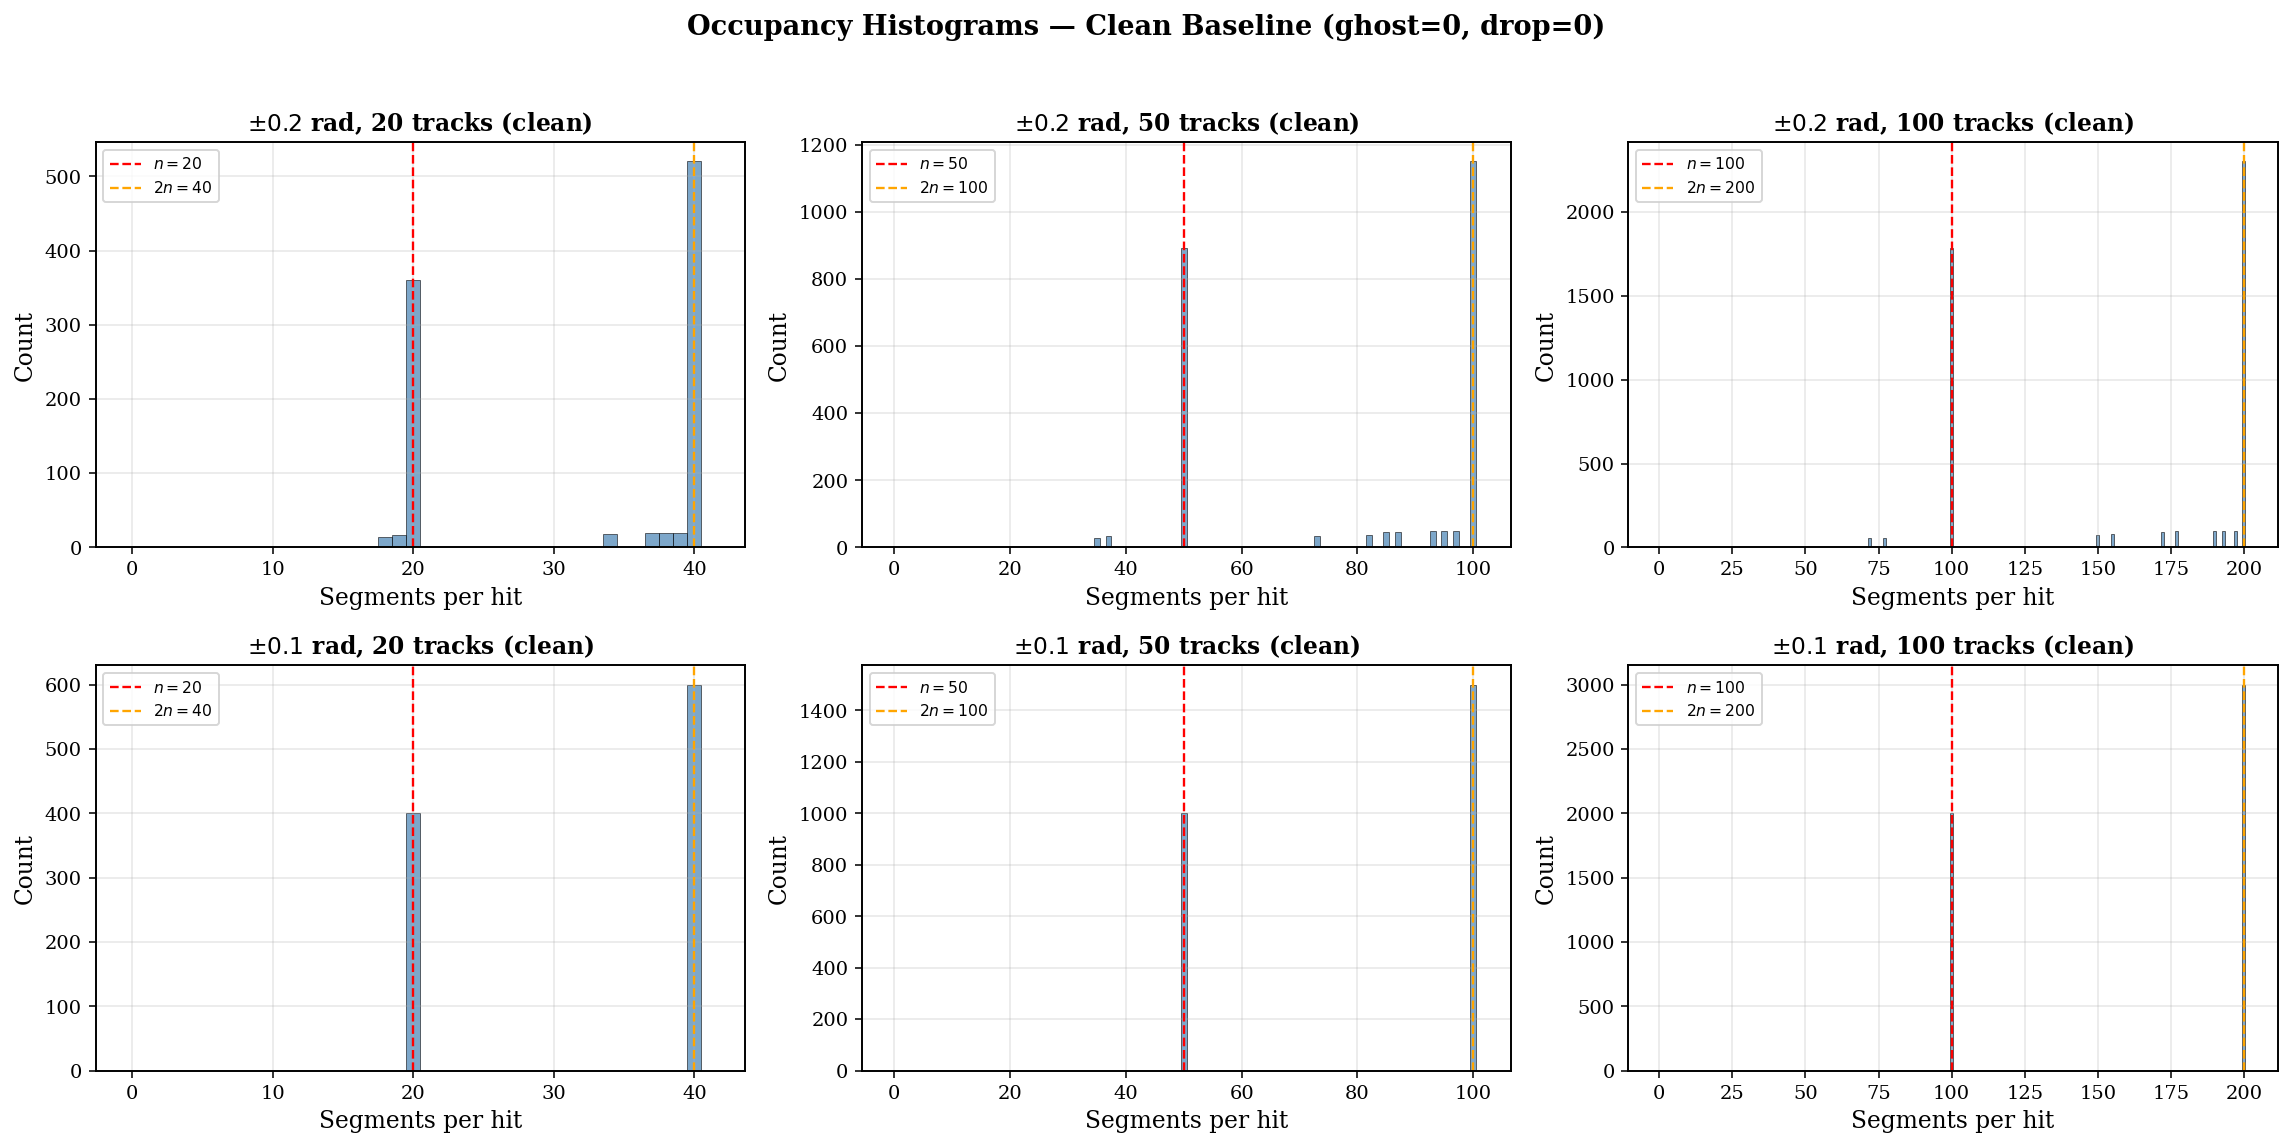

In [3]:
# ── Load raw occupancy arrays from per-job .npz files ────────────
import glob

def load_occ_for_params(angle, n_tracks, ghost_rate, drop_rate):
    """Load the raw occupancy array for a specific parameter combination."""
    params_dir = RESULTS_DIR / "params"
    for pf in sorted(params_dir.glob("job_*.json")):
        with open(pf) as f:
            p = json.load(f)
        if (p["angle"] == angle and p["n_tracks"] == n_tracks
                and p["ghost_rate"] == ghost_rate
                and p["drop_rate"] == drop_rate):
            job_name = pf.stem
            npz_path = RESULTS_DIR / job_name / "arrays.npz"
            if npz_path.exists():
                d = np.load(npz_path)
                return d["occ_all"]
    return None

# ── (a) Clean baseline histograms: rows=angles, cols=track counts ─
fig, axes = plt.subplots(len(angles), len(track_counts),
                         figsize=(5.5 * len(track_counts),
                                  4 * len(angles)),
                         squeeze=False)

for row, angle in enumerate(angles):
    for col, n_trk in enumerate(track_counts):
        ax = axes[row][col]
        occ = load_occ_for_params(angle, n_trk, 0.0, 0.0)
        if occ is not None:
            hi = int(np.max(occ)) + 2
            bins = np.arange(0, hi + 1) - 0.5
            ax.hist(occ, bins=bins, alpha=0.7,
                    color="steelblue", edgecolor="black", lw=0.4)
            # Mark expected peaks
            ax.axvline(n_trk, color="red", ls="--", lw=1.2,
                       label=f"$n={n_trk}$")
            ax.axvline(2 * n_trk, color="orange", ls="--", lw=1.2,
                       label=f"$2n={2*n_trk}$")
            ax.legend(fontsize=8)
        ax.set_xlabel("Segments per hit")
        ax.set_ylabel("Count")
        ax.set_title(f"$\\pm{angle}$ rad, {n_trk} tracks (clean)",
                     fontweight="bold")
        ax.grid(True, alpha=0.3)

plt.suptitle("Occupancy Histograms — Clean Baseline (ghost=0, drop=0)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "occ_hist_clean")
plt.show()

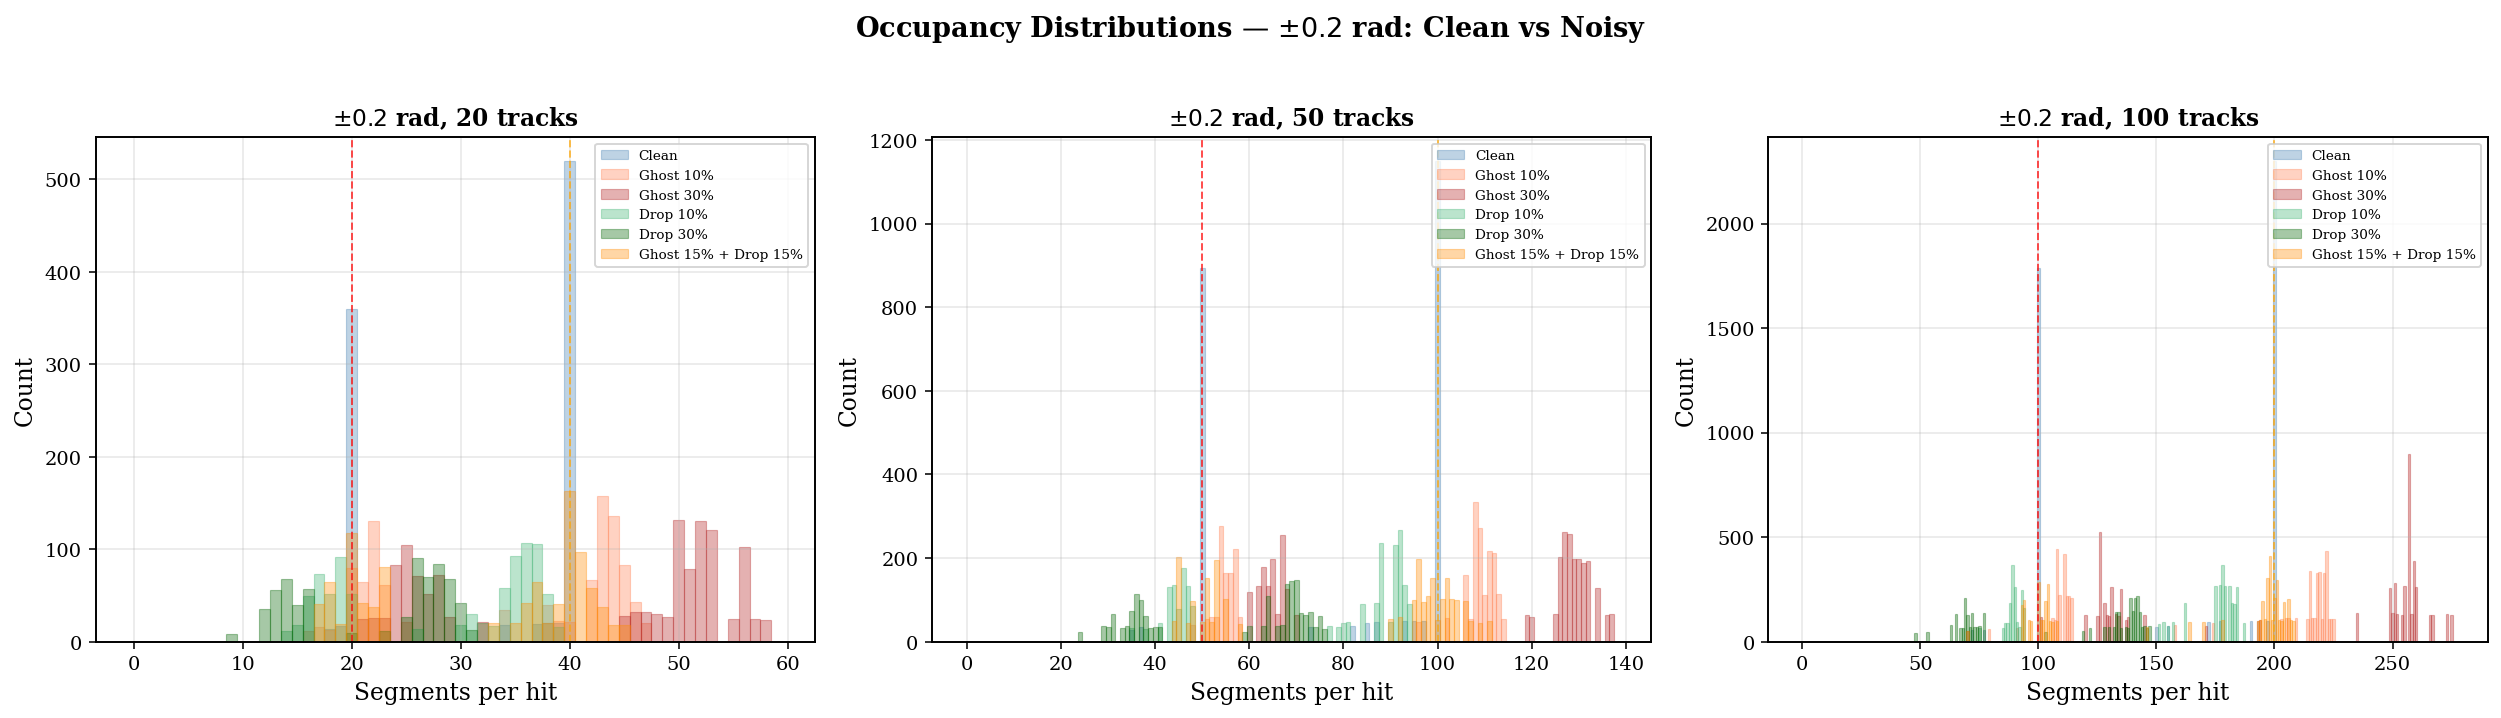

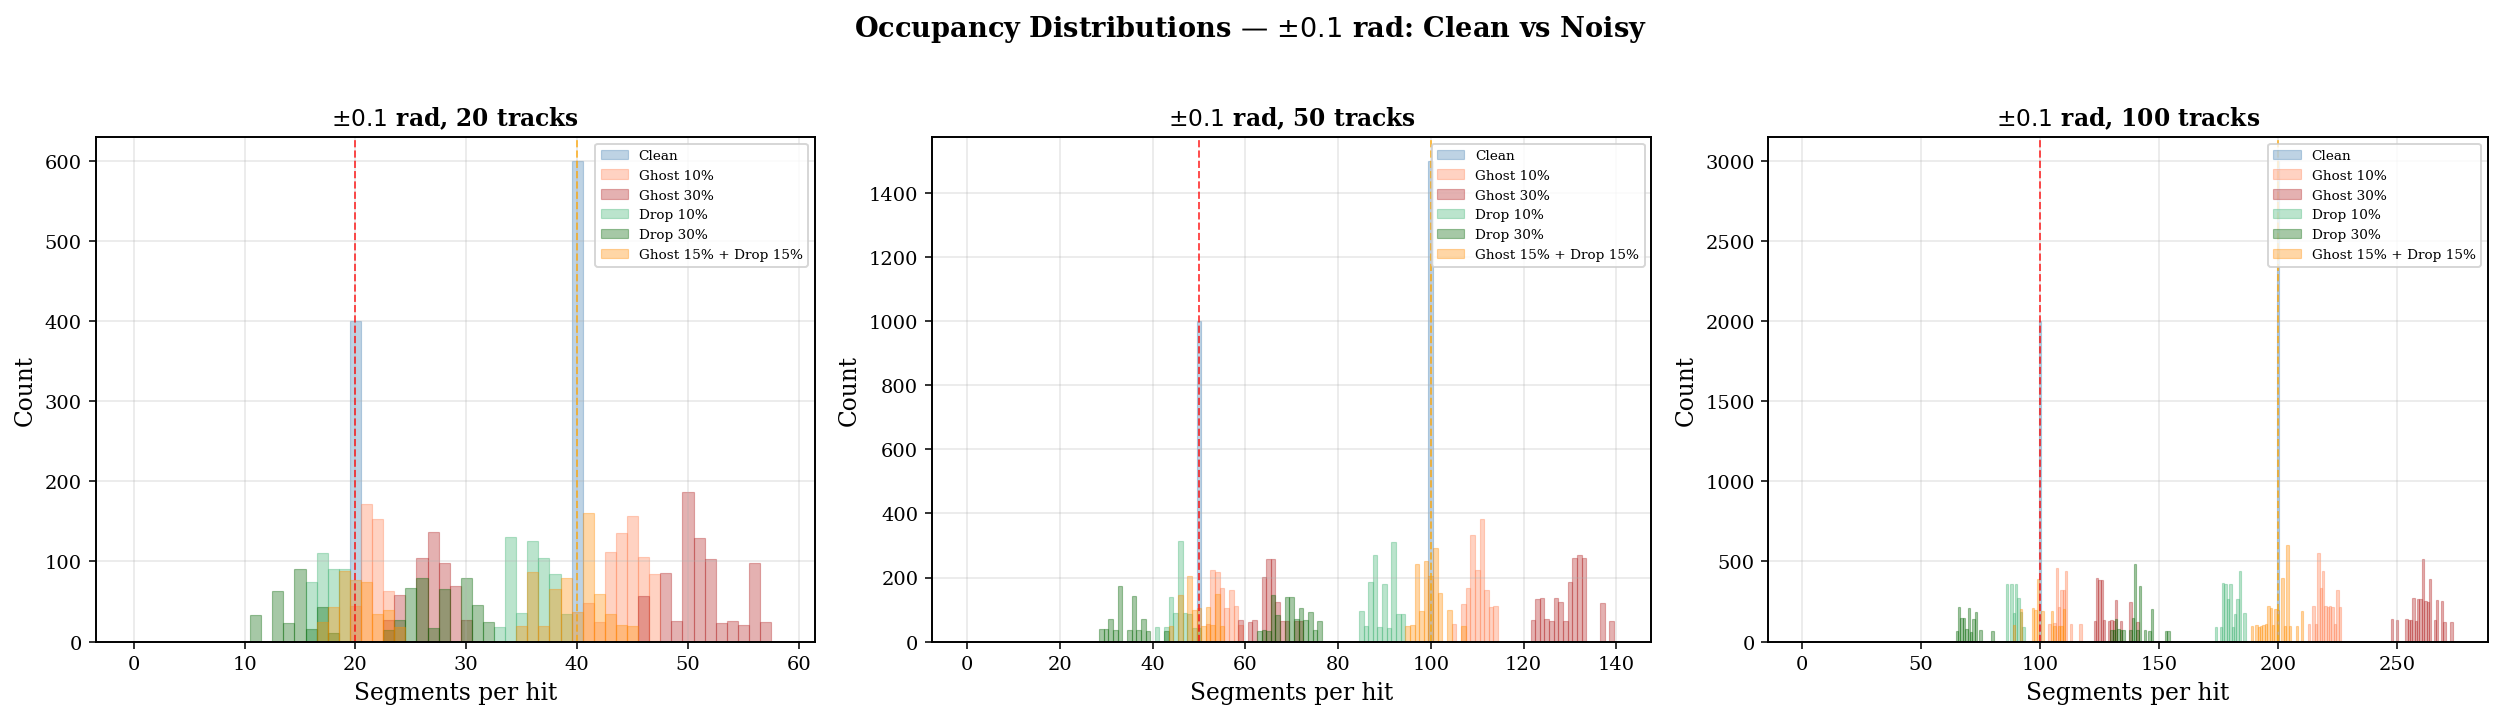

In [4]:
# ── (b) Comparing clean vs noisy: overlay histograms ─────────────
# Show how ghost and drop rates modify the occupancy distribution
# Pick representative noisy configs
noise_configs = [
    (0.0,  0.0,  "Clean",             "steelblue"),
    (0.10, 0.0,  "Ghost 10%",         "coral"),
    (0.30, 0.0,  "Ghost 30%",         "firebrick"),
    (0.0,  0.10, "Drop 10%",          "mediumseagreen"),
    (0.0,  0.30, "Drop 30%",          "darkgreen"),
    (0.15, 0.15, "Ghost 15% + Drop 15%", "darkorange"),
]

for angle in angles:
    fig, axes_row = plt.subplots(1, len(track_counts),
                                 figsize=(6 * len(track_counts), 5),
                                 squeeze=False)
    for col, n_trk in enumerate(track_counts):
        ax = axes_row[0][col]
        for gr, dr, label, color in noise_configs:
            occ = load_occ_for_params(angle, n_trk, gr, dr)
            if occ is None:
                continue
            hi = int(np.max(occ)) + 2
            bins = np.arange(0, hi + 1) - 0.5
            ax.hist(occ, bins=bins, alpha=0.35, color=color,
                    edgecolor=color, lw=0.6, label=label)

        # Mark expected peaks
        ax.axvline(n_trk, color="red", ls="--", lw=1.0, alpha=0.7)
        ax.axvline(2 * n_trk, color="orange", ls="--", lw=1.0, alpha=0.7)
        ax.set_xlabel("Segments per hit")
        ax.set_ylabel("Count")
        ax.set_title(f"$\\pm{angle}$ rad, {n_trk} tracks", fontweight="bold")
        ax.legend(fontsize=7, loc="upper right")
        ax.grid(True, alpha=0.3)

    plt.suptitle(f"Occupancy Distributions — $\\pm{angle}$ rad: Clean vs Noisy",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    save_fig(fig, f"occ_hist_comparison_angle{angle}")
    plt.show()

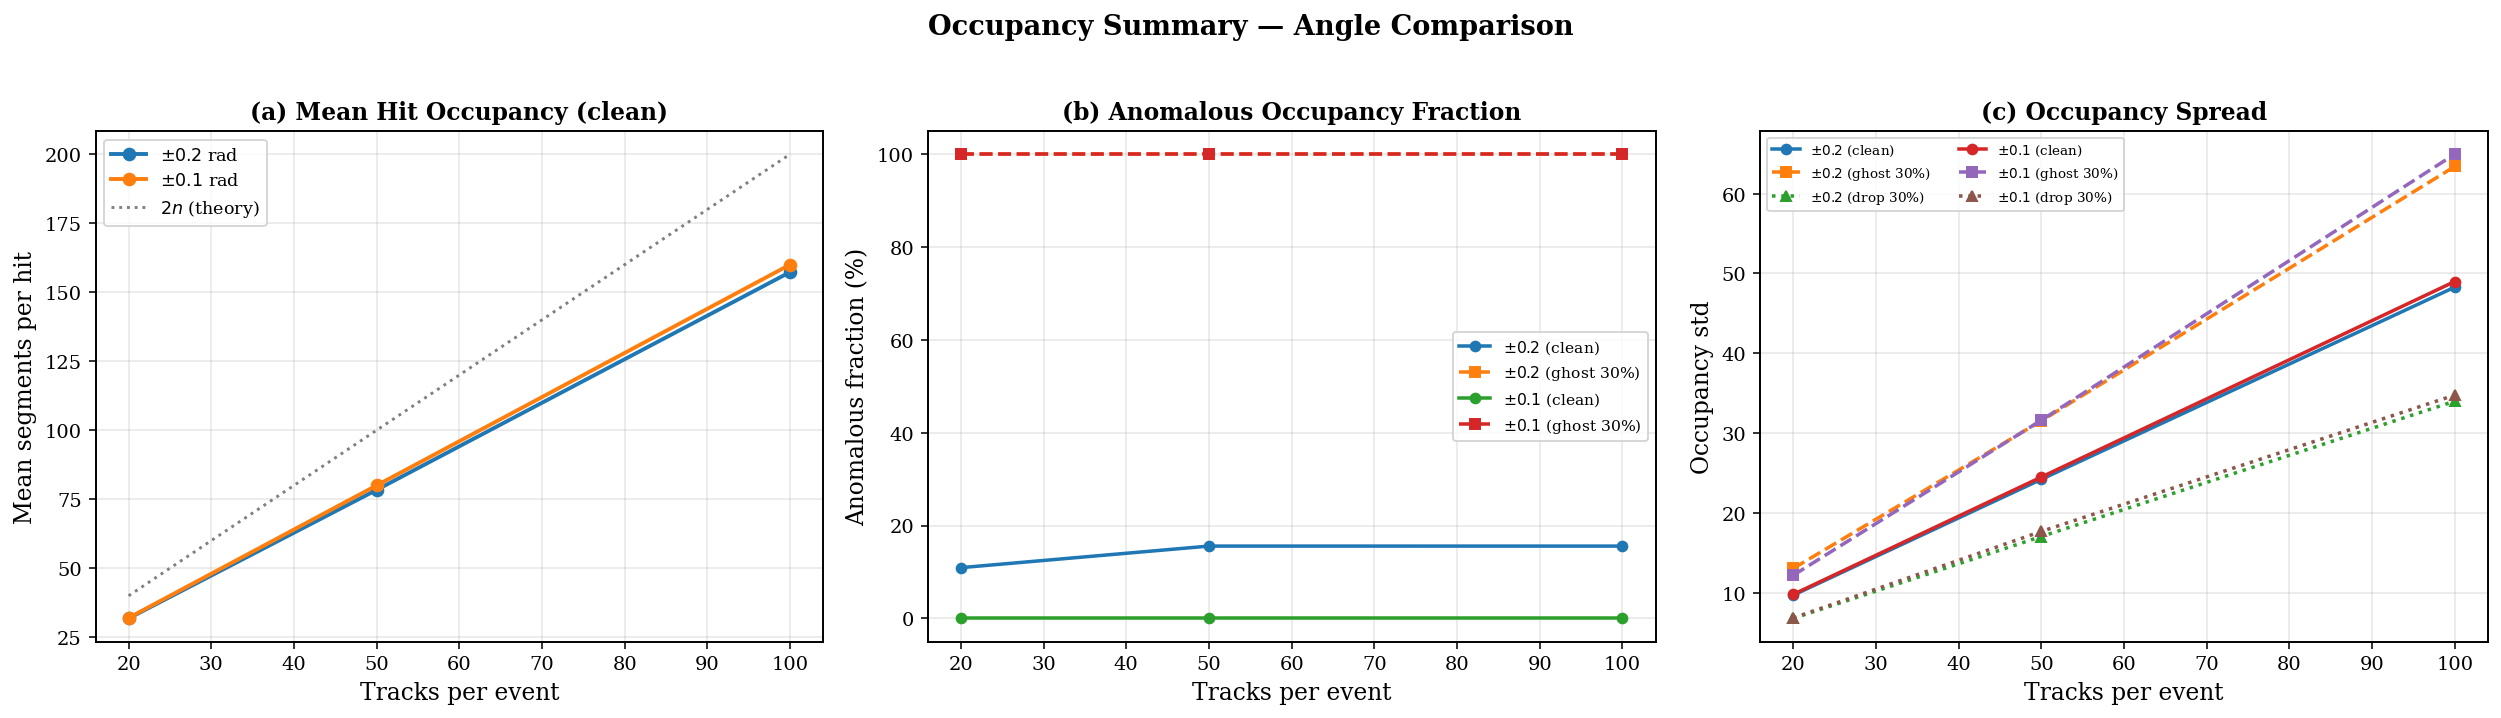

In [5]:
# ── (c) Summary statistics: mean occupancy & contested fraction ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Mean occupancy vs n_tracks for each angle (clean only)
for angle in angles:
    sub = df[(df["angle"] == angle) & (df["ghost_rate"] == 0.0) & (df["drop_rate"] == 0.0)]
    sub = sub.sort_values("n_tracks")
    axes[0].plot(sub["n_tracks"], sub["occ_mean"], "o-",
                 label=f"$\\pm{angle}$ rad", markersize=6, lw=2)
axes[0].plot(sorted(track_counts), [2 * n for n in sorted(track_counts)],
             ":", color="gray", lw=1.5, label="$2n$ (theory)")
axes[0].set_xlabel("Tracks per event")
axes[0].set_ylabel("Mean segments per hit")
axes[0].set_title("(a) Mean Hit Occupancy (clean)", fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Anomalous fraction vs n_tracks, comparing clean vs ghost=30%
for angle in angles:
    for gr, ls, label_sfx in [(0.0, "o-", "clean"), (0.30, "s--", "ghost 30%")]:
        sub = df[(df["angle"] == angle) & (df["ghost_rate"] == gr) & (df["drop_rate"] == 0.0)]
        sub = sub.sort_values("n_tracks")
        axes[1].plot(sub["n_tracks"], sub["frac_anomalous_occ"] * 100,
                     ls, label=f"$\\pm{angle}$ ({label_sfx})", markersize=5, lw=1.8)
axes[1].set_xlabel("Tracks per event")
axes[1].set_ylabel("Anomalous fraction (%)")
axes[1].set_title("(b) Anomalous Occupancy Fraction", fontweight="bold")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Occupancy std vs n_tracks, comparing clean vs noisy
for angle in angles:
    for gr, dr, ls, label_sfx in [(0.0, 0.0, "o-", "clean"),
                                   (0.30, 0.0, "s--", "ghost 30%"),
                                   (0.0, 0.30, "^:", "drop 30%")]:
        sub = df[(df["angle"] == angle) & (df["ghost_rate"] == gr) & (df["drop_rate"] == dr)]
        sub = sub.sort_values("n_tracks")
        axes[2].plot(sub["n_tracks"], sub["occ_std"],
                     ls, label=f"$\\pm{angle}$ ({label_sfx})", markersize=5, lw=1.8)
axes[2].set_xlabel("Tracks per event")
axes[2].set_ylabel("Occupancy std")
axes[2].set_title("(c) Occupancy Spread", fontweight="bold")
axes[2].legend(fontsize=7, ncol=2)
axes[2].grid(True, alpha=0.3)

plt.suptitle("Occupancy Summary — Angle Comparison",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "occ_summary_comparison")
plt.show()

---
## 1. Anomalous Occupancy Fraction — Heatmaps

The fraction of hit-occupancy values that fall outside the expected peaks ($n$ and $2n$) is the primary diagnostic for "segment grass". We plot this as heatmaps across the ghost-rate × drop-rate grid, comparing ±0.2 rad (where geometric clipping causes grass) and ±0.1 rad (control).

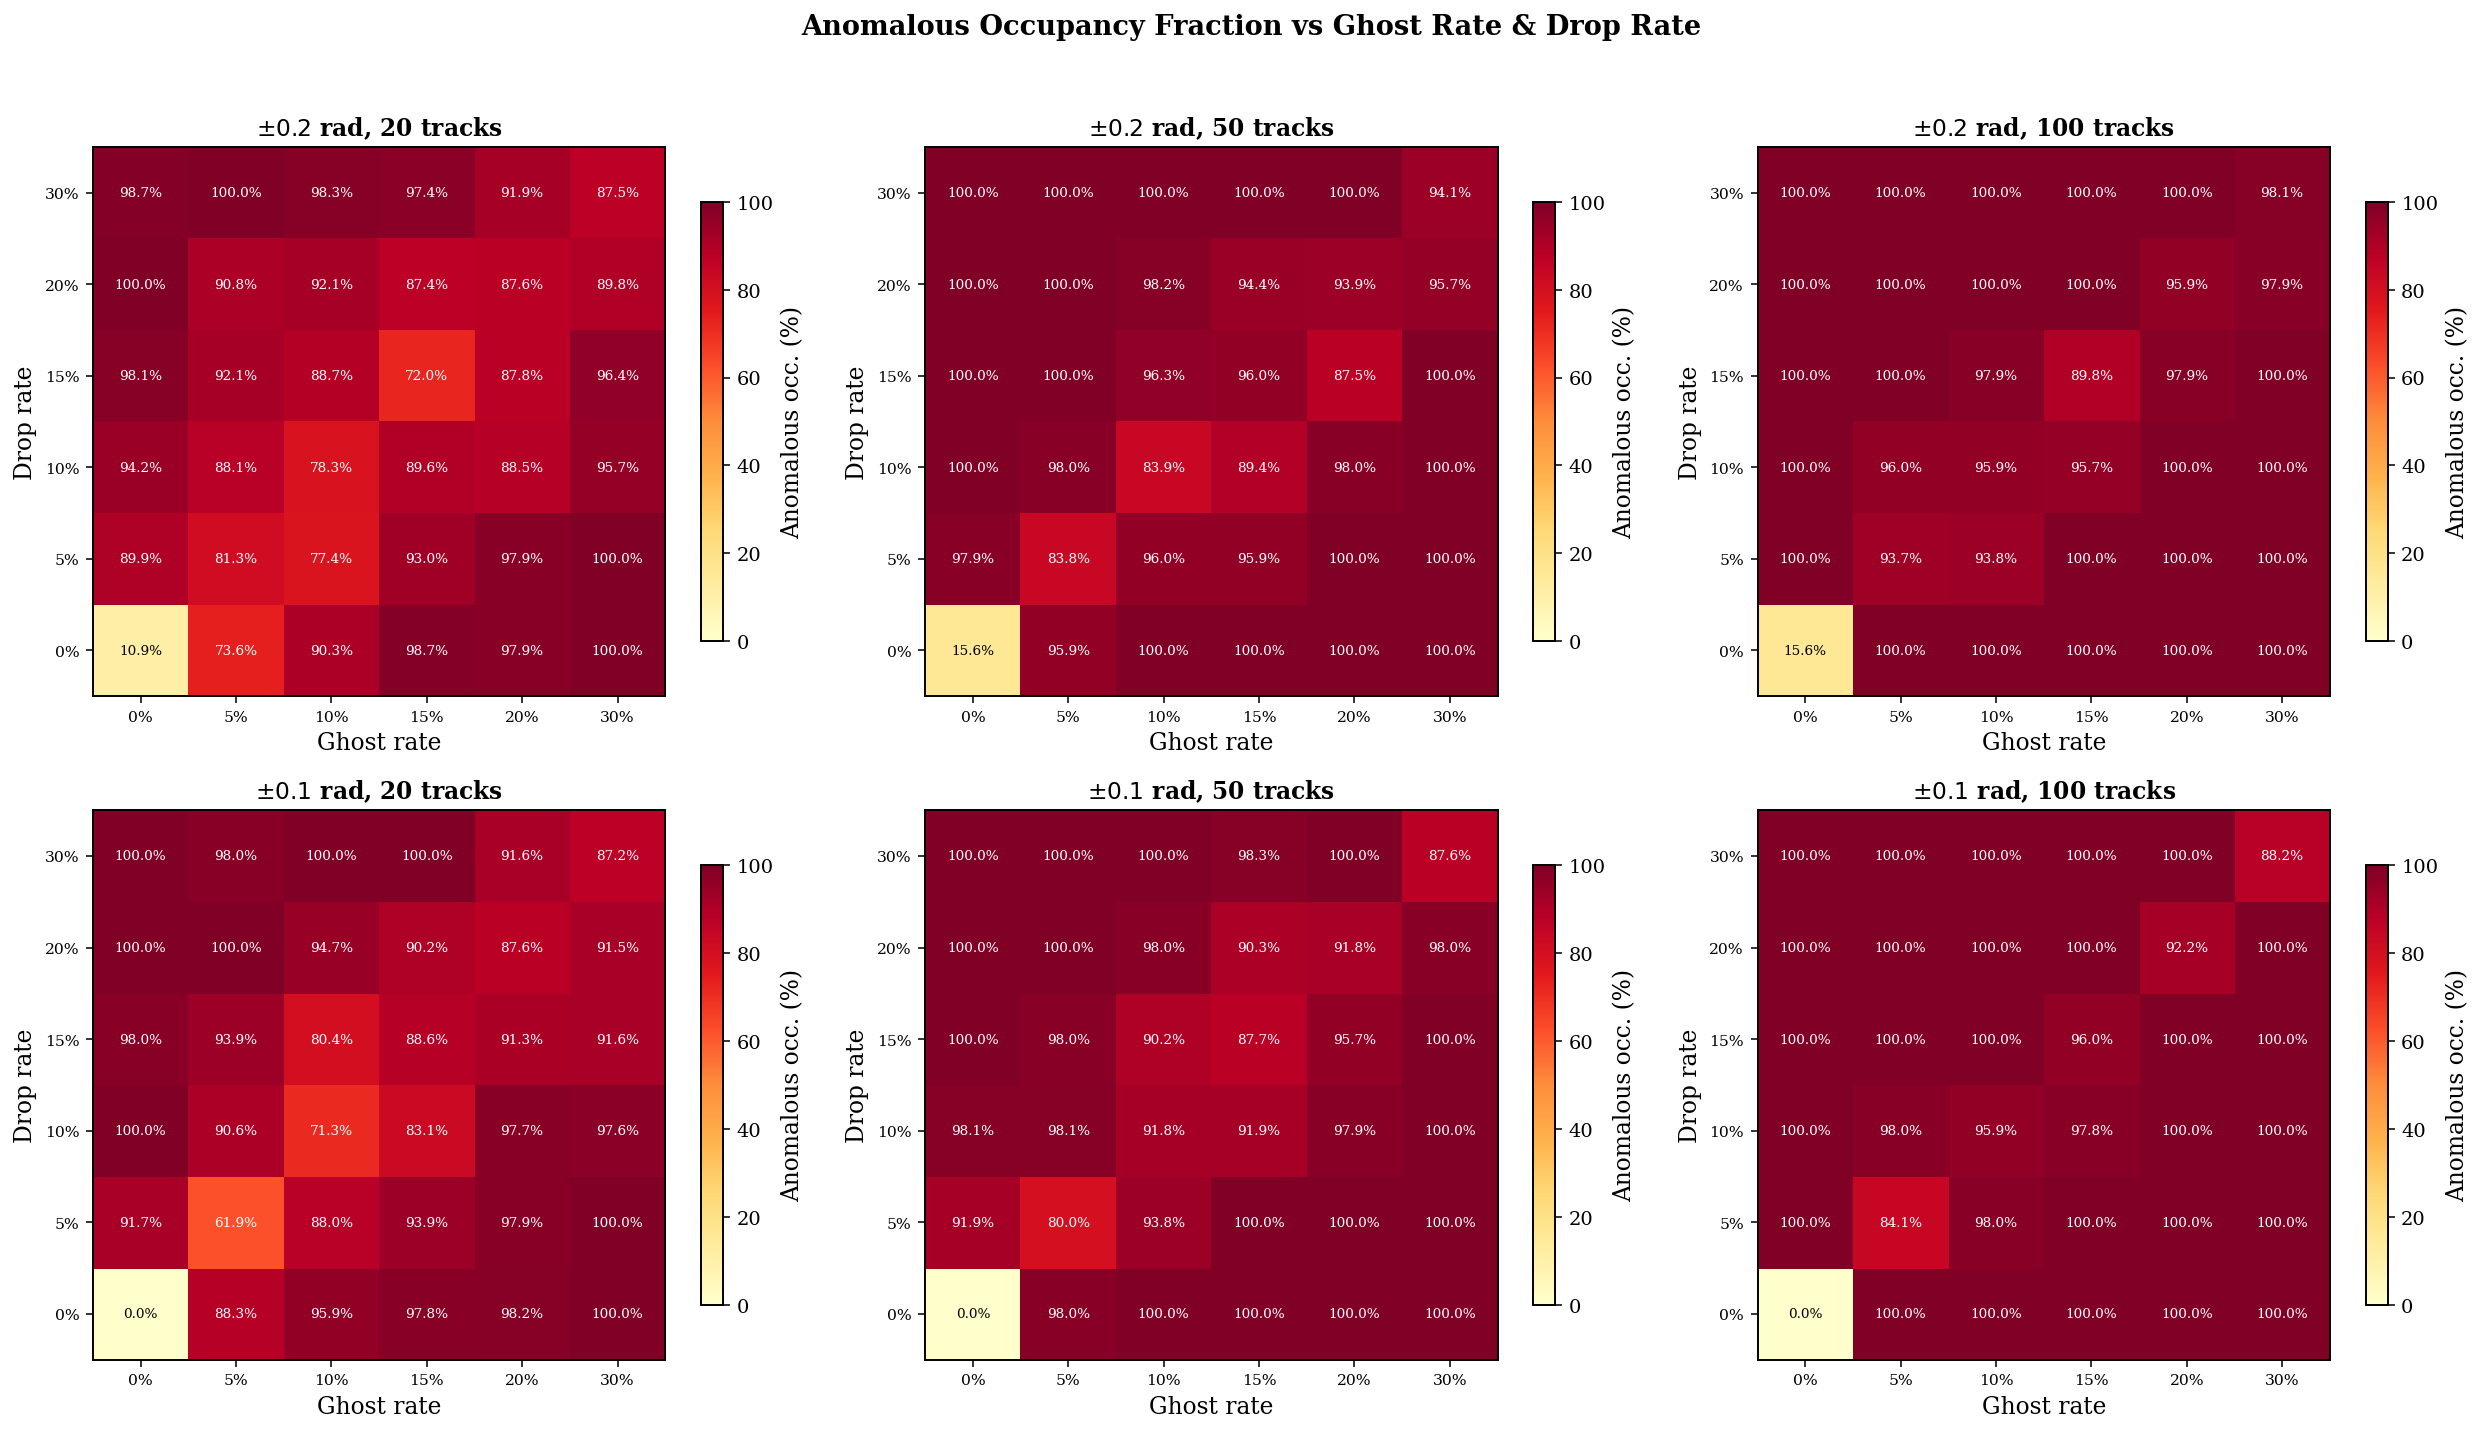

In [6]:
# ── Heatmaps: anomalous occupancy fraction ──────────────────────
angles = sorted(df["angle"].unique(), reverse=True)
track_counts = sorted(df["n_tracks"].unique())
ghost_rates = sorted(df["ghost_rate"].unique())
drop_rates = sorted(df["drop_rate"].unique())

fig, axes = plt.subplots(len(angles), len(track_counts),
                         figsize=(6 * len(track_counts),
                                  5 * len(angles)),
                         squeeze=False)

for row, angle in enumerate(angles):
    for col, n_trk in enumerate(track_counts):
        ax = axes[row][col]
        sub = df[(df["angle"] == angle) & (df["n_tracks"] == n_trk)]

        # Pivot to heatmap
        piv = sub.pivot_table(
            index="drop_rate", columns="ghost_rate",
            values="frac_anomalous_occ", aggfunc="first")
        piv = piv.reindex(index=drop_rates, columns=ghost_rates)

        im = ax.imshow(piv.values * 100, aspect="auto",
                       cmap="YlOrRd", origin="lower",
                       vmin=0, vmax=max(df["frac_anomalous_occ"].max() * 100, 1))

        ax.set_xticks(range(len(ghost_rates)))
        ax.set_xticklabels([f"{g:.0%}" for g in ghost_rates], fontsize=8)
        ax.set_yticks(range(len(drop_rates)))
        ax.set_yticklabels([f"{d:.0%}" for d in drop_rates], fontsize=8)
        ax.set_xlabel("Ghost rate")
        ax.set_ylabel("Drop rate")
        ax.set_title(f"$\\pm{angle}$ rad, {n_trk} tracks", fontweight="bold")

        # Annotate cells
        for i in range(len(drop_rates)):
            for j in range(len(ghost_rates)):
                val = piv.values[i, j] * 100
                if not np.isnan(val):
                    color = "white" if val > 30 else "black"
                    ax.text(j, i, f"{val:.1f}%", ha="center", va="center",
                            fontsize=7, color=color)

        plt.colorbar(im, ax=ax, label="Anomalous occ. (%)", shrink=0.8)

plt.suptitle("Anomalous Occupancy Fraction vs Ghost Rate & Drop Rate",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "heatmap_anomalous_occ")
plt.show()

## Section 2 — Occupancy Standard Deviation vs Ghost / Drop Rate

The standard deviation of the occupancy distribution measures how "spiky" the distribution is. Higher values indicate more anomalous peaks (segment grass). We plot this as a function of ghost rate and drop rate, separated by angle and track count.

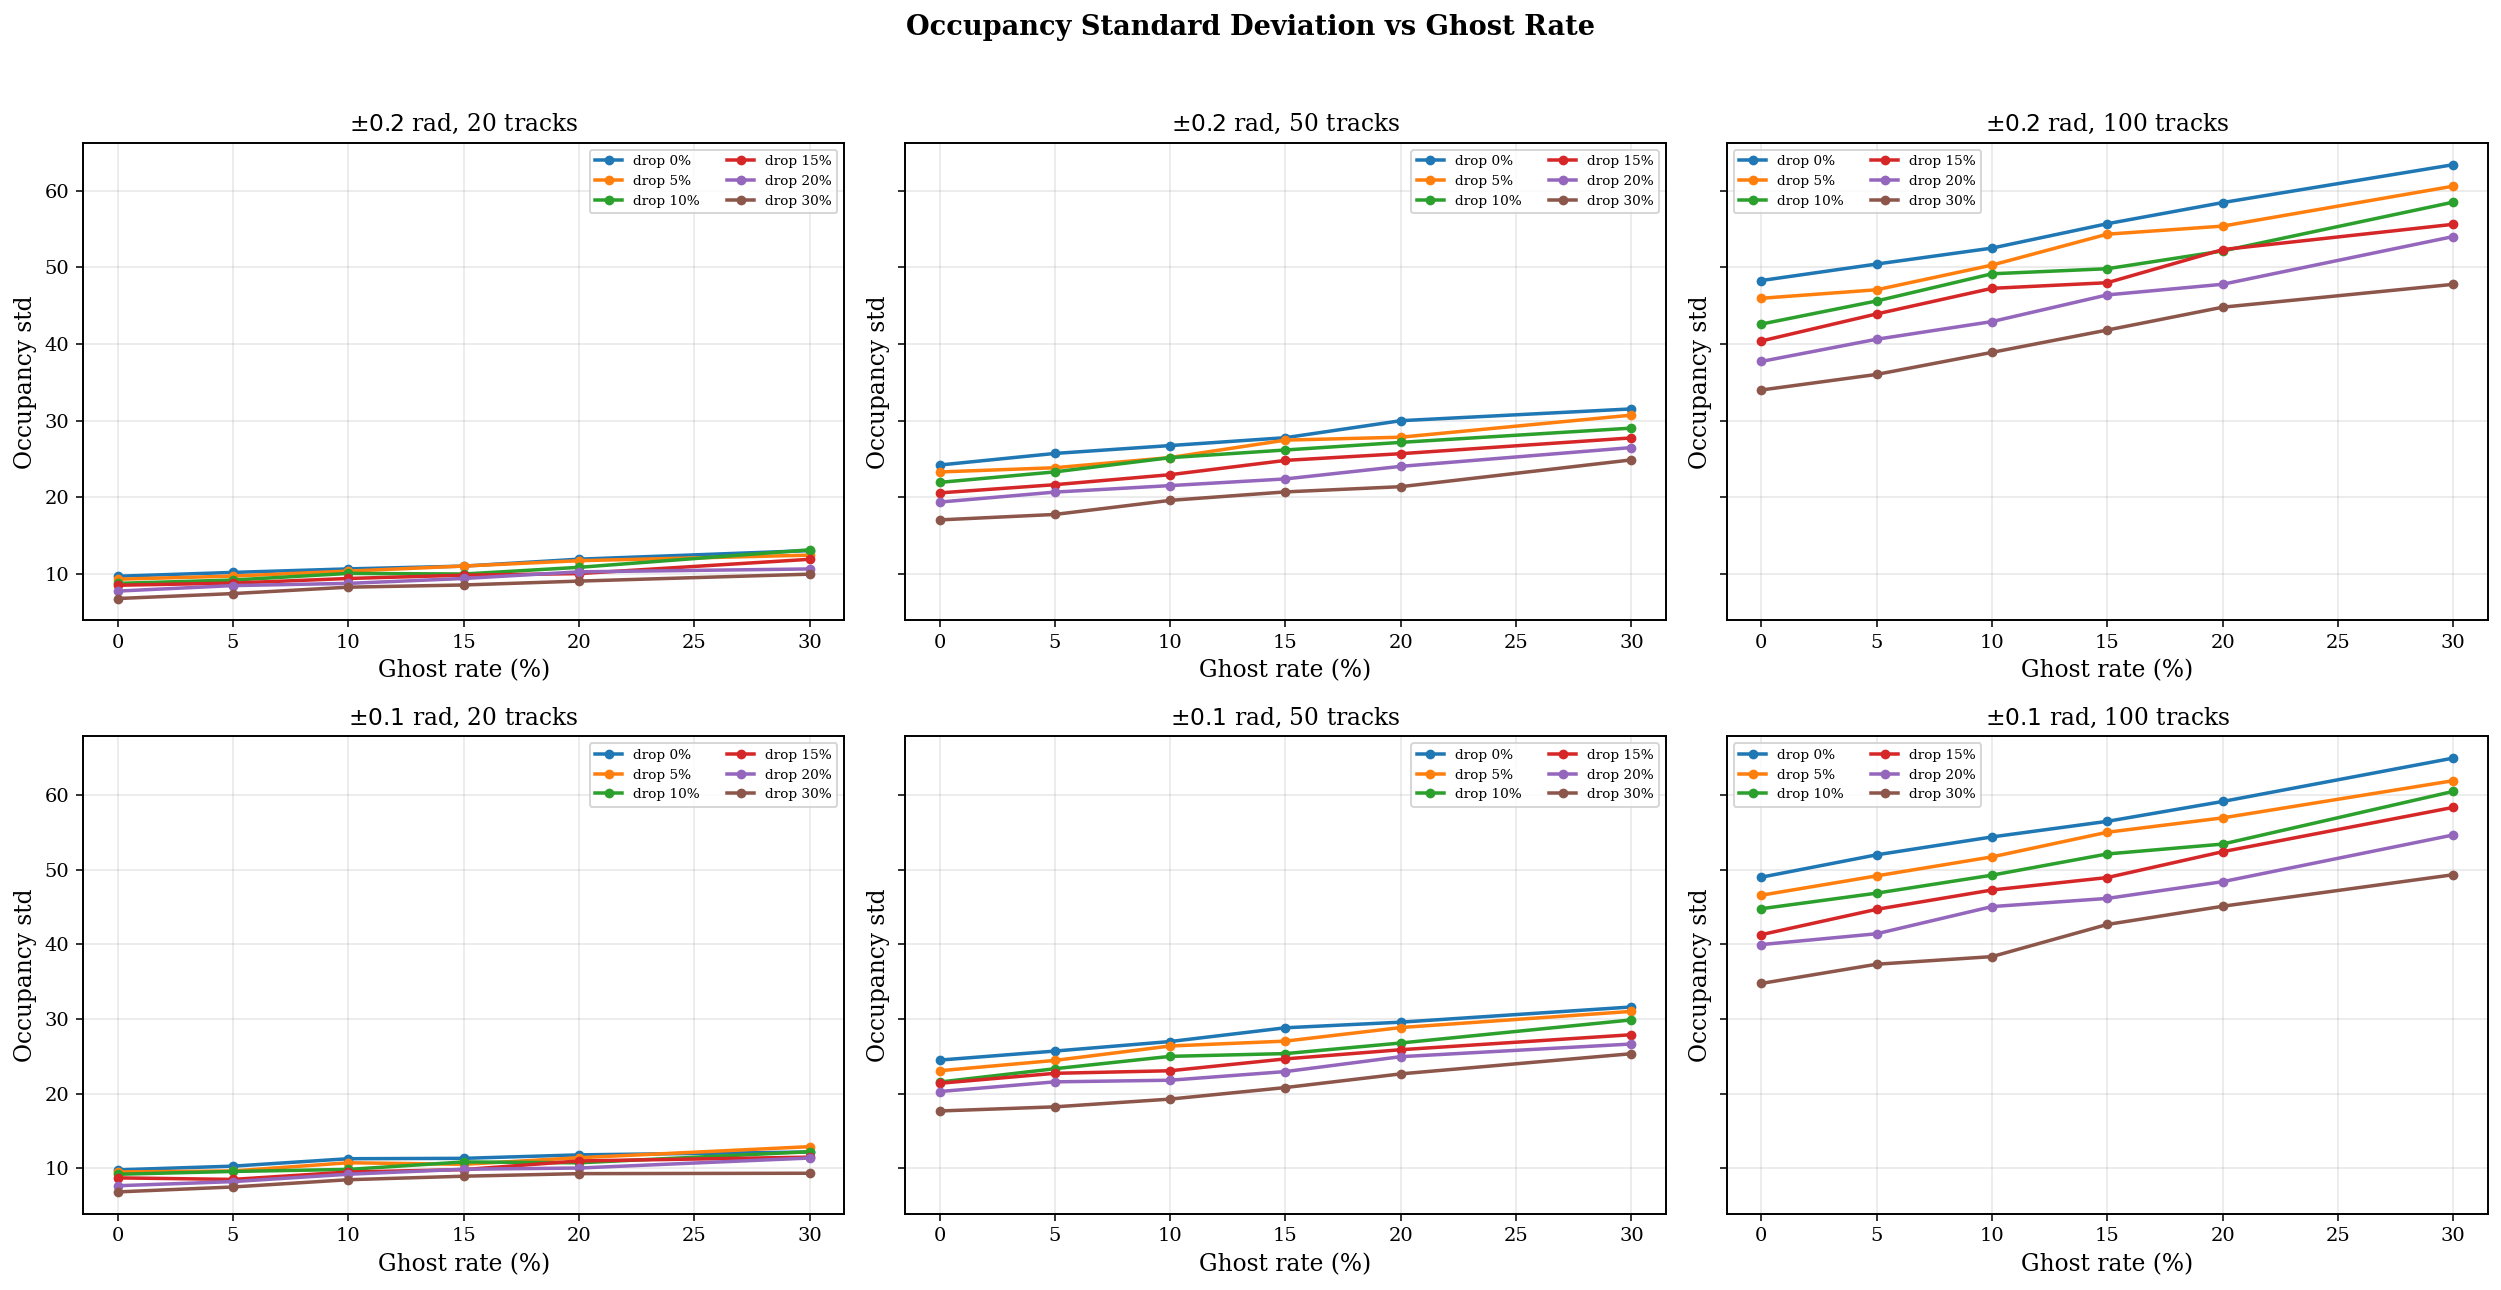

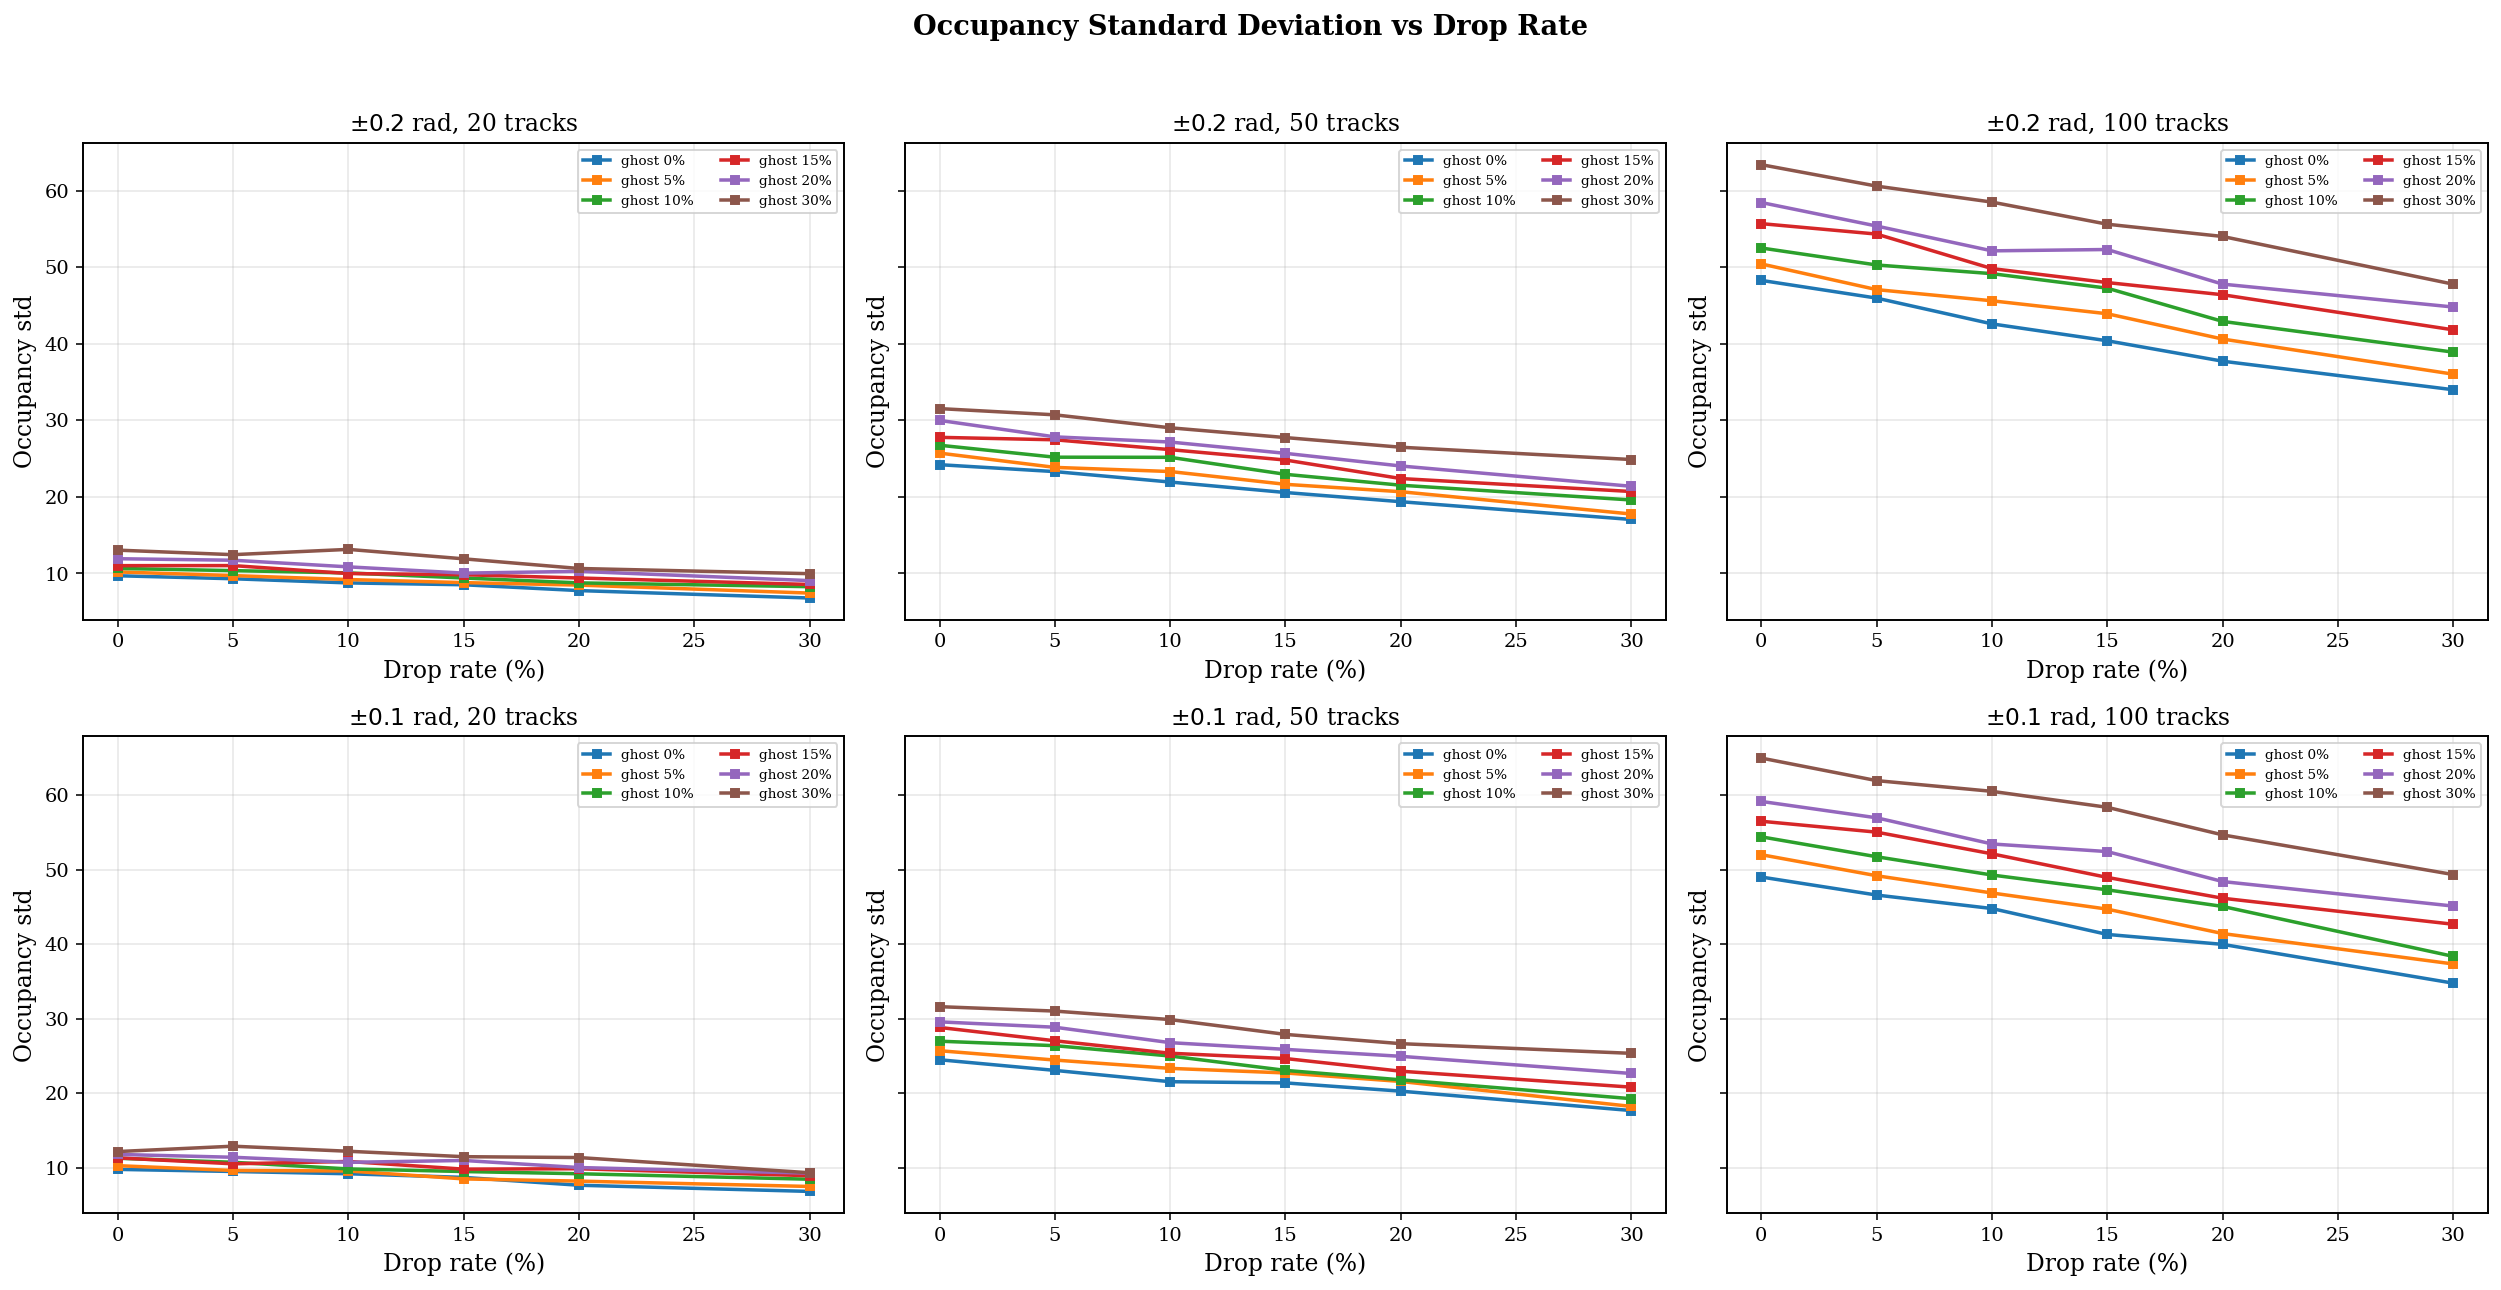

In [7]:
# ── Occupancy std vs ghost rate (lines, one curve per drop rate) ──
fig, axes = plt.subplots(len(angles), len(track_counts),
                         figsize=(6 * len(track_counts),
                                  4.5 * len(angles)),
                         squeeze=False, sharey="row")

for row, angle in enumerate(angles):
    for col, n_trk in enumerate(track_counts):
        ax = axes[row][col]
        sub = df[(df["angle"] == angle) & (df["n_tracks"] == n_trk)]

        for dr in drop_rates:
            curve = sub[sub["drop_rate"] == dr].sort_values("ghost_rate")
            ax.plot(curve["ghost_rate"] * 100, curve["occ_std"],
                    "o-", label=f"drop {dr:.0%}", markersize=4)

        ax.set_xlabel("Ghost rate (%)")
        ax.set_ylabel("Occupancy std")
        ax.set_title(f"$\\pm{angle}$ rad, {n_trk} tracks")
        ax.legend(fontsize=7, ncol=2)
        ax.grid(True, alpha=0.3)

plt.suptitle("Occupancy Standard Deviation vs Ghost Rate",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "occ_std_vs_ghost")
plt.show()

# ── Same, but vs drop rate (one curve per ghost rate) ──
fig, axes = plt.subplots(len(angles), len(track_counts),
                         figsize=(6 * len(track_counts),
                                  4.5 * len(angles)),
                         squeeze=False, sharey="row")

for row, angle in enumerate(angles):
    for col, n_trk in enumerate(track_counts):
        ax = axes[row][col]
        sub = df[(df["angle"] == angle) & (df["n_tracks"] == n_trk)]

        for gr in ghost_rates:
            curve = sub[sub["ghost_rate"] == gr].sort_values("drop_rate")
            ax.plot(curve["drop_rate"] * 100, curve["occ_std"],
                    "s-", label=f"ghost {gr:.0%}", markersize=4)

        ax.set_xlabel("Drop rate (%)")
        ax.set_ylabel("Occupancy std")
        ax.set_title(f"$\\pm{angle}$ rad, {n_trk} tracks")
        ax.legend(fontsize=7, ncol=2)
        ax.grid(True, alpha=0.3)

plt.suptitle("Occupancy Standard Deviation vs Drop Rate",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "occ_std_vs_drop")
plt.show()

## Section 3 — Hits Per Module Variability

Geometric clipping removes hits from the outermost modules for tracks at large angles. Ghost and dropped hits modify the per-module hit counts. We examine the coefficient of variation (std/mean) of hits across modules.

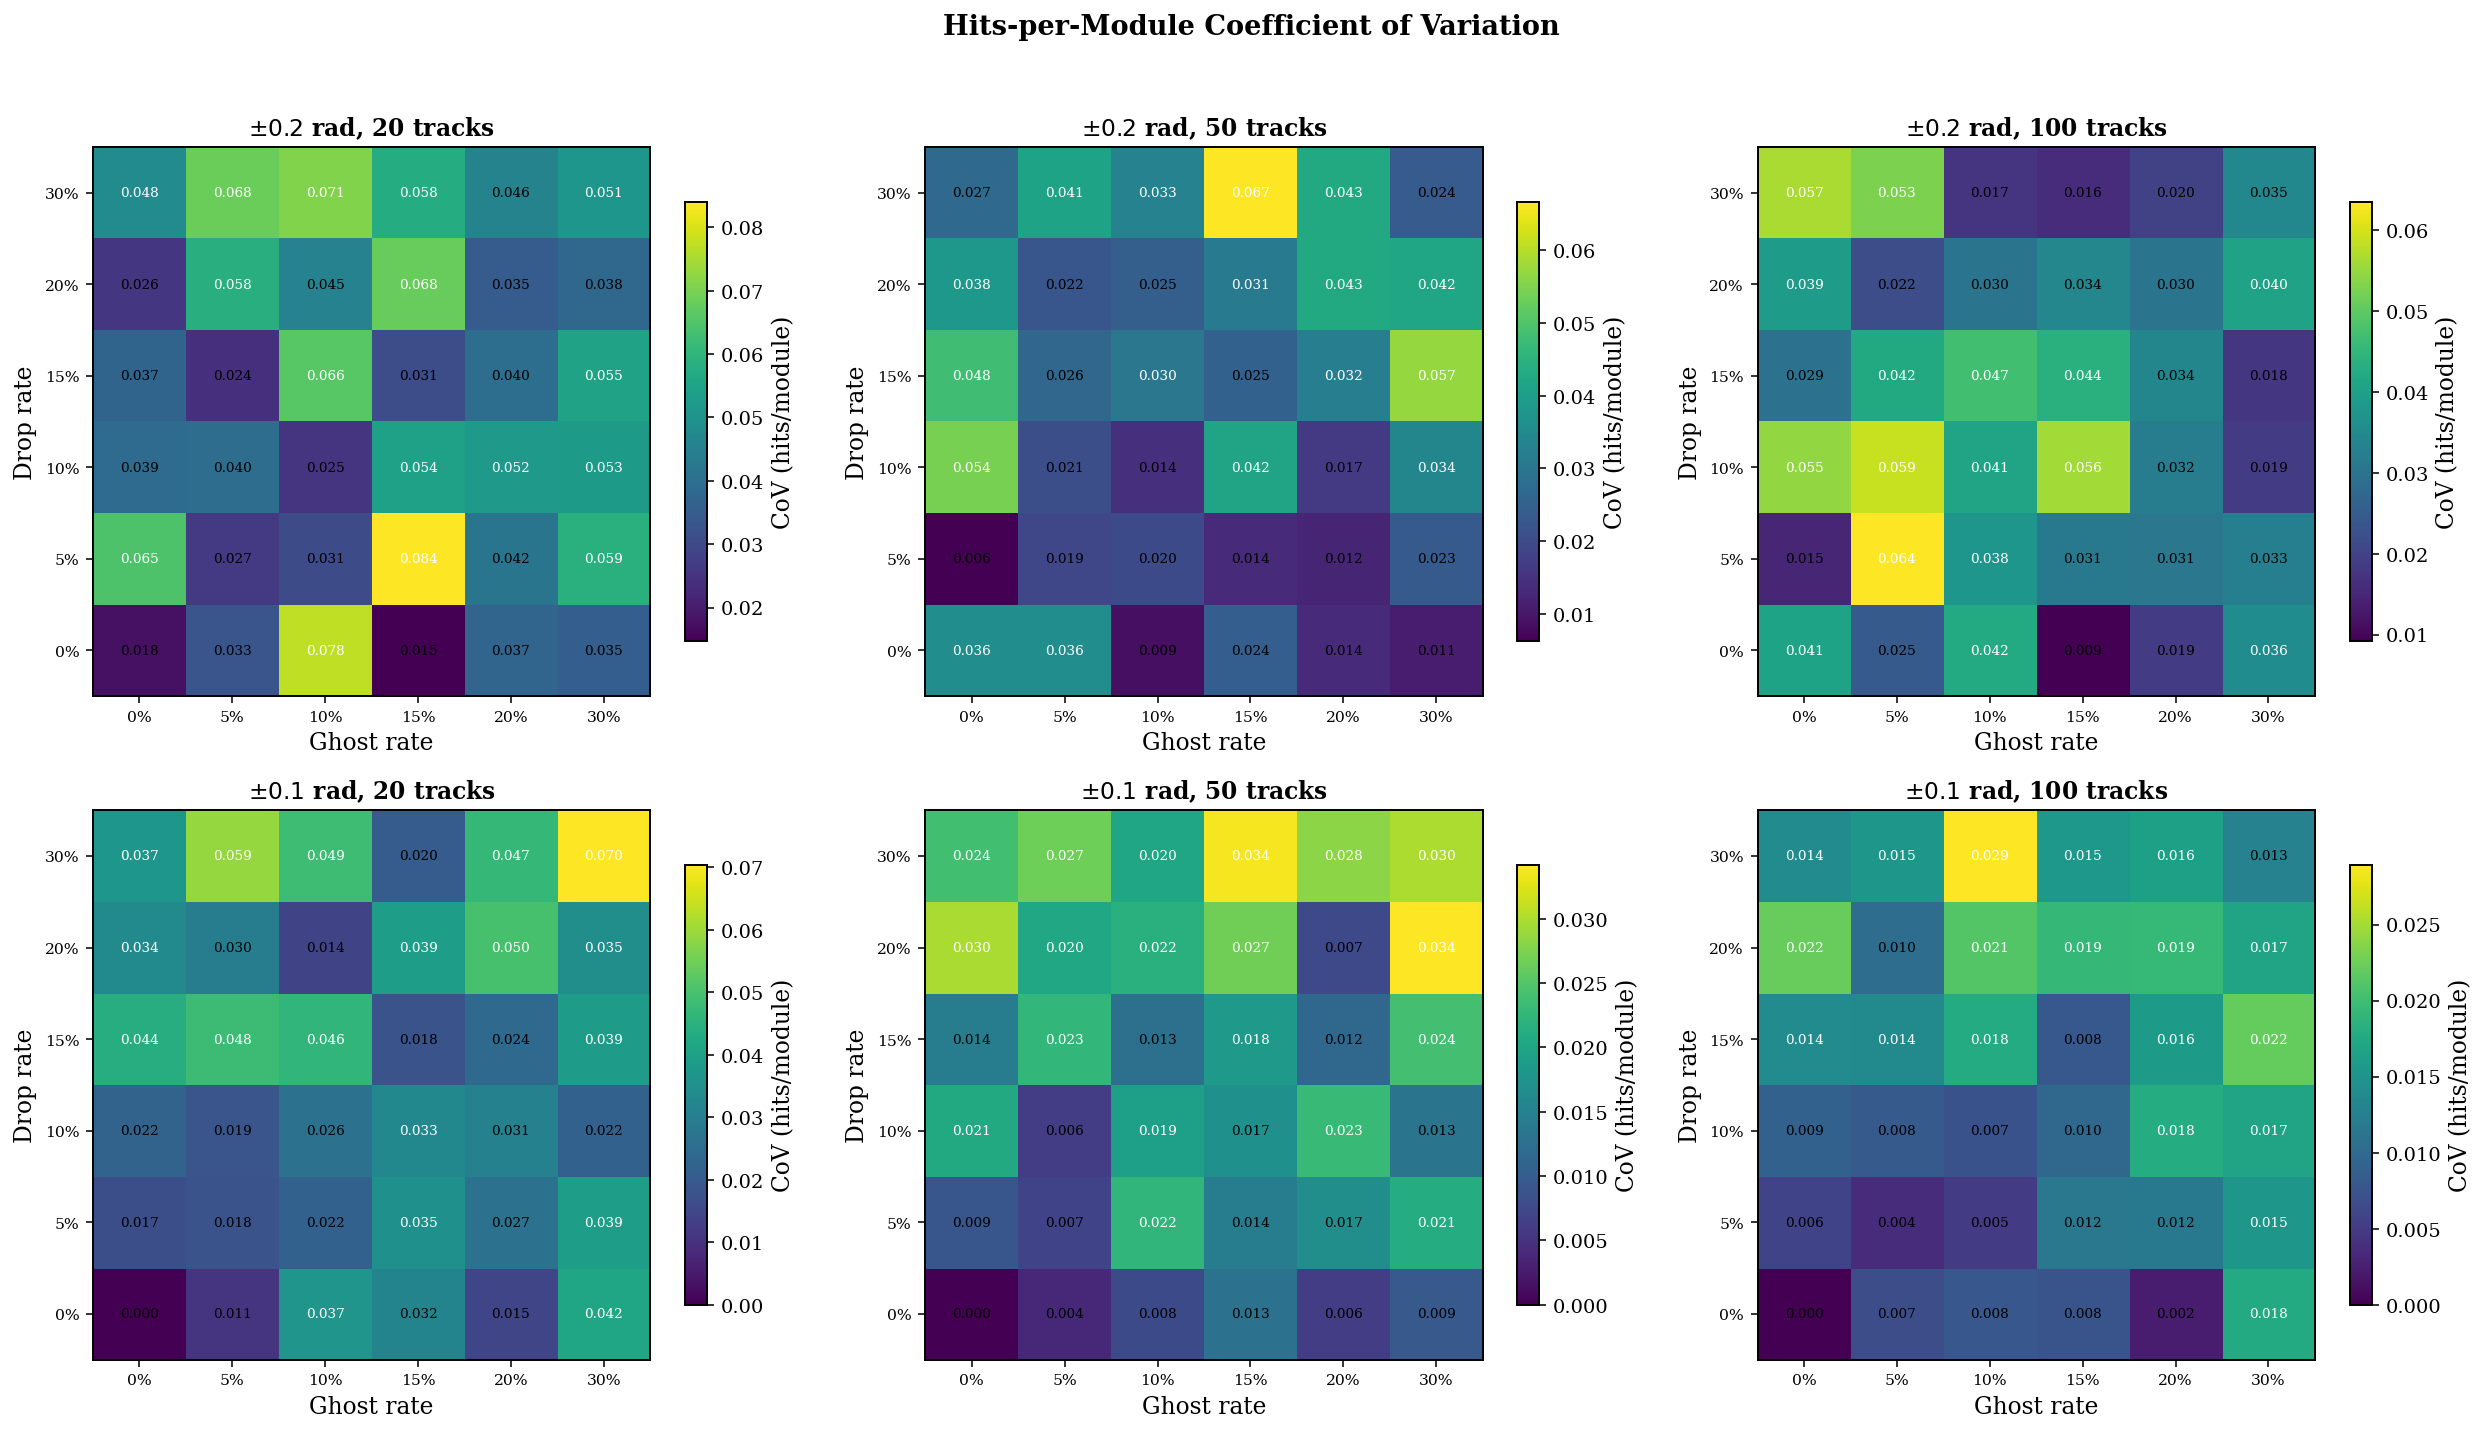

In [8]:
# ── Hits-per-module coefficient of variation heatmaps ──────────
# Compute CoV from per-module mean columns
mod_cols = [f"hits_mod{m}_mean" for m in range(5)]
available_mod_cols = [c for c in mod_cols if c in df.columns]

if len(available_mod_cols) >= 2:
    mod_arr = df[available_mod_cols].values
    df["hits_per_module_cv"] = np.std(mod_arr, axis=1) / np.clip(np.mean(mod_arr, axis=1), 1e-9, None)

    fig, axes = plt.subplots(len(angles), len(track_counts),
                             figsize=(6 * len(track_counts),
                                      5 * len(angles)),
                             squeeze=False)

    for row, angle in enumerate(angles):
        for col, n_trk in enumerate(track_counts):
            ax = axes[row][col]
            sub = df[(df["angle"] == angle) & (df["n_tracks"] == n_trk)]

            piv = sub.pivot_table(
                index="drop_rate", columns="ghost_rate",
                values="hits_per_module_cv", aggfunc="first")
            piv = piv.reindex(index=drop_rates, columns=ghost_rates)

            im = ax.imshow(piv.values, aspect="auto",
                           cmap="viridis", origin="lower")

            ax.set_xticks(range(len(ghost_rates)))
            ax.set_xticklabels([f"{g:.0%}" for g in ghost_rates], fontsize=8)
            ax.set_yticks(range(len(drop_rates)))
            ax.set_yticklabels([f"{d:.0%}" for d in drop_rates], fontsize=8)
            ax.set_xlabel("Ghost rate")
            ax.set_ylabel("Drop rate")
            ax.set_title(f"$\\pm{angle}$ rad, {n_trk} tracks", fontweight="bold")

            for i in range(len(drop_rates)):
                for j in range(len(ghost_rates)):
                    val = piv.values[i, j]
                    if not np.isnan(val):
                        color = "white" if val > piv.values[~np.isnan(piv.values)].mean() else "black"
                        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                                fontsize=7, color=color)

            plt.colorbar(im, ax=ax, label="CoV (hits/module)", shrink=0.8)

    plt.suptitle("Hits-per-Module Coefficient of Variation",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    save_fig(fig, "heatmap_hits_module_cv")
    plt.show()
else:
    print("Per-module hit columns not found in data — skipping.")

## Section 4 — Reconstruction Metrics

How do ghost and drop rates affect reconstruction performance? We examine:
- **Reconstruction efficiency** (fraction of true tracks found)
- **Ghost track rate** (fraction of reconstructed tracks with no true match)
- **Clone fraction** (duplicate matches among matched tracks)

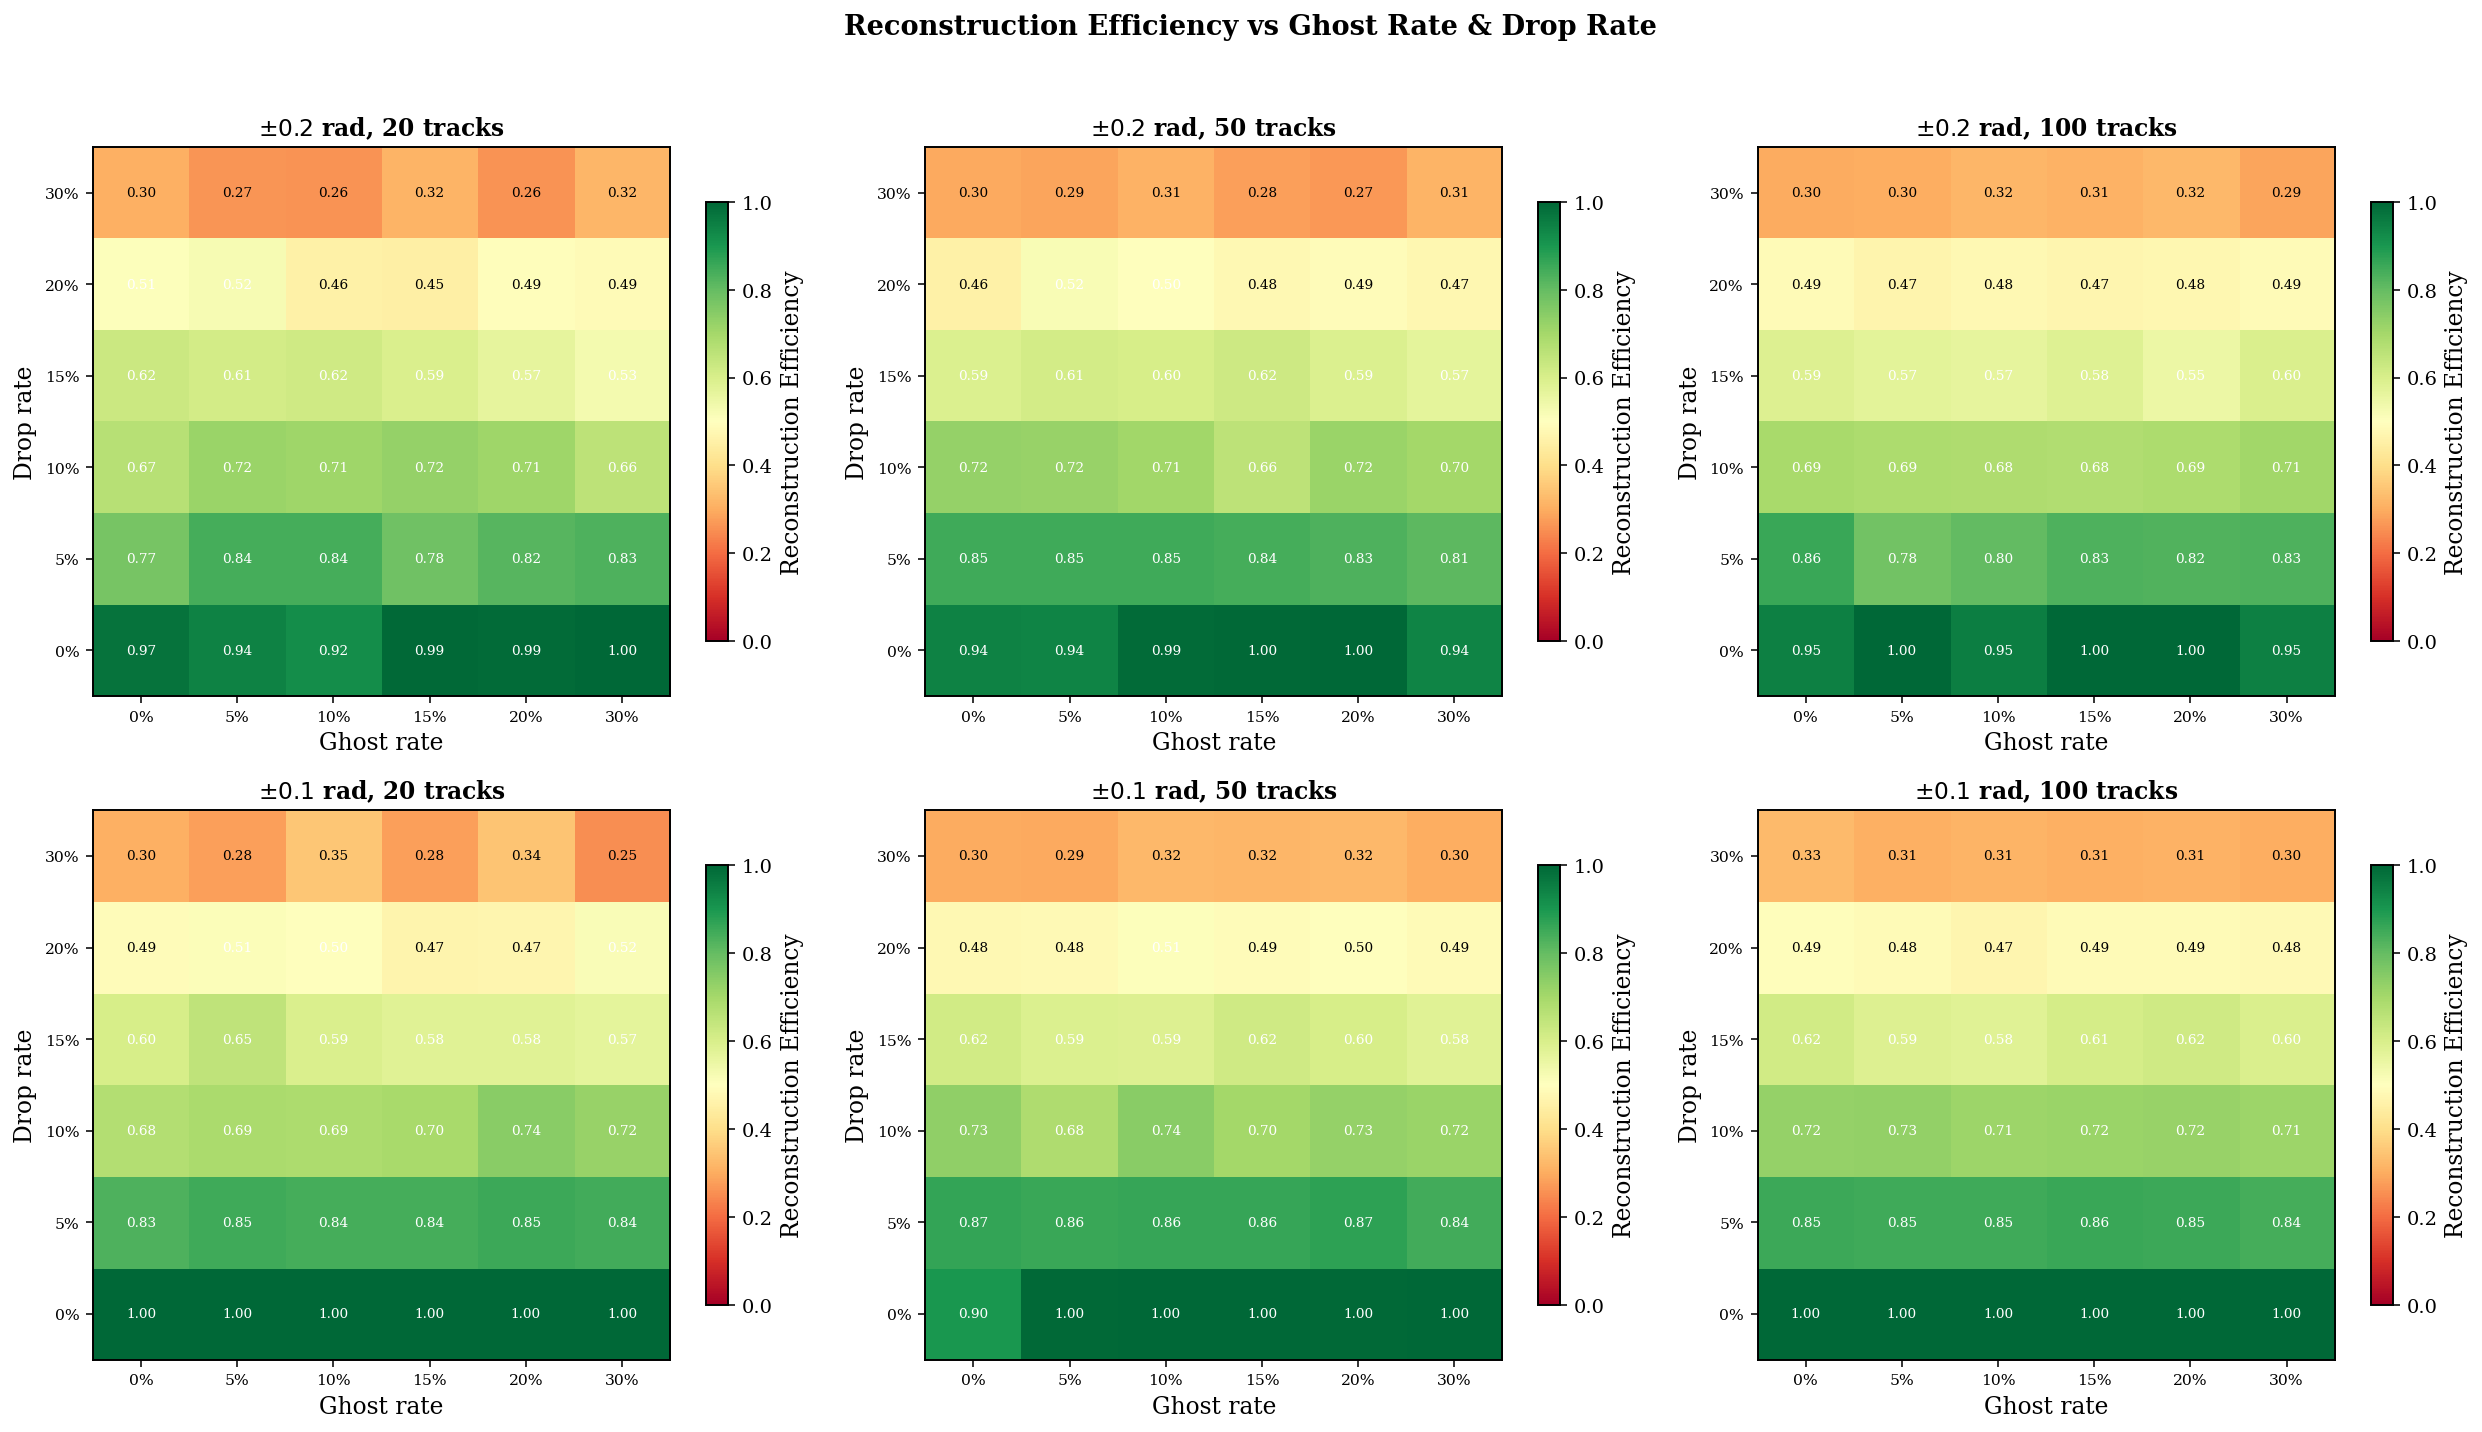

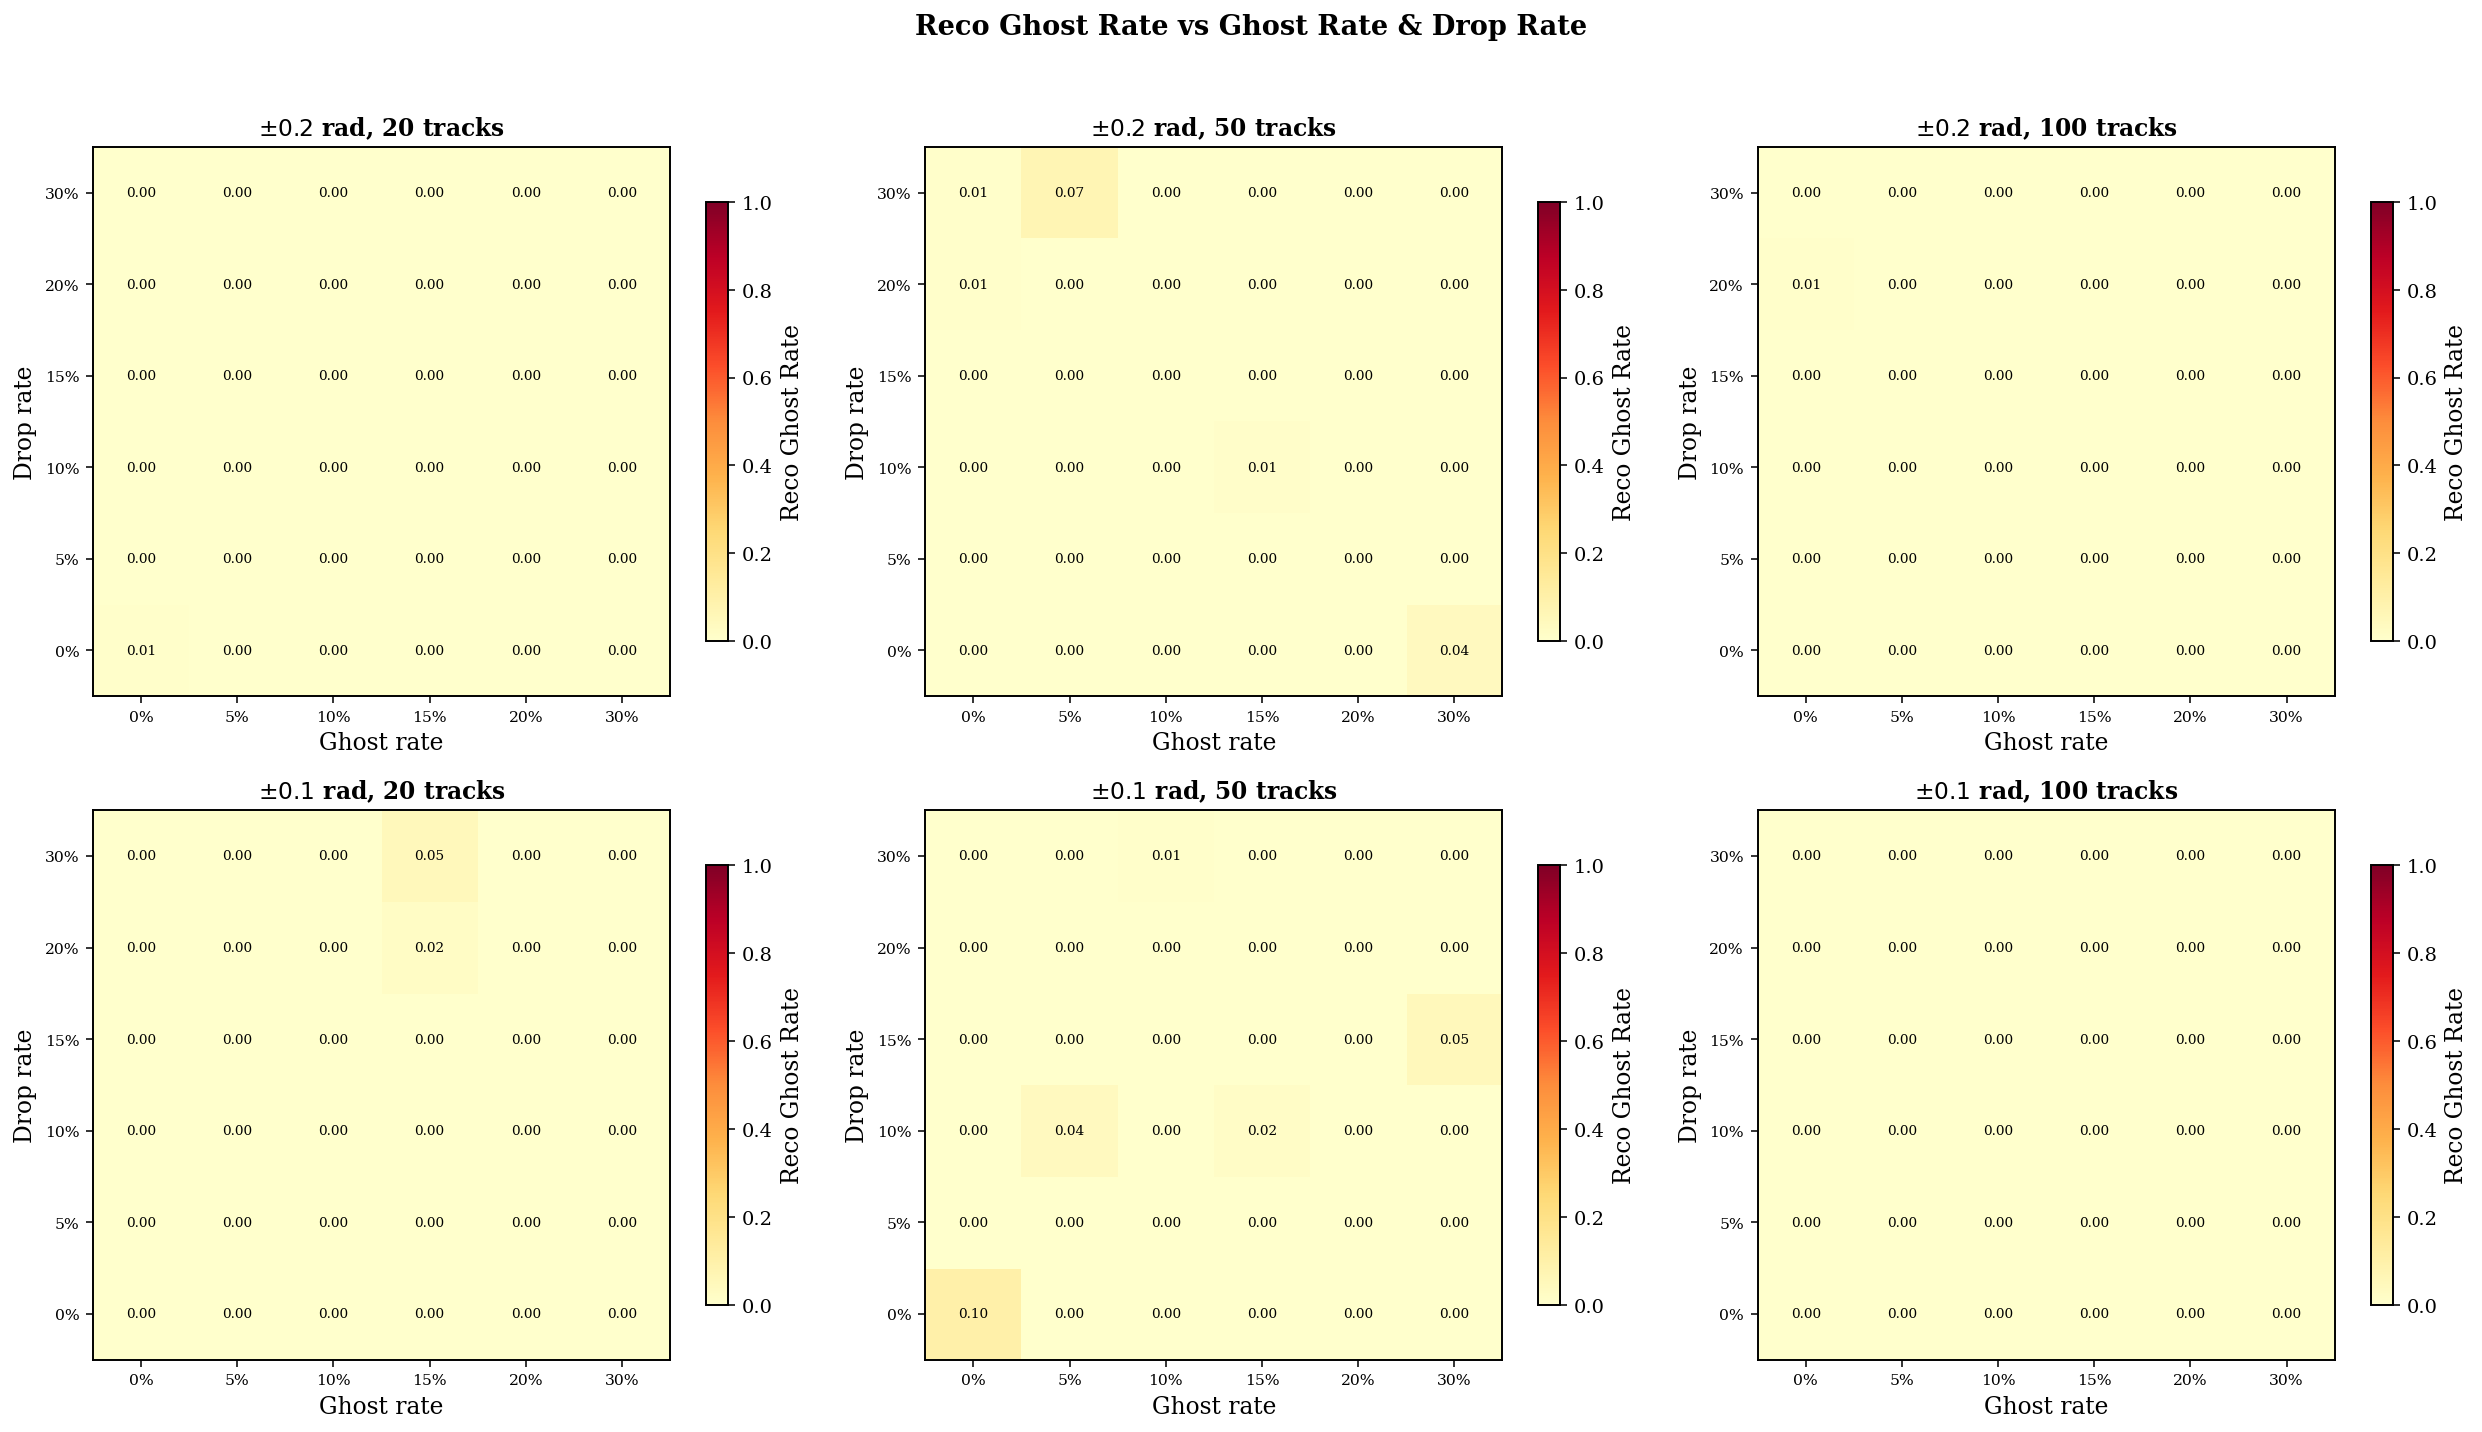

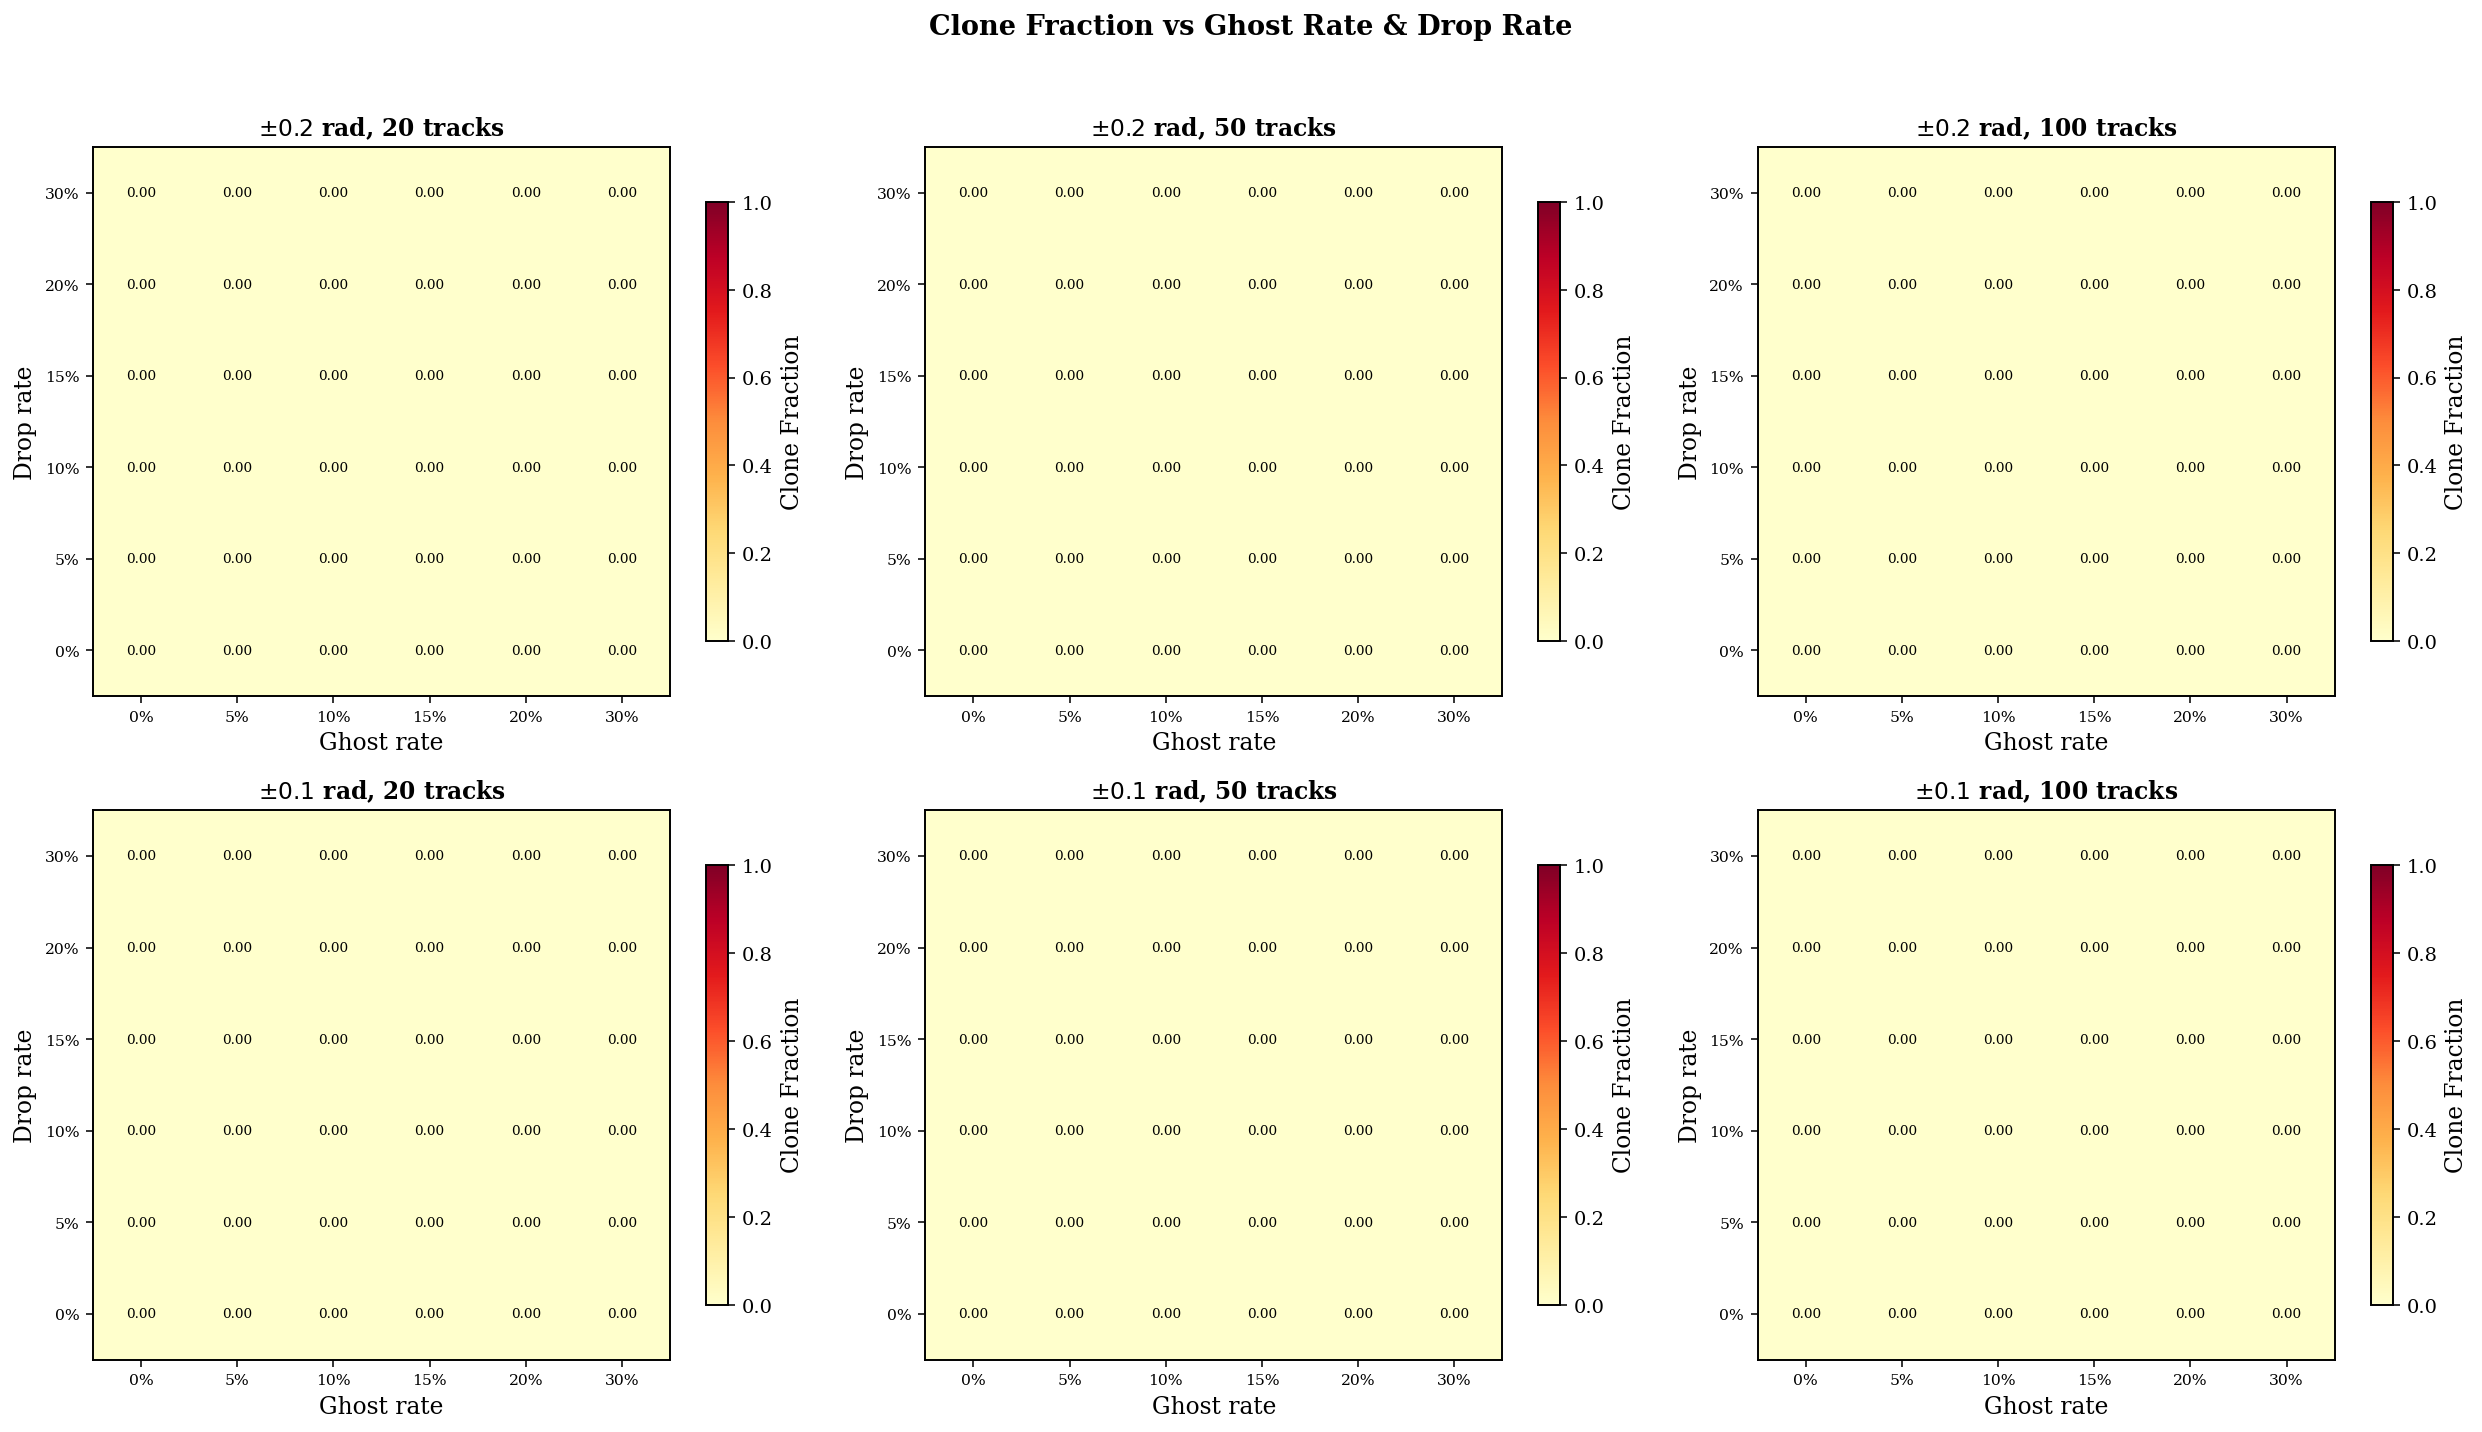

In [9]:
# ── Reconstruction metric heatmaps ──────────────────────────────
reco_metrics = {
    "efficiency":        ("Reconstruction Efficiency",   "RdYlGn",  True),
    "reco_ghost_rate":   ("Reco Ghost Rate",             "YlOrRd",  False),
    "clone_fraction":    ("Clone Fraction",              "YlOrRd",  False),
}

for metric_key, (title, cmap, higher_better) in reco_metrics.items():
    if metric_key not in df.columns:
        print(f"Skipping {metric_key} — not in data")
        continue

    fig, axes = plt.subplots(len(angles), len(track_counts),
                             figsize=(6 * len(track_counts),
                                      5 * len(angles)),
                             squeeze=False)

    for row, angle in enumerate(angles):
        for col, n_trk in enumerate(track_counts):
            ax = axes[row][col]
            sub = df[(df["angle"] == angle) & (df["n_tracks"] == n_trk)]

            piv = sub.pivot_table(
                index="drop_rate", columns="ghost_rate",
                values=metric_key, aggfunc="first")
            piv = piv.reindex(index=drop_rates, columns=ghost_rates)

            im = ax.imshow(piv.values, aspect="auto",
                           cmap=cmap, origin="lower",
                           vmin=0, vmax=1)

            ax.set_xticks(range(len(ghost_rates)))
            ax.set_xticklabels([f"{g:.0%}" for g in ghost_rates], fontsize=8)
            ax.set_yticks(range(len(drop_rates)))
            ax.set_yticklabels([f"{d:.0%}" for d in drop_rates], fontsize=8)
            ax.set_xlabel("Ghost rate")
            ax.set_ylabel("Drop rate")
            ax.set_title(f"$\\pm{angle}$ rad, {n_trk} tracks", fontweight="bold")

            for i in range(len(drop_rates)):
                for j in range(len(ghost_rates)):
                    val = piv.values[i, j]
                    if not np.isnan(val):
                        color = "white" if val > 0.5 else "black"
                        ax.text(j, i, f"{val:.2f}", ha="center",
                                va="center", fontsize=7, color=color)

            plt.colorbar(im, ax=ax, label=title, shrink=0.8)

    plt.suptitle(f"{title} vs Ghost Rate & Drop Rate",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    save_fig(fig, f"heatmap_{metric_key}")
    plt.show()

## Section 5 — Mean Number of Segments

The total number of segments (true + false) reflects the Hamiltonian size. Ghost hits create extra segments; dropped hits remove some. We track how the mean segment count evolves across the sweep.

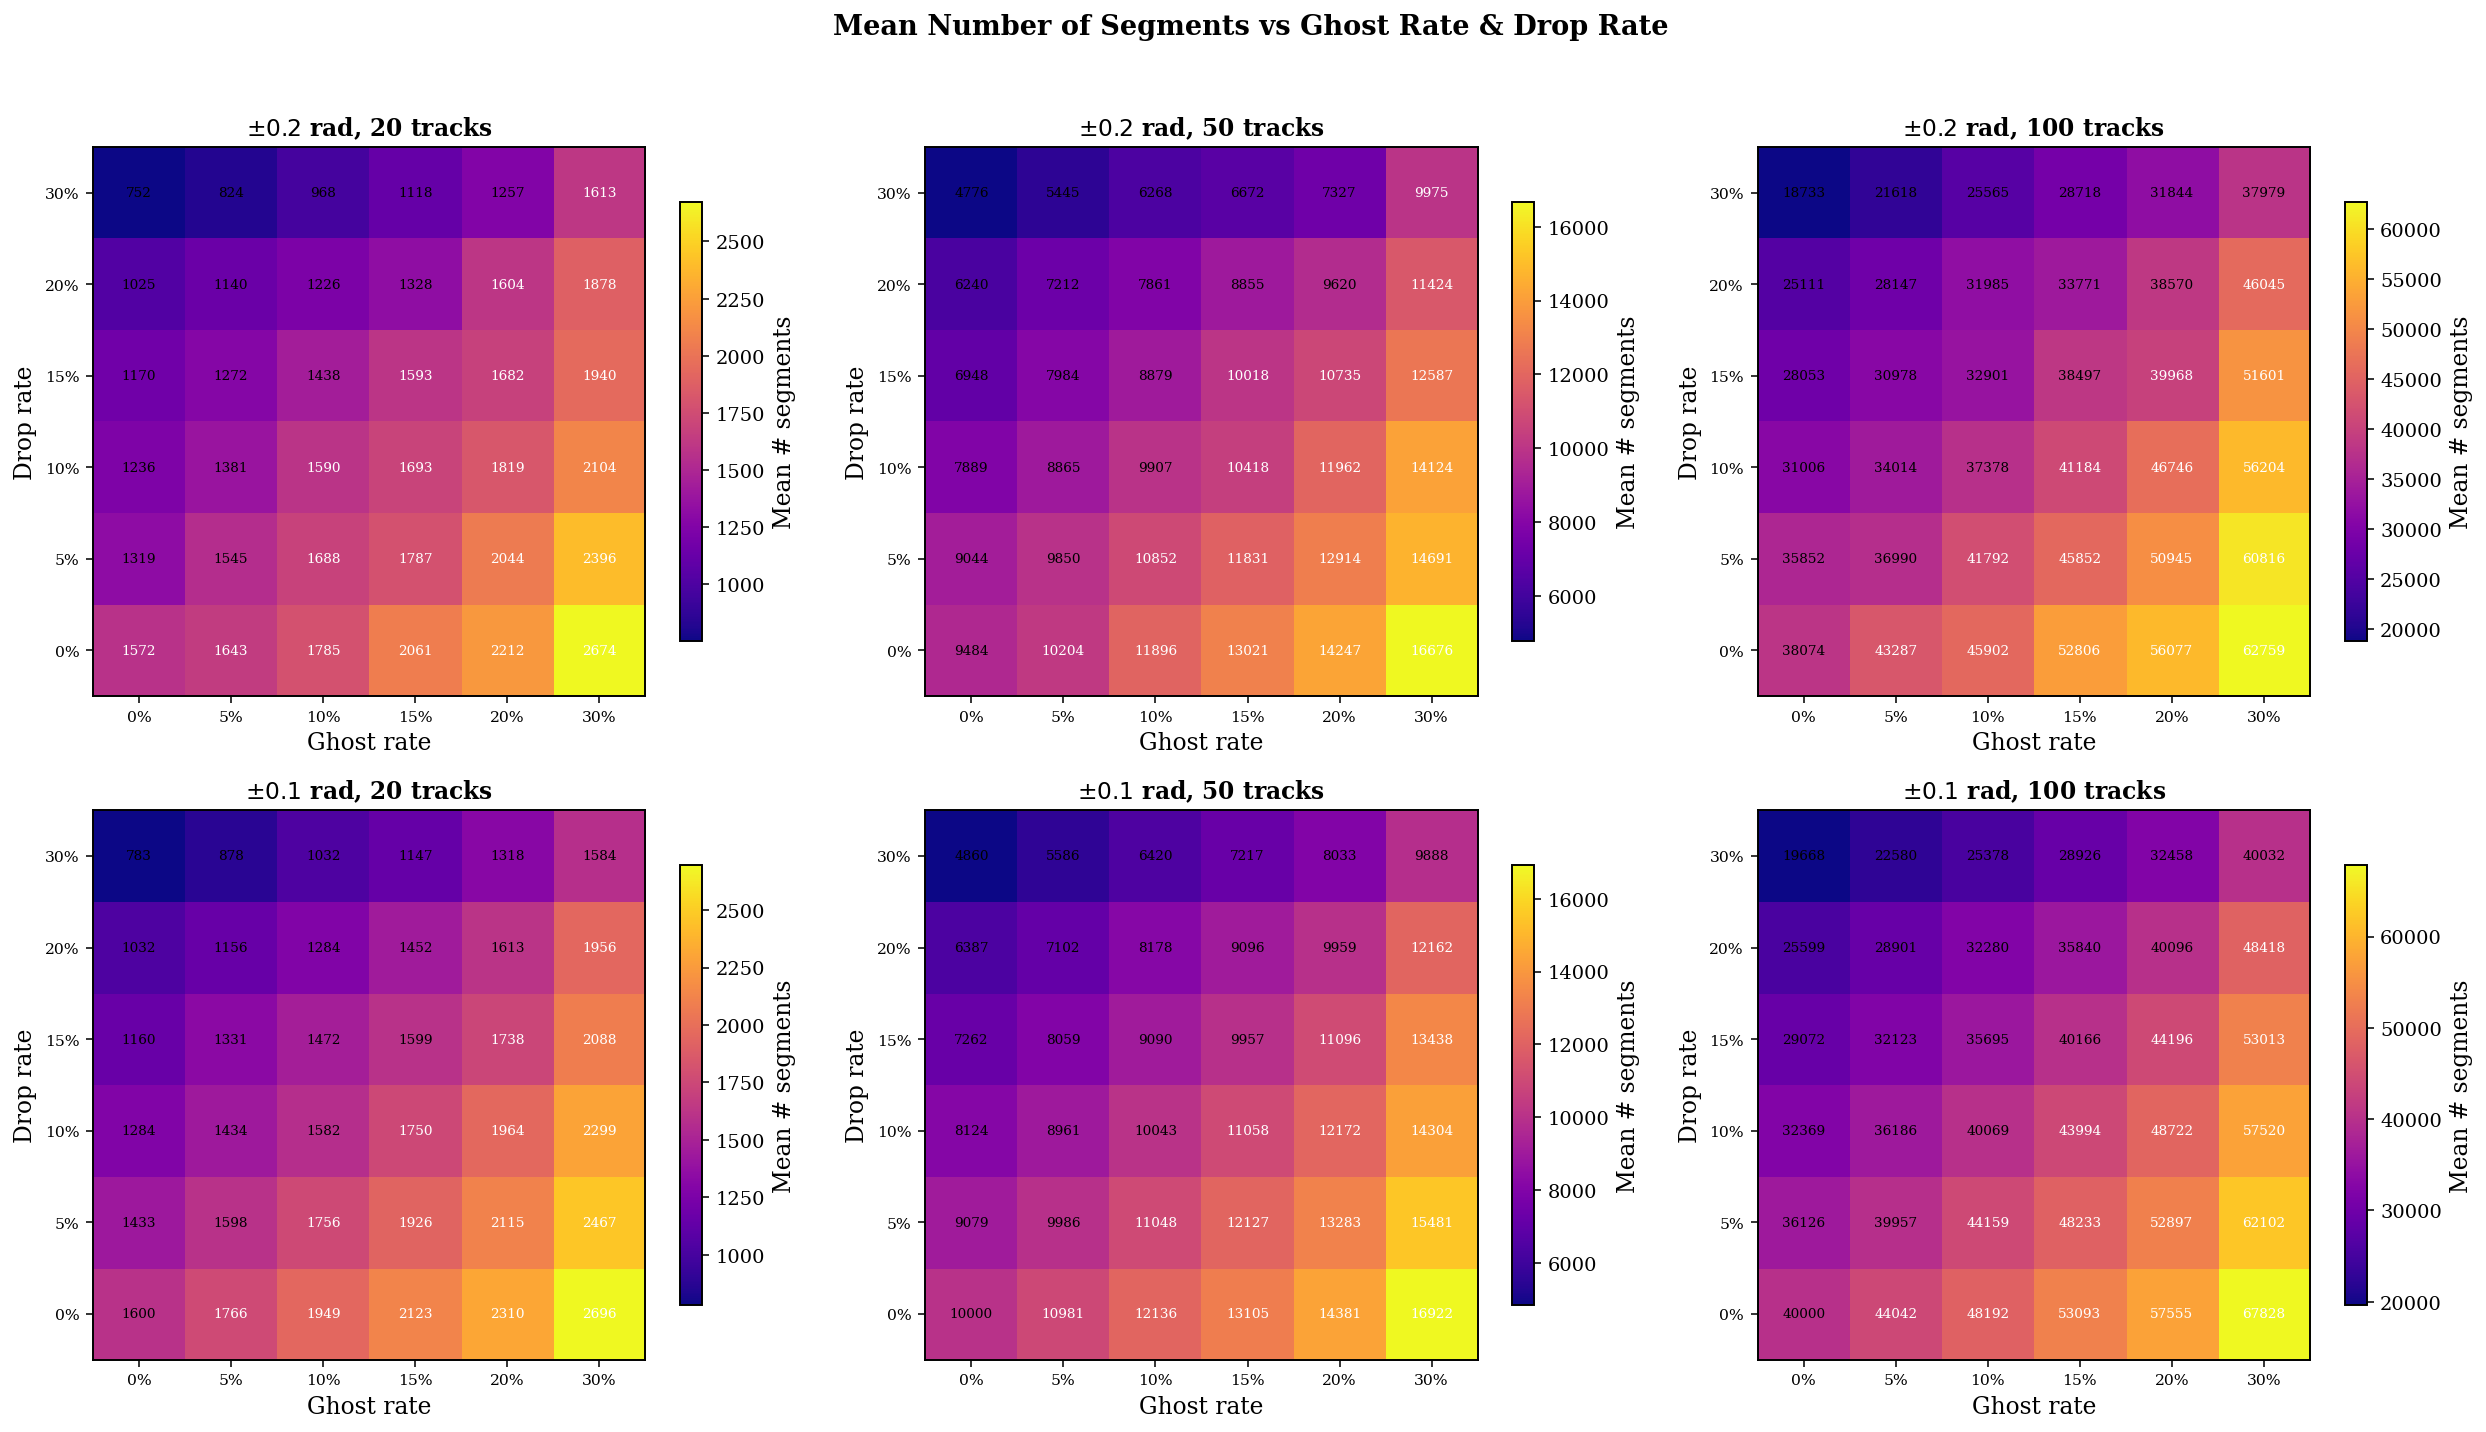

In [10]:
# ── Mean segment count heatmaps ────────────────────────────────
fig, axes = plt.subplots(len(angles), len(track_counts),
                         figsize=(6 * len(track_counts),
                                  5 * len(angles)),
                         squeeze=False)

for row, angle in enumerate(angles):
    for col, n_trk in enumerate(track_counts):
        ax = axes[row][col]
        sub = df[(df["angle"] == angle) & (df["n_tracks"] == n_trk)]

        piv = sub.pivot_table(
            index="drop_rate", columns="ghost_rate",
            values="mean_n_segments", aggfunc="first")
        piv = piv.reindex(index=drop_rates, columns=ghost_rates)

        im = ax.imshow(piv.values, aspect="auto",
                       cmap="plasma", origin="lower")

        ax.set_xticks(range(len(ghost_rates)))
        ax.set_xticklabels([f"{g:.0%}" for g in ghost_rates], fontsize=8)
        ax.set_yticks(range(len(drop_rates)))
        ax.set_yticklabels([f"{d:.0%}" for d in drop_rates], fontsize=8)
        ax.set_xlabel("Ghost rate")
        ax.set_ylabel("Drop rate")
        ax.set_title(f"$\\pm{angle}$ rad, {n_trk} tracks", fontweight="bold")

        for i in range(len(drop_rates)):
            for j in range(len(ghost_rates)):
                val = piv.values[i, j]
                if not np.isnan(val):
                    color = "white" if val > piv.values[~np.isnan(piv.values)].mean() else "black"
                    ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                            fontsize=7, color=color)

        plt.colorbar(im, ax=ax, label="Mean # segments", shrink=0.8)

plt.suptitle("Mean Number of Segments vs Ghost Rate & Drop Rate",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "heatmap_n_segments")
plt.show()

## Section 6 — Activation Spectrum Comparison

Compare the distribution of segment activations between the clean baseline (ghost=0, drop=0) and selected noisy configurations. True segment activations should cluster near 1, while false segments cluster near 0 — noise disrupts this separation.

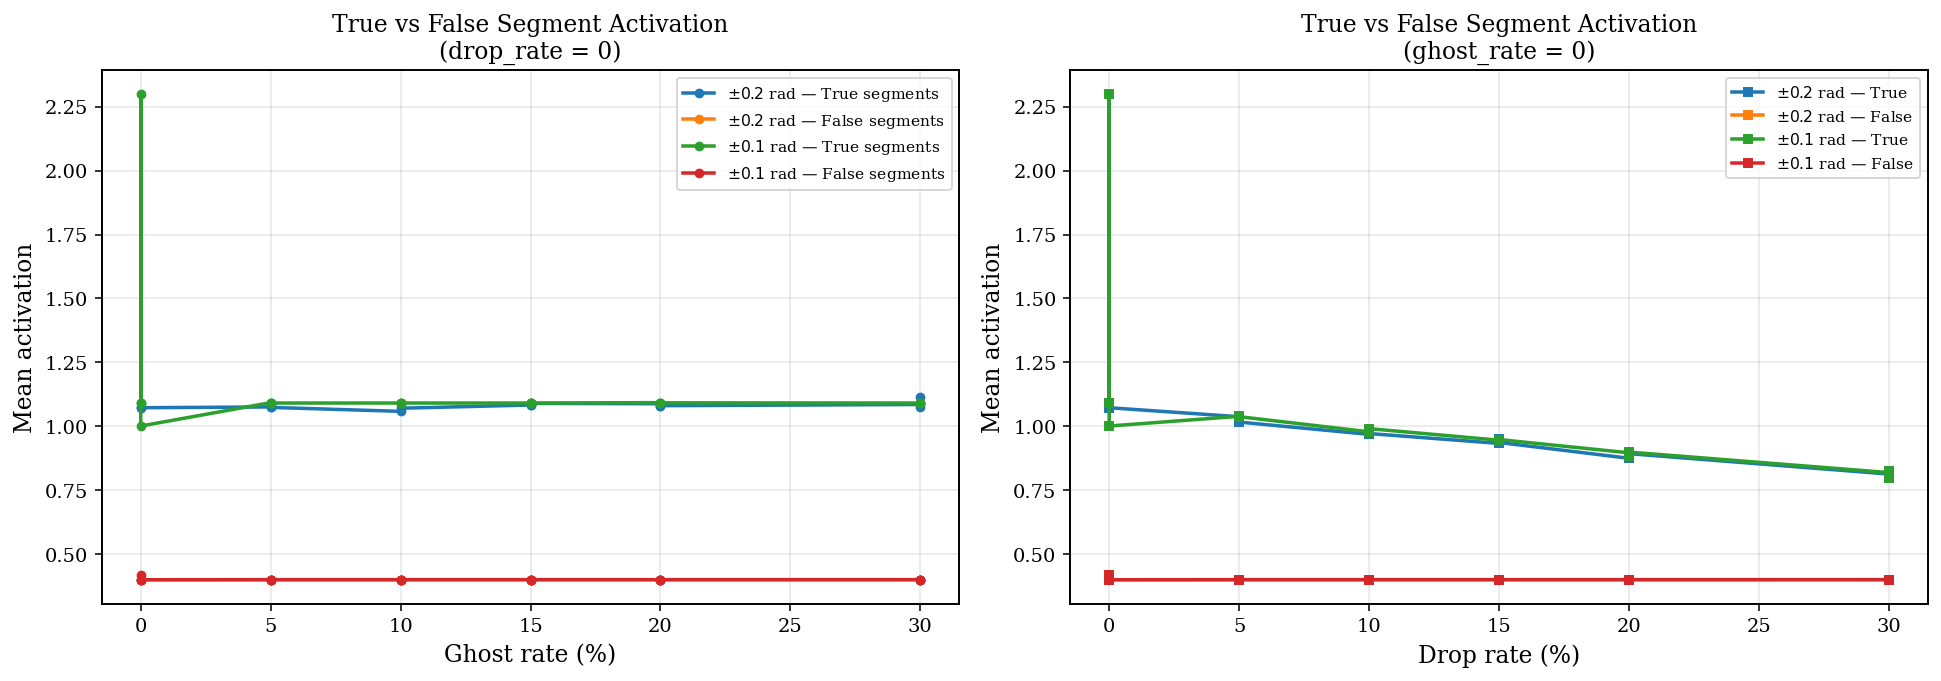

In [11]:
# ── Activation spectrum: mean true vs false activation ──────────
# Compare mean true-segment activation and mean false-segment activation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric_pair, labels in [
    (axes[0],
     ("mean_true_activation", "mean_false_activation"),
     ("True segments", "False segments")),
    (axes[1],
     ("mean_true_activation",),
     ("True segments",)),
]:
    for angle in angles:
        sub = df[(df["angle"] == angle) & (df["drop_rate"] == 0.0)]
        sub = sub.sort_values("ghost_rate")
        for mk, ls, col in zip(metric_pair, labels, ["tab:blue", "tab:red"]):
            if mk not in df.columns:
                continue
            ax.plot(sub["ghost_rate"] * 100, sub[mk],
                    "o-", label=f"$\\pm{angle}$ rad — {ls}",
                    markersize=4)

if "mean_true_activation" in df.columns:
    axes[0].set_xlabel("Ghost rate (%)")
    axes[0].set_ylabel("Mean activation")
    axes[0].set_title("True vs False Segment Activation\n(drop_rate = 0)")
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # Second panel: true activation vs drop rate at ghost=0
    axes[1].cla()
    for angle in angles:
        sub = df[(df["angle"] == angle) & (df["ghost_rate"] == 0.0)]
        sub = sub.sort_values("drop_rate")
        for mk, ls in [("mean_true_activation", "True"),
                        ("mean_false_activation", "False")]:
            if mk not in df.columns:
                continue
            axes[1].plot(sub["drop_rate"] * 100, sub[mk],
                         "s-", label=f"$\\pm{angle}$ rad — {ls}",
                         markersize=4)
    axes[1].set_xlabel("Drop rate (%)")
    axes[1].set_ylabel("Mean activation")
    axes[1].set_title("True vs False Segment Activation\n(ghost_rate = 0)")
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)
else:
    for ax in axes:
        ax.text(0.5, 0.5, "Activation data not available",
                transform=ax.transAxes, ha="center", va="center", fontsize=12)

plt.tight_layout()
save_fig(fig, "activation_spectrum")
plt.show()

---
## Section 7 — Selected-Segment Corpus

So far every analysis has been computed over the **full segment corpus** built by the Hamiltonian (every geometrically allowed pair of hits in adjacent modules). This is the input to the solver.

The **selected corpus** is the subset of segments whose classical-solver activation exceeds the threshold ($x_i > $ THRESHOLD$\;\approx$ 0.7); these are the segments that survive into the track-building stage and define the reconstructed event.

This section repeats the full battery of diagnostics on this restricted corpus to reveal what residual segment grass remains *after* the matrix inversion has performed its filtering. Per-hit occupancy in the selected corpus is now the number of *selected* segments touching that hit; for a clean event each hit is touched by exactly one selected segment (outer modules) or two (inner modules), so the expected occupancy peaks are $\{1, 2\}$ and any other value is anomalous.

> **Note on reconstruction metrics:** efficiency / ghost-rate / clone-fraction are by construction computed *from* the selected corpus (`get_tracks(...)` only sees segments above threshold), so they are identical to Section 4 and not repeated.


### 7.0 — Selected-Corpus Occupancy Histograms

Reproducing the per-hit occupancy histograms from Section 0, but counting only segments with $x_i > $ THRESHOLD. The expected peaks collapse from $\{n,\,2n\}$ to $\{1,\,2\}$.


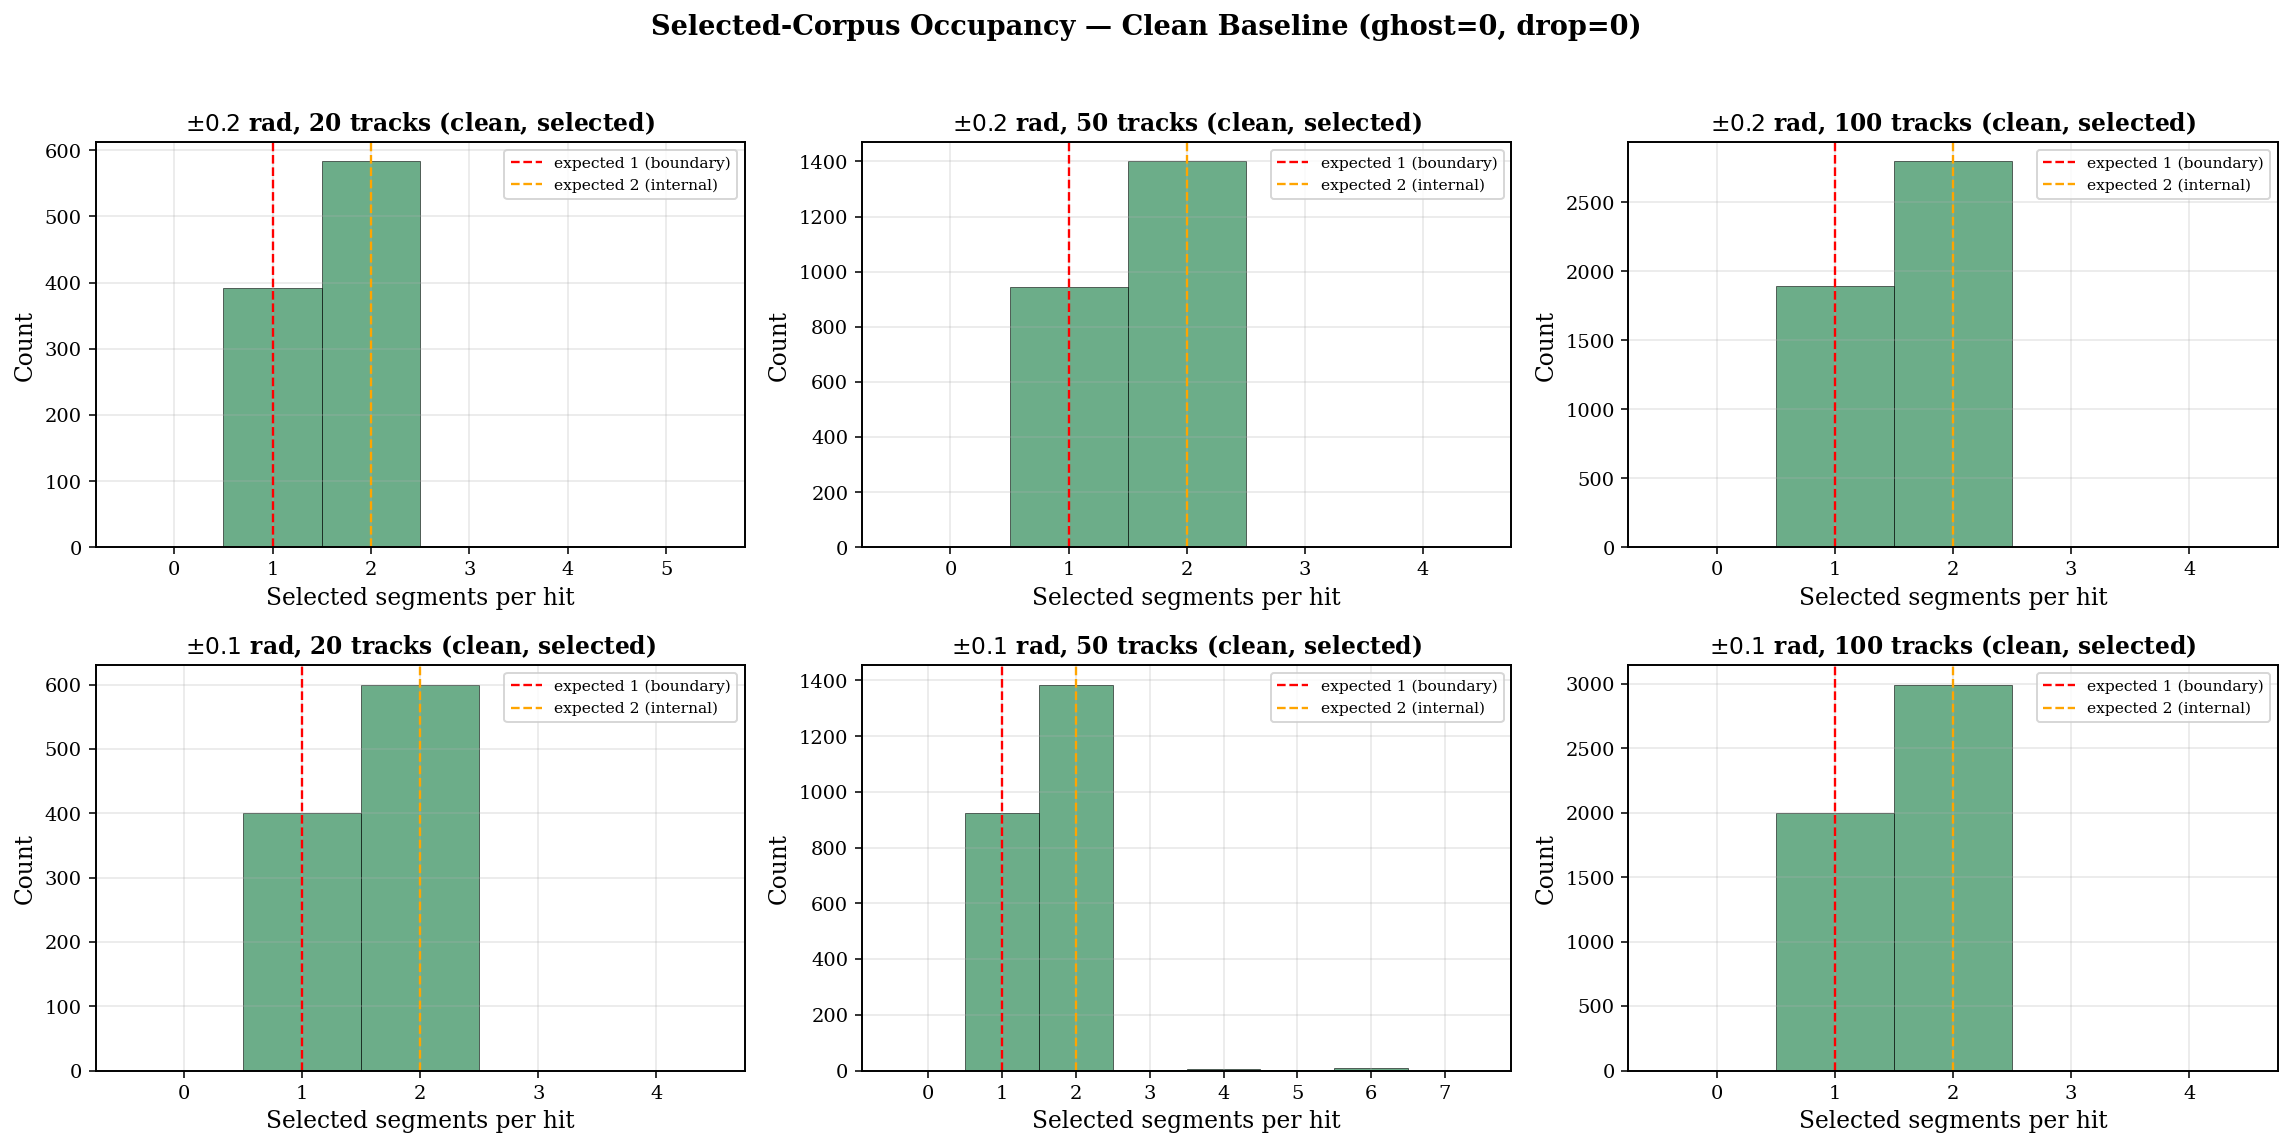

In [12]:
# ── Helper: load selected-corpus occupancy from per-job .npz ────
def load_occ_sel_for_params(angle, n_tracks, ghost_rate, drop_rate):
    """Load the raw selected-corpus per-hit occupancy for a parameter combo."""
    params_dir = RESULTS_DIR / "params"
    for pf in sorted(params_dir.glob("job_*.json")):
        with open(pf) as f:
            p = json.load(f)
        if (p["angle"] == angle and p["n_tracks"] == n_tracks
                and p["ghost_rate"] == ghost_rate
                and p["drop_rate"] == drop_rate):
            npz_path = RESULTS_DIR / pf.stem / "arrays.npz"
            if npz_path.exists():
                d = np.load(npz_path)
                return d["occ_sel_all"] if "occ_sel_all" in d.files else None
    return None


# ── (a) Clean baseline selected-corpus histograms ───────────────
fig, axes = plt.subplots(len(angles), len(track_counts),
                         figsize=(5.5 * len(track_counts),
                                  4 * len(angles)),
                         squeeze=False)

for row, angle in enumerate(angles):
    for col, n_trk in enumerate(track_counts):
        ax = axes[row][col]
        occ = load_occ_sel_for_params(angle, n_trk, 0.0, 0.0)
        if occ is not None and len(occ) > 0:
            hi = max(int(np.max(occ)) + 2, 5)
            bins = np.arange(0, hi + 1) - 0.5
            ax.hist(occ, bins=bins, alpha=0.7,
                    color="seagreen", edgecolor="black", lw=0.4)
            ax.axvline(1, color="red", ls="--", lw=1.2,
                       label="expected 1 (boundary)")
            ax.axvline(2, color="orange", ls="--", lw=1.2,
                       label="expected 2 (internal)")
            ax.legend(fontsize=8)
        ax.set_xlabel("Selected segments per hit")
        ax.set_ylabel("Count")
        ax.set_title(f"$\\pm{angle}$ rad, {n_trk} tracks (clean, selected)",
                     fontweight="bold")
        ax.grid(True, alpha=0.3)

plt.suptitle("Selected-Corpus Occupancy — Clean Baseline (ghost=0, drop=0)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "occ_sel_hist_clean")
plt.show()


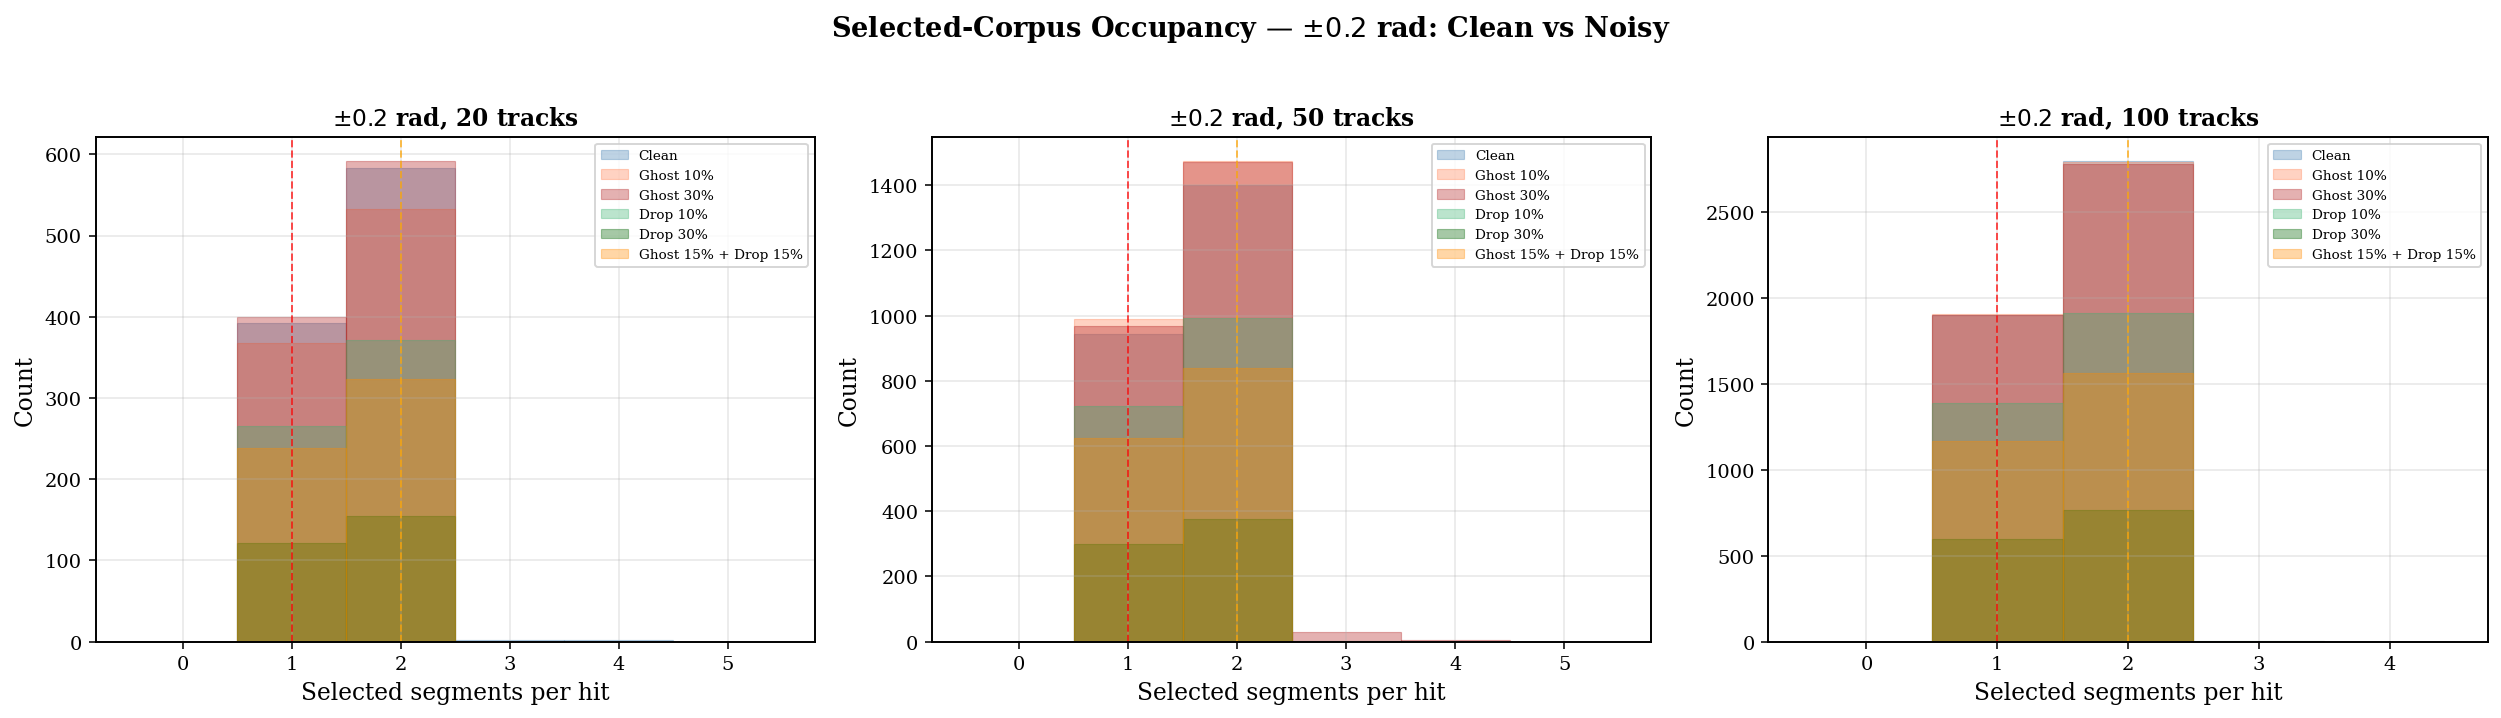

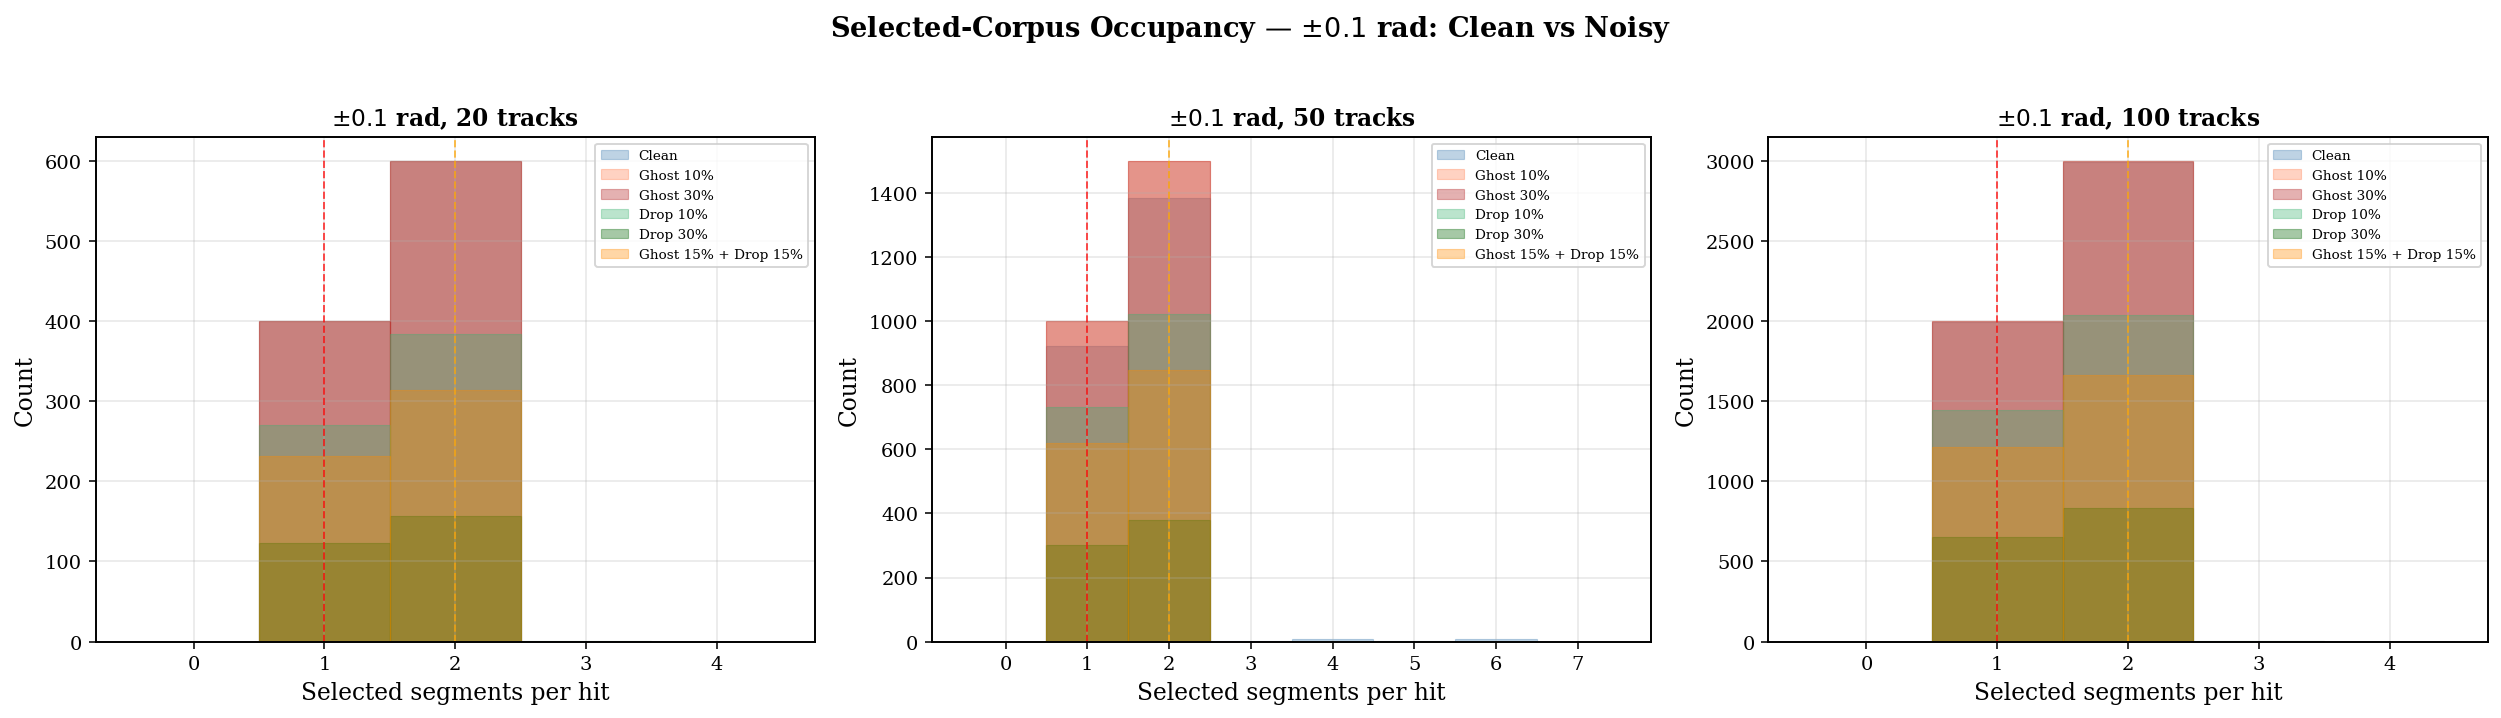

In [13]:
# ── (b) Clean vs noisy overlay (selected corpus) ────────────────
for angle in angles:
    fig, axes_row = plt.subplots(1, len(track_counts),
                                 figsize=(6 * len(track_counts), 5),
                                 squeeze=False)
    for col, n_trk in enumerate(track_counts):
        ax = axes_row[0][col]
        for gr, dr, label, color in noise_configs:
            occ = load_occ_sel_for_params(angle, n_trk, gr, dr)
            if occ is None or len(occ) == 0:
                continue
            hi = max(int(np.max(occ)) + 2, 5)
            bins = np.arange(0, hi + 1) - 0.5
            ax.hist(occ, bins=bins, alpha=0.35, color=color,
                    edgecolor=color, lw=0.6, label=label)

        ax.axvline(1, color="red", ls="--", lw=1.0, alpha=0.7)
        ax.axvline(2, color="orange", ls="--", lw=1.0, alpha=0.7)
        ax.set_xlabel("Selected segments per hit")
        ax.set_ylabel("Count")
        ax.set_title(f"$\\pm{angle}$ rad, {n_trk} tracks", fontweight="bold")
        ax.legend(fontsize=7, loc="upper right")
        ax.grid(True, alpha=0.3)

    plt.suptitle(f"Selected-Corpus Occupancy — $\\pm{angle}$ rad: Clean vs Noisy",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    save_fig(fig, f"occ_sel_hist_comparison_angle{angle}")
    plt.show()


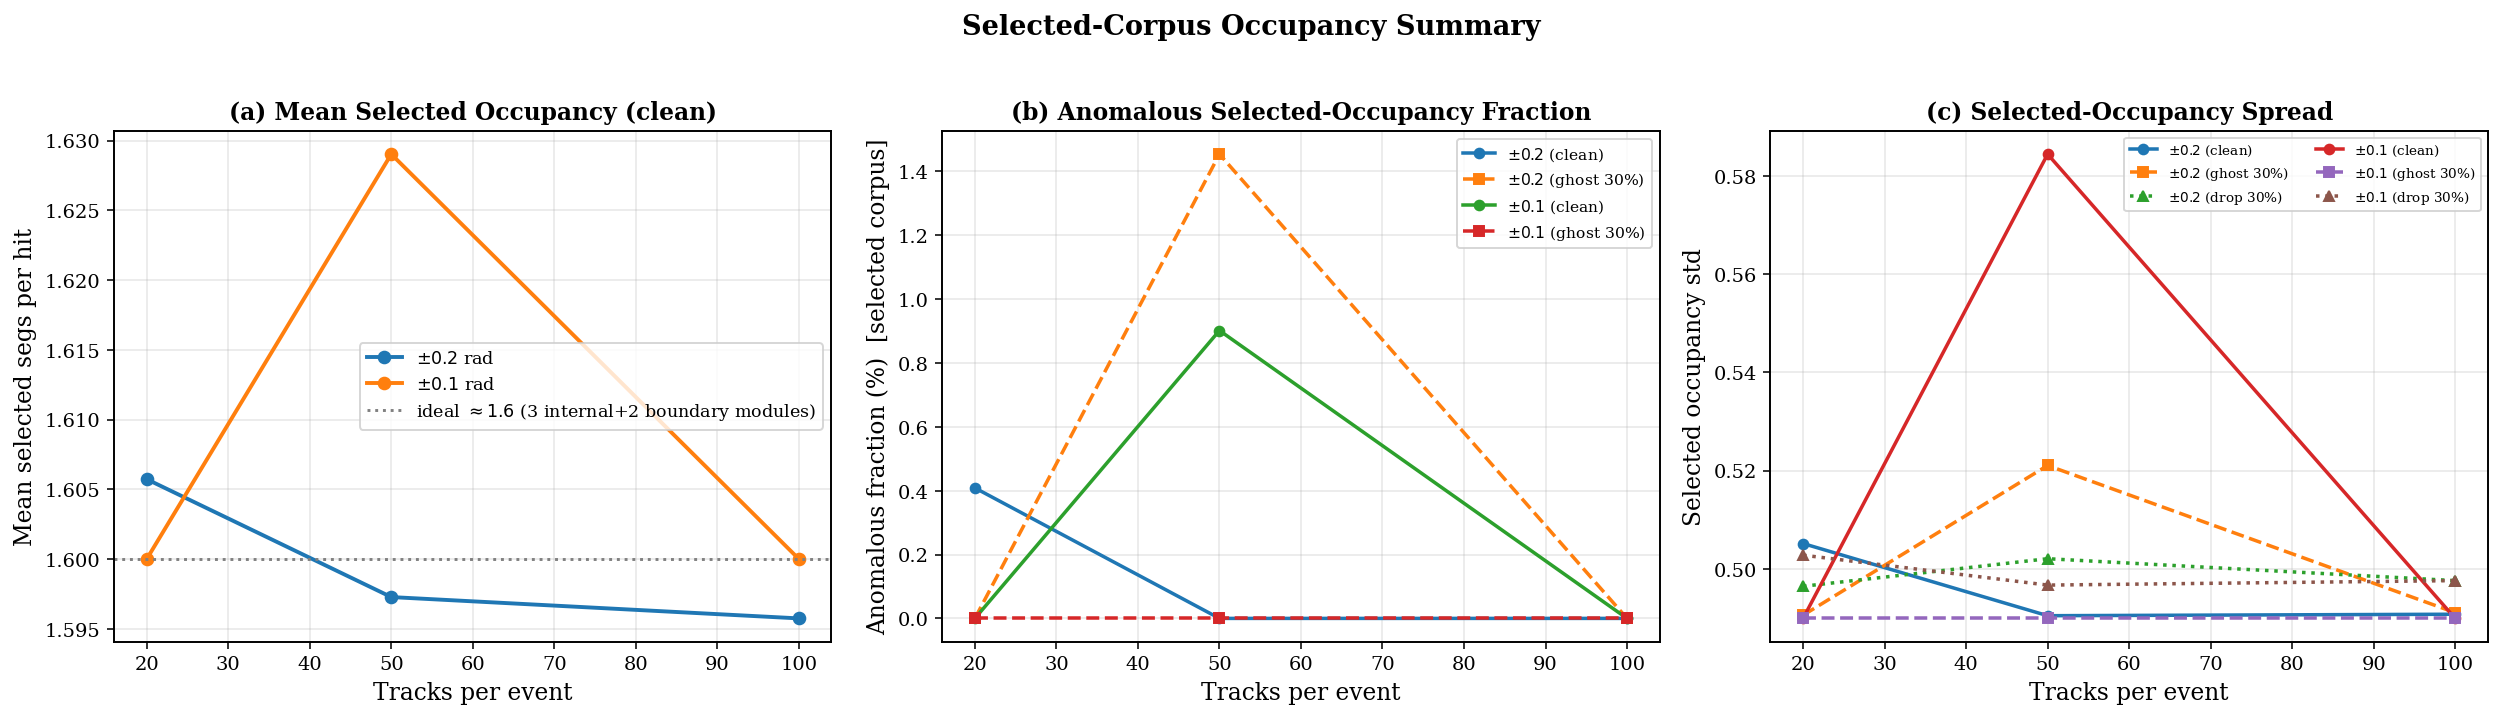

In [14]:
# ── (c) Selected-corpus summary statistics ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Mean selected occupancy vs n_tracks (clean only)
for angle in angles:
    sub = df[(df["angle"] == angle)
             & (df["ghost_rate"] == 0.0)
             & (df["drop_rate"] == 0.0)].sort_values("n_tracks")
    axes[0].plot(sub["n_tracks"], sub["occ_sel_mean"], "o-",
                 label=f"$\\pm{angle}$ rad", markersize=6, lw=2)
axes[0].axhline(1.6, color="gray", ls=":", lw=1.5,
                label="ideal $\\approx 1.6$ (3 internal+2 boundary modules)")
axes[0].set_xlabel("Tracks per event")
axes[0].set_ylabel("Mean selected segs per hit")
axes[0].set_title("(a) Mean Selected Occupancy (clean)", fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Anomalous fraction (selected) vs n_tracks
for angle in angles:
    for gr, ls, label_sfx in [(0.0, "o-", "clean"), (0.30, "s--", "ghost 30%")]:
        sub = df[(df["angle"] == angle)
                 & (df["ghost_rate"] == gr)
                 & (df["drop_rate"] == 0.0)].sort_values("n_tracks")
        axes[1].plot(sub["n_tracks"], sub["frac_anomalous_occ_sel"] * 100,
                     ls, label=f"$\\pm{angle}$ ({label_sfx})",
                     markersize=5, lw=1.8)
axes[1].set_xlabel("Tracks per event")
axes[1].set_ylabel("Anomalous fraction (%)  [selected corpus]")
axes[1].set_title("(b) Anomalous Selected-Occupancy Fraction",
                  fontweight="bold")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Selected occupancy std vs n_tracks
for angle in angles:
    for gr, dr, ls, label_sfx in [(0.0, 0.0, "o-", "clean"),
                                   (0.30, 0.0, "s--", "ghost 30%"),
                                   (0.0, 0.30, "^:", "drop 30%")]:
        sub = df[(df["angle"] == angle)
                 & (df["ghost_rate"] == gr)
                 & (df["drop_rate"] == dr)].sort_values("n_tracks")
        axes[2].plot(sub["n_tracks"], sub["occ_sel_std"], ls,
                     label=f"$\\pm{angle}$ ({label_sfx})",
                     markersize=5, lw=1.8)
axes[2].set_xlabel("Tracks per event")
axes[2].set_ylabel("Selected occupancy std")
axes[2].set_title("(c) Selected-Occupancy Spread", fontweight="bold")
axes[2].legend(fontsize=7, ncol=2)
axes[2].grid(True, alpha=0.3)

plt.suptitle("Selected-Corpus Occupancy Summary",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "occ_sel_summary_comparison")
plt.show()


### 7.1 — Anomalous Selected-Occupancy Fraction Heatmaps

Mirror of Section 1, restricted to the selected corpus.


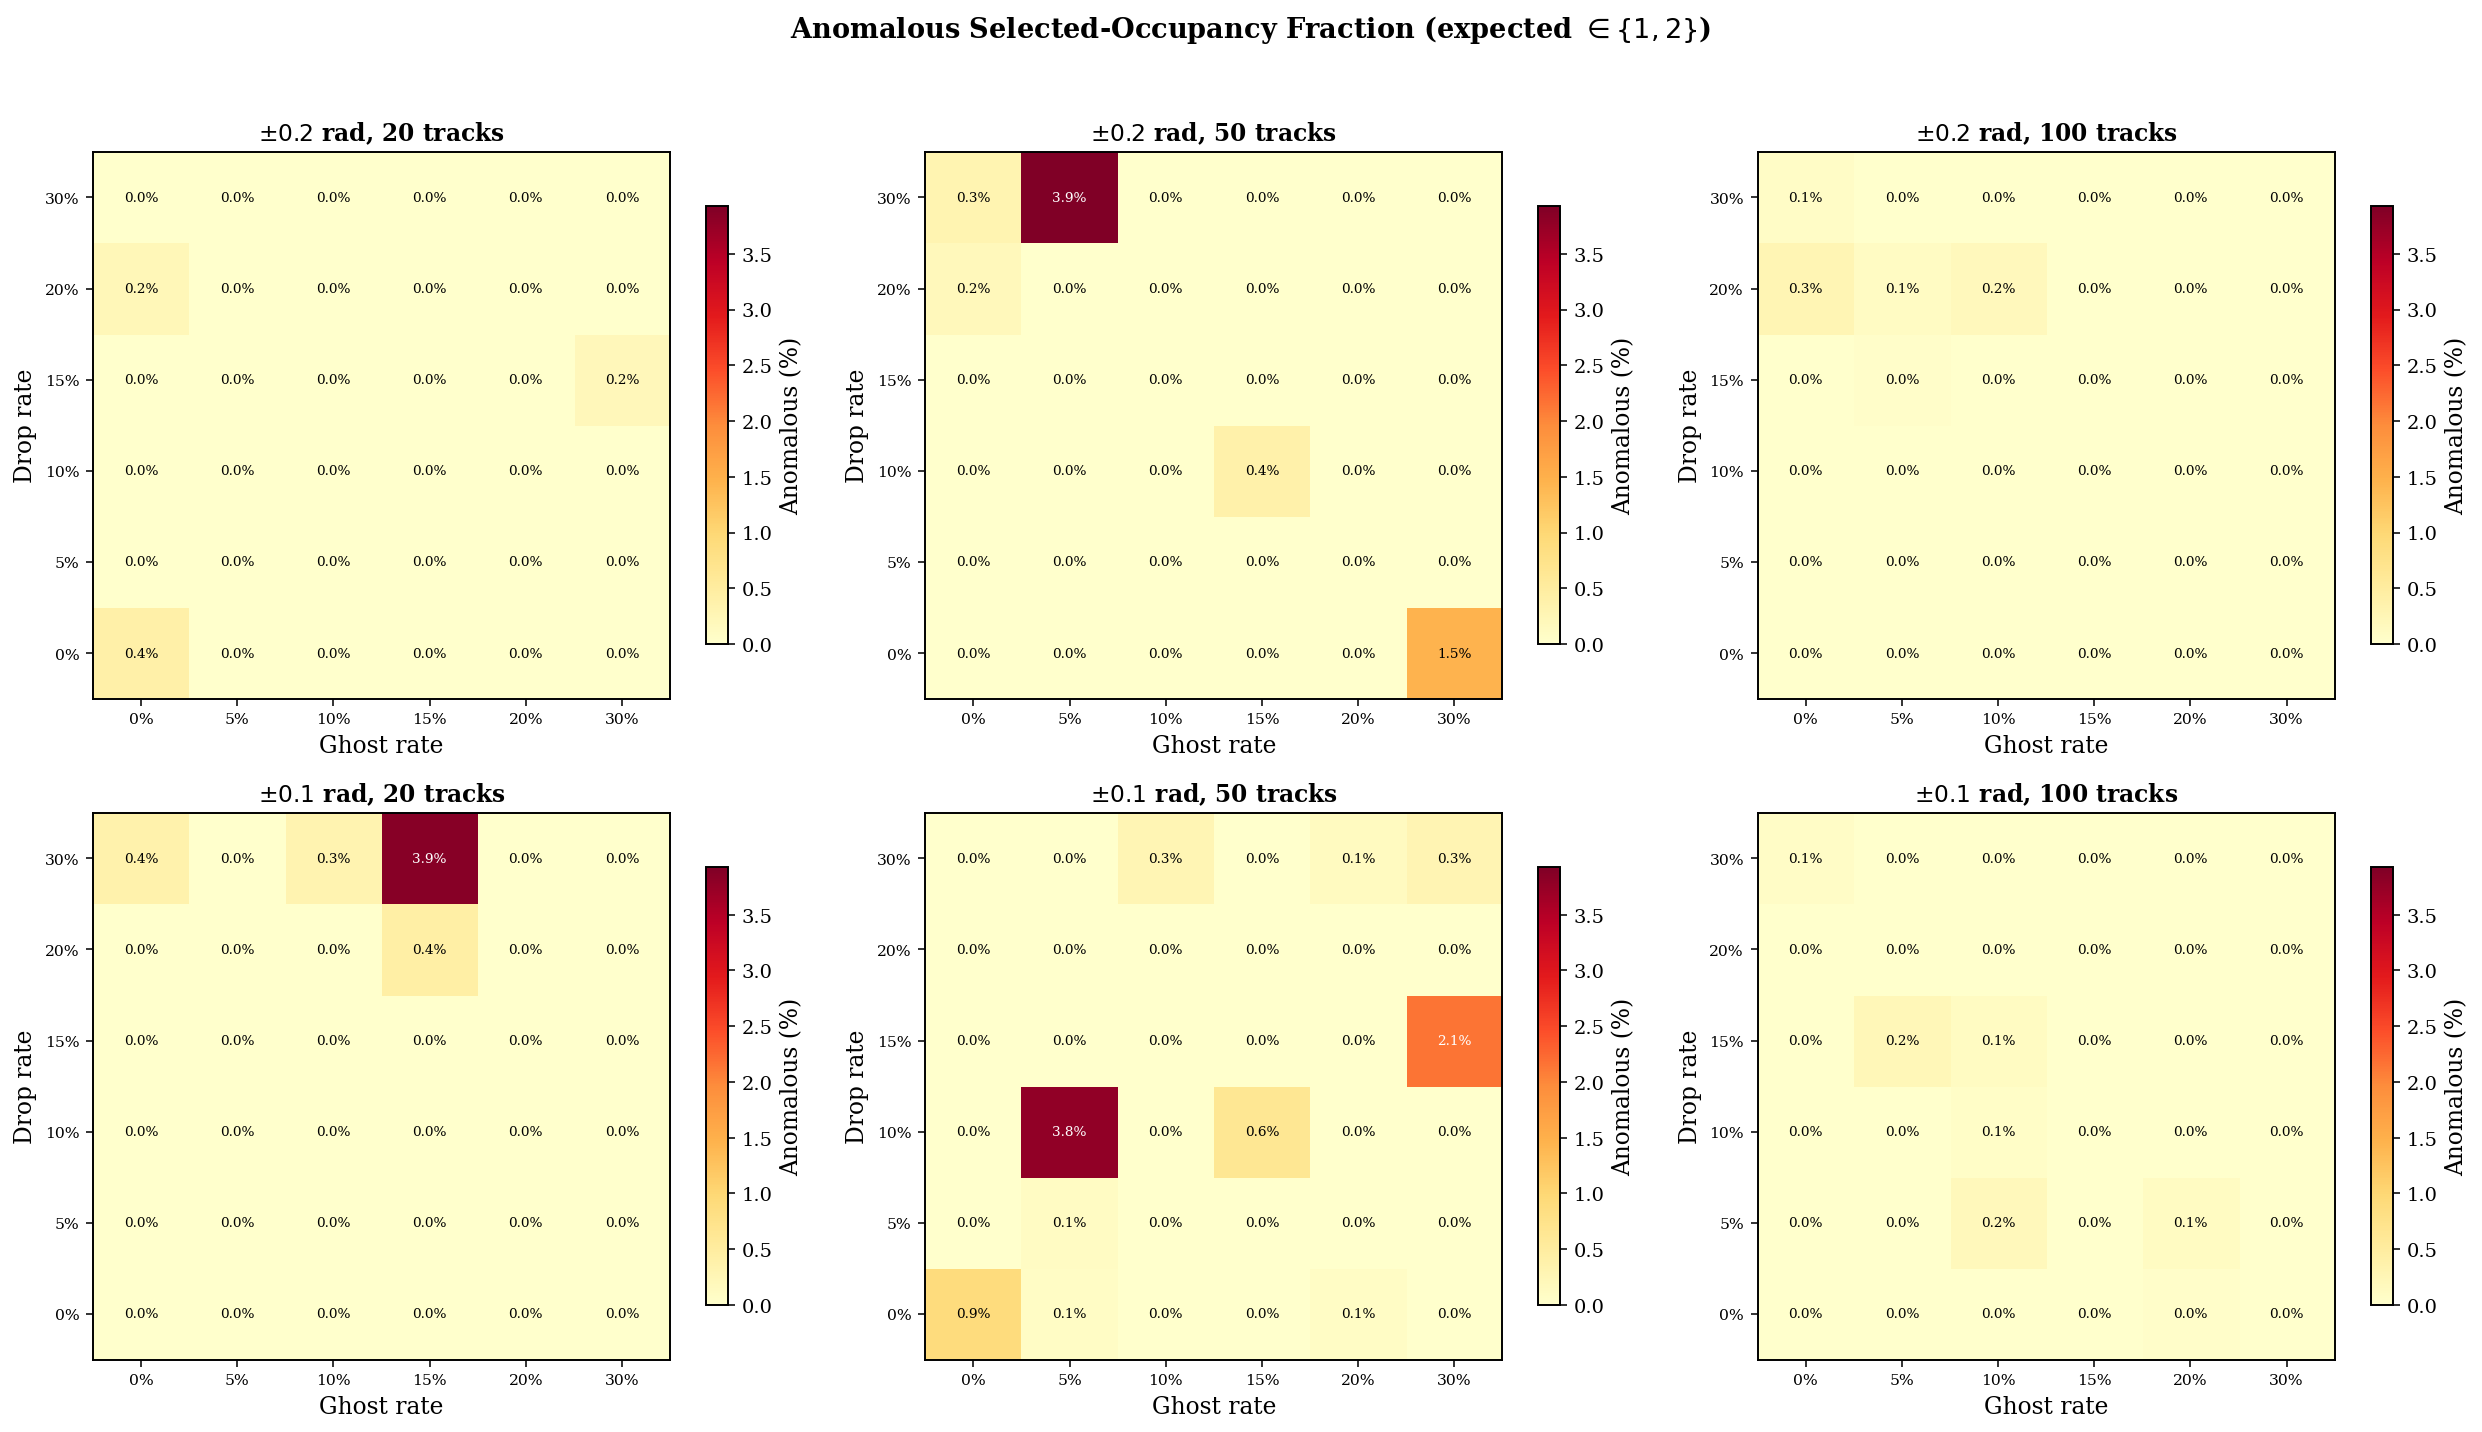

In [15]:
# ── Heatmaps: anomalous selected-occupancy fraction ────────────
fig, axes = plt.subplots(len(angles), len(track_counts),
                         figsize=(6 * len(track_counts),
                                  5 * len(angles)),
                         squeeze=False)

vmax_sel = max(df["frac_anomalous_occ_sel"].max() * 100, 1)

for row, angle in enumerate(angles):
    for col, n_trk in enumerate(track_counts):
        ax = axes[row][col]
        sub = df[(df["angle"] == angle) & (df["n_tracks"] == n_trk)]

        piv = sub.pivot_table(
            index="drop_rate", columns="ghost_rate",
            values="frac_anomalous_occ_sel", aggfunc="first")
        piv = piv.reindex(index=drop_rates, columns=ghost_rates)

        im = ax.imshow(piv.values * 100, aspect="auto",
                       cmap="YlOrRd", origin="lower",
                       vmin=0, vmax=vmax_sel)

        ax.set_xticks(range(len(ghost_rates)))
        ax.set_xticklabels([f"{g:.0%}" for g in ghost_rates], fontsize=8)
        ax.set_yticks(range(len(drop_rates)))
        ax.set_yticklabels([f"{d:.0%}" for d in drop_rates], fontsize=8)
        ax.set_xlabel("Ghost rate")
        ax.set_ylabel("Drop rate")
        ax.set_title(f"$\\pm{angle}$ rad, {n_trk} tracks", fontweight="bold")

        for i in range(len(drop_rates)):
            for j in range(len(ghost_rates)):
                val = piv.values[i, j] * 100
                if not np.isnan(val):
                    color = "white" if val > vmax_sel * 0.5 else "black"
                    ax.text(j, i, f"{val:.1f}%", ha="center", va="center",
                            fontsize=7, color=color)

        plt.colorbar(im, ax=ax, label="Anomalous (%)", shrink=0.8)

plt.suptitle("Anomalous Selected-Occupancy Fraction "
             "(expected $\\in\\{1,2\\}$)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "heatmap_anomalous_occ_sel")
plt.show()


### 7.2 — Selected-Occupancy Spread vs Ghost / Drop Rate

Mirror of Section 2. Spread of the selected corpus directly tells us how much grass survives the activation cut.


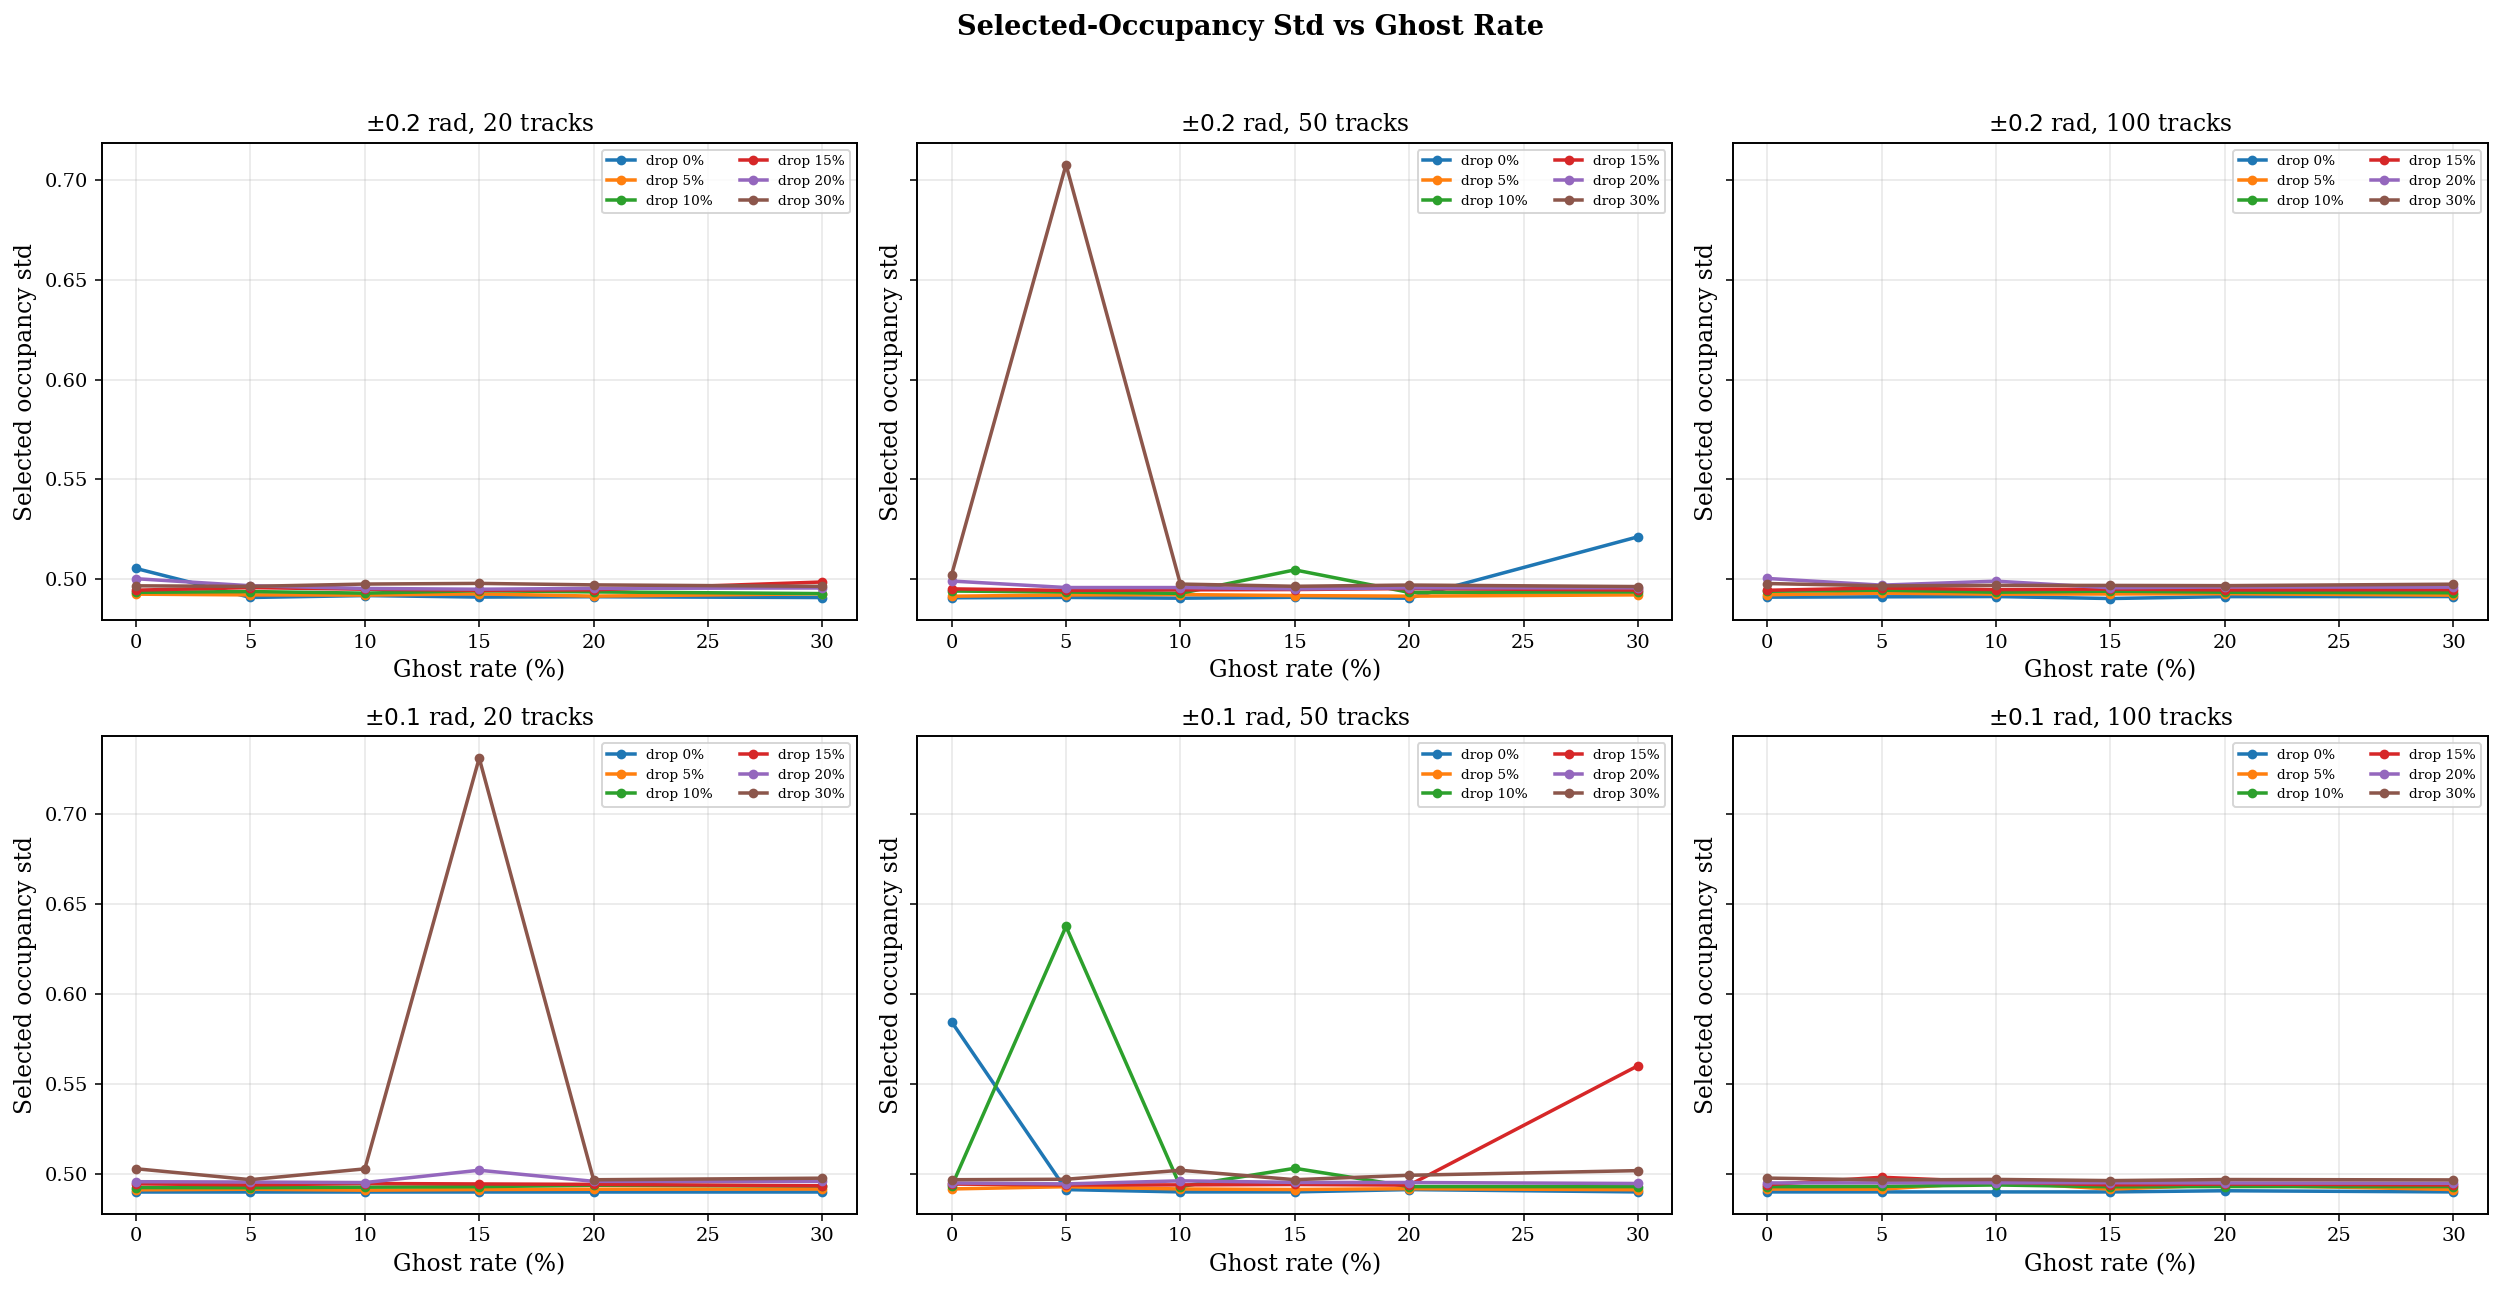

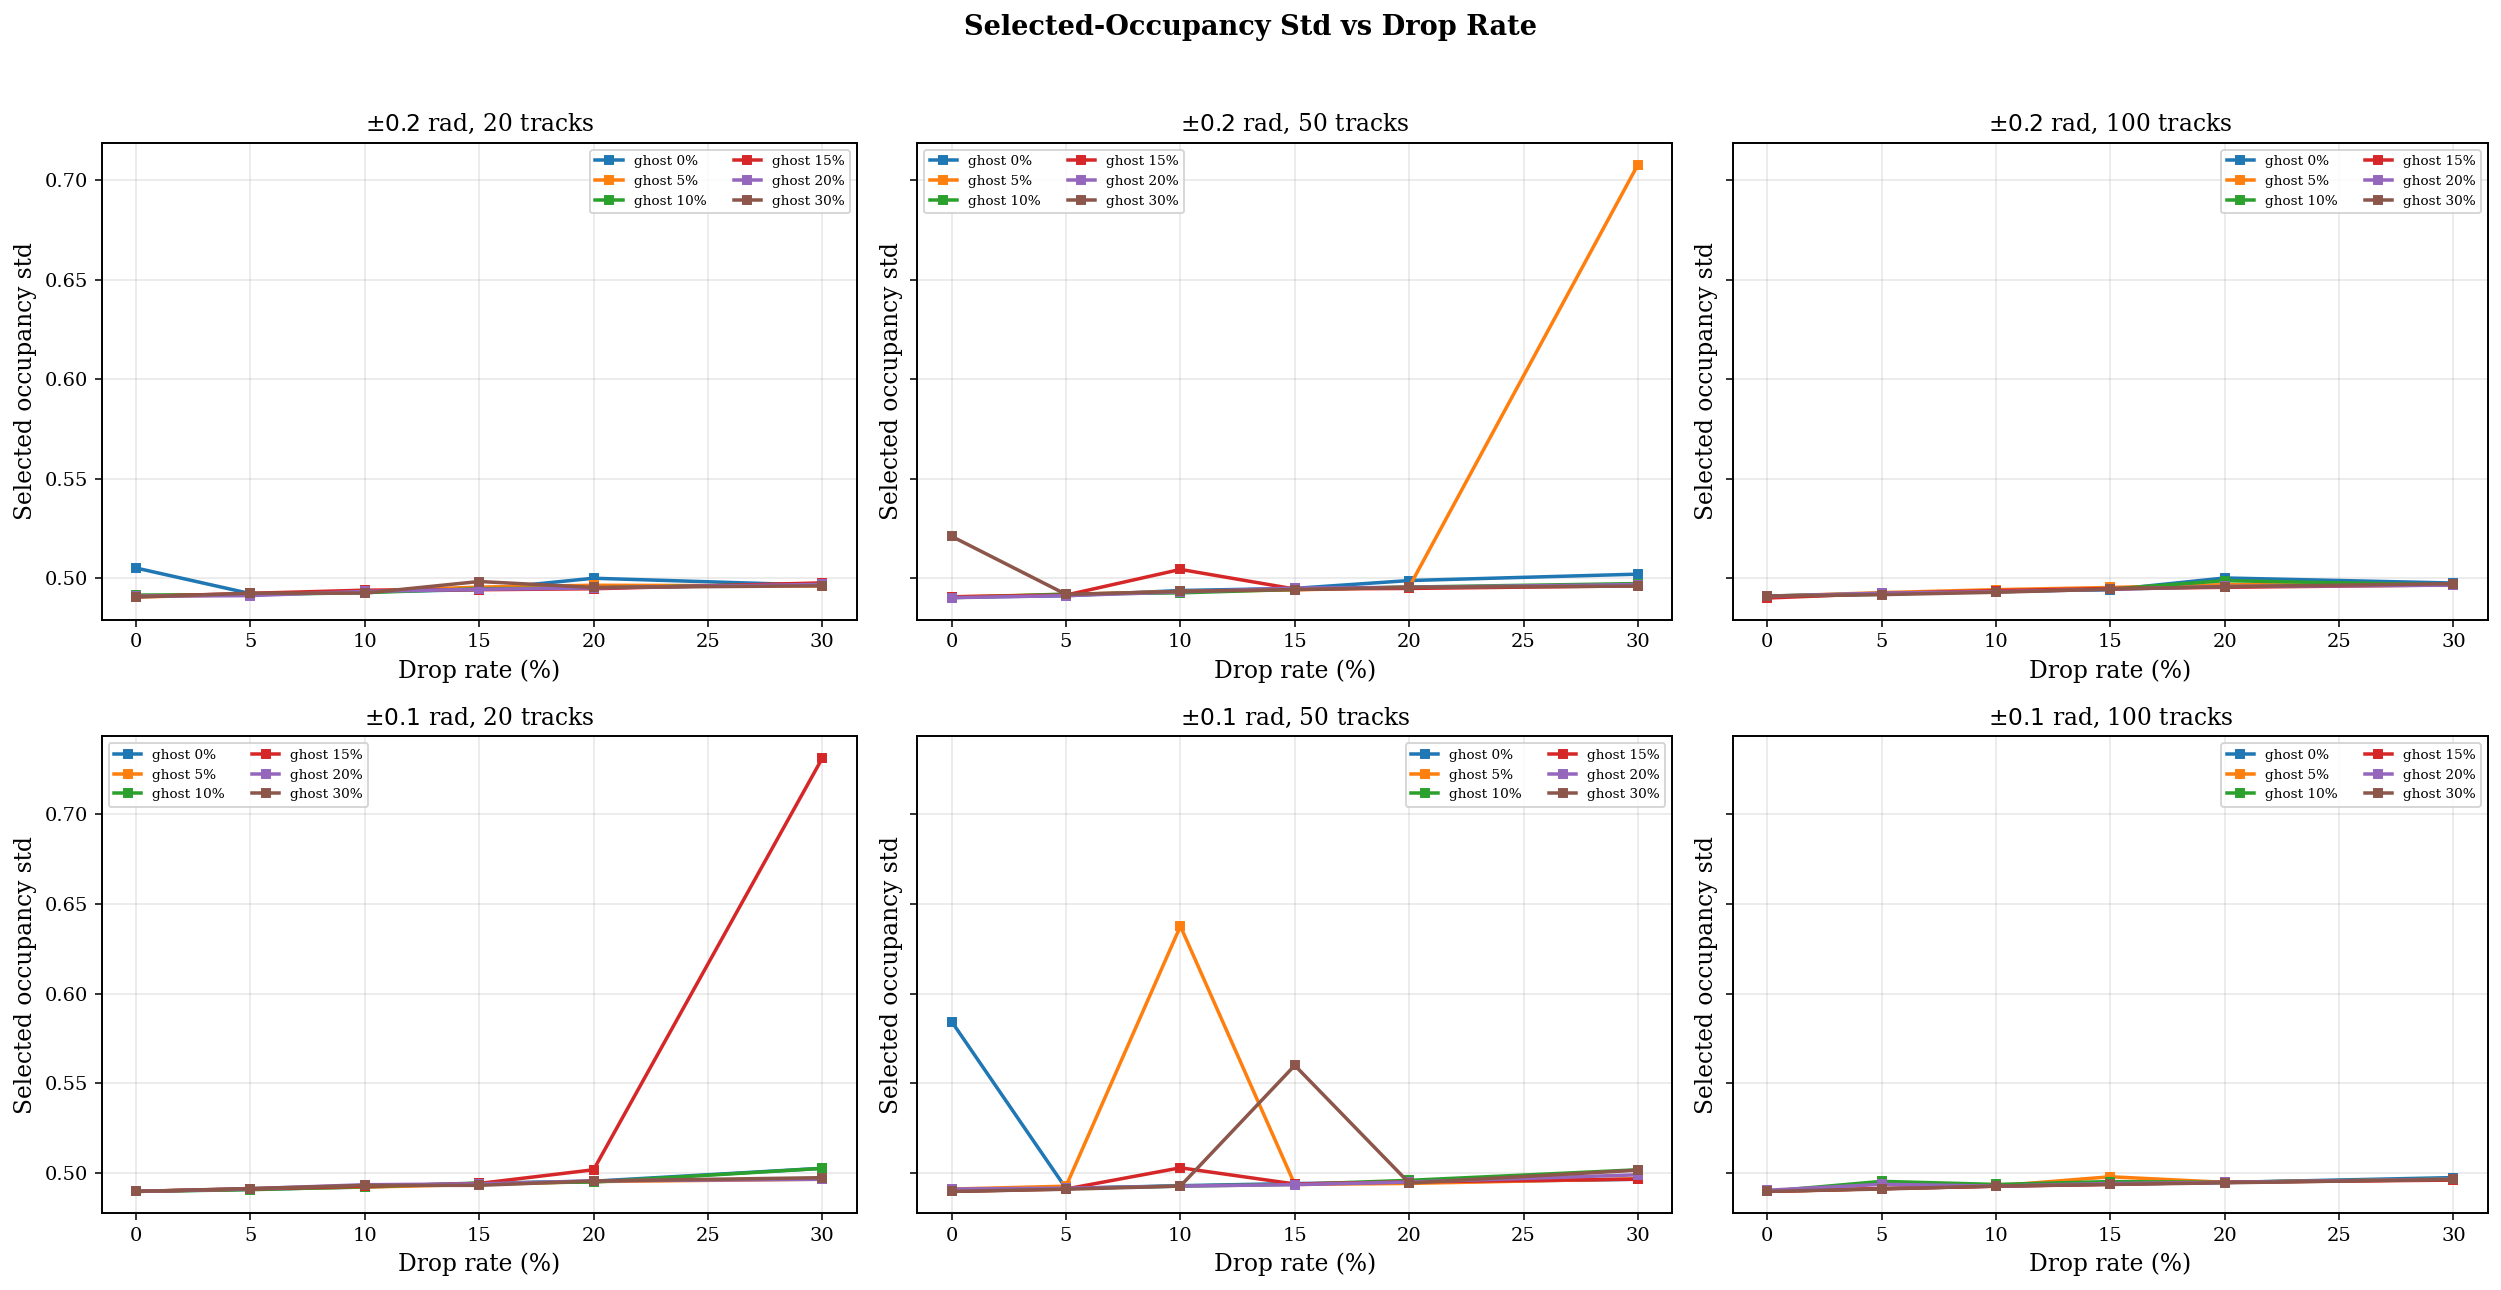

In [16]:
# ── Selected occupancy std vs ghost rate ──────────────────────
fig, axes = plt.subplots(len(angles), len(track_counts),
                         figsize=(6 * len(track_counts),
                                  4.5 * len(angles)),
                         squeeze=False, sharey="row")

for row, angle in enumerate(angles):
    for col, n_trk in enumerate(track_counts):
        ax = axes[row][col]
        sub = df[(df["angle"] == angle) & (df["n_tracks"] == n_trk)]
        for dr in drop_rates:
            curve = sub[sub["drop_rate"] == dr].sort_values("ghost_rate")
            ax.plot(curve["ghost_rate"] * 100, curve["occ_sel_std"],
                    "o-", label=f"drop {dr:.0%}", markersize=4)
        ax.set_xlabel("Ghost rate (%)")
        ax.set_ylabel("Selected occupancy std")
        ax.set_title(f"$\\pm{angle}$ rad, {n_trk} tracks")
        ax.legend(fontsize=7, ncol=2)
        ax.grid(True, alpha=0.3)

plt.suptitle("Selected-Occupancy Std vs Ghost Rate",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "occ_sel_std_vs_ghost")
plt.show()

# ── Selected occupancy std vs drop rate ───────────────────────
fig, axes = plt.subplots(len(angles), len(track_counts),
                         figsize=(6 * len(track_counts),
                                  4.5 * len(angles)),
                         squeeze=False, sharey="row")

for row, angle in enumerate(angles):
    for col, n_trk in enumerate(track_counts):
        ax = axes[row][col]
        sub = df[(df["angle"] == angle) & (df["n_tracks"] == n_trk)]
        for gr in ghost_rates:
            curve = sub[sub["ghost_rate"] == gr].sort_values("drop_rate")
            ax.plot(curve["drop_rate"] * 100, curve["occ_sel_std"],
                    "s-", label=f"ghost {gr:.0%}", markersize=4)
        ax.set_xlabel("Drop rate (%)")
        ax.set_ylabel("Selected occupancy std")
        ax.set_title(f"$\\pm{angle}$ rad, {n_trk} tracks")
        ax.legend(fontsize=7, ncol=2)
        ax.grid(True, alpha=0.3)

plt.suptitle("Selected-Occupancy Std vs Drop Rate",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "occ_sel_std_vs_drop")
plt.show()


### 7.3 — Hits-per-Module CoV (Selected Corpus)

A hit belongs to the selected corpus iff at least one selected segment touches it. We compute the per-module count of such hits, then the coefficient of variation across modules. The selected corpus rejects most ghost-only hits, so this CoV is a cleaner geometric-clipping fingerprint.


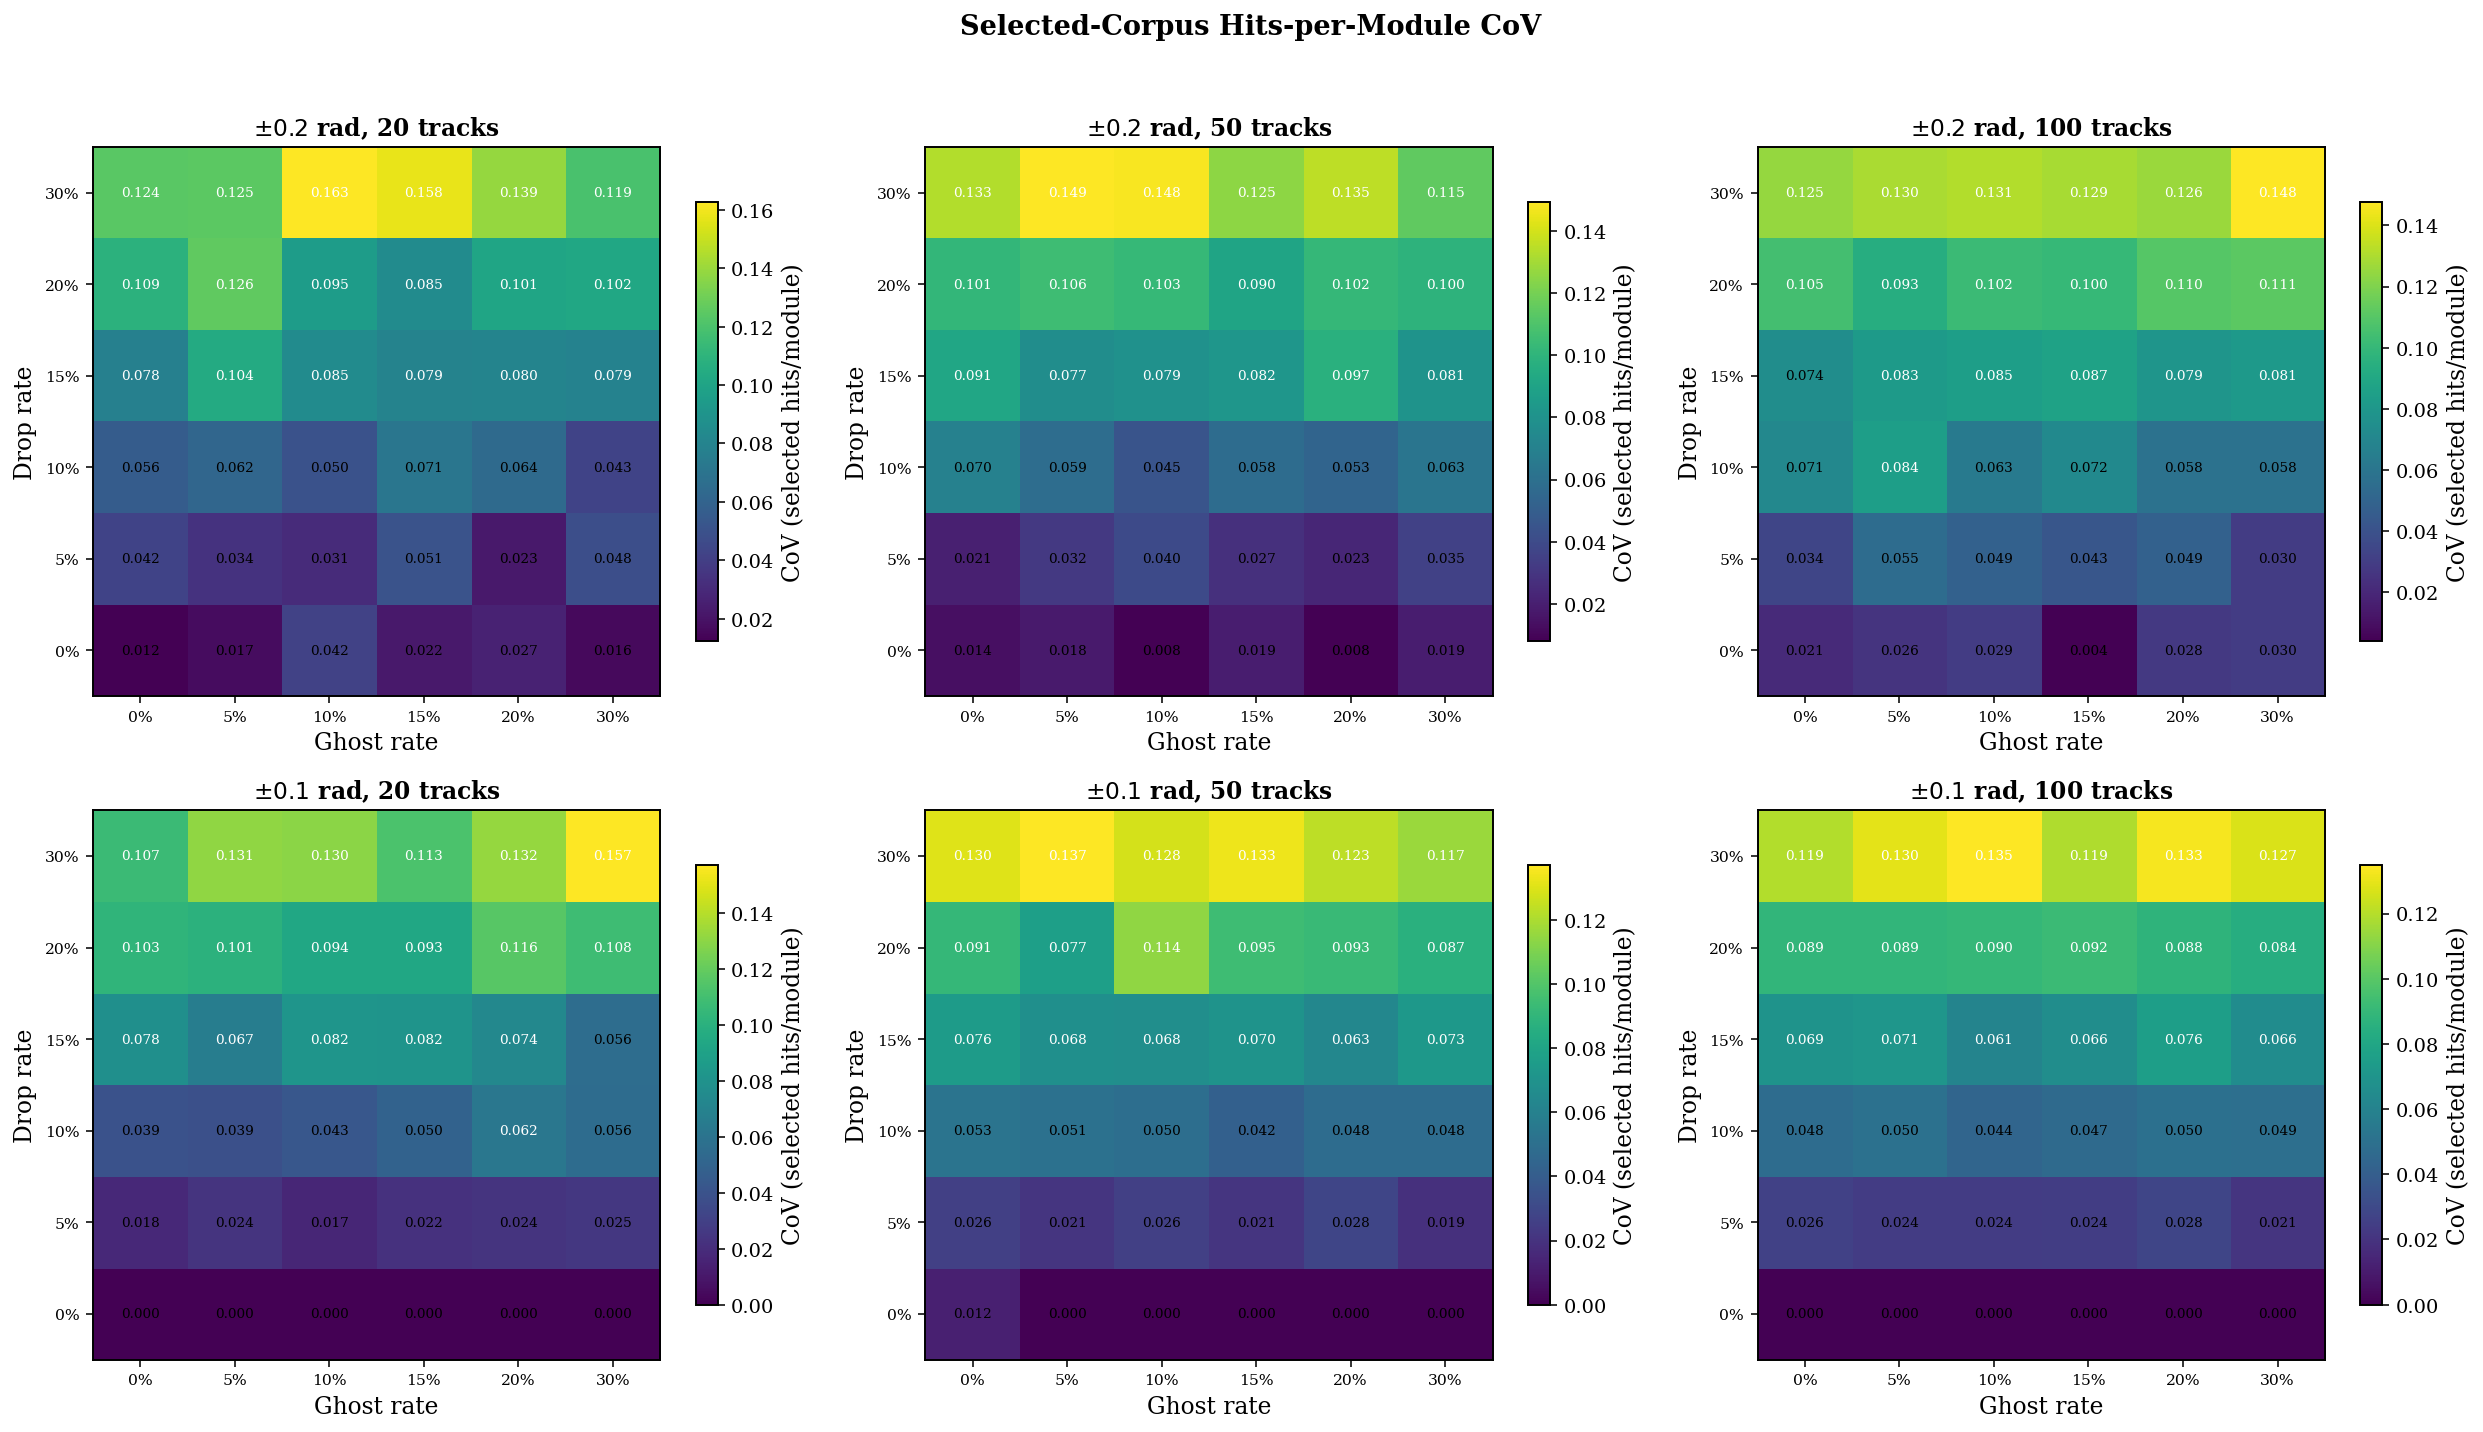

In [17]:
# ── Hits-per-module CoV in selected corpus ─────────────────────
mod_sel_cols = [f"hits_sel_mod{m}_mean" for m in range(5)]
available_sel_cols = [c for c in mod_sel_cols if c in df.columns]

if len(available_sel_cols) >= 2:
    mod_sel_arr = df[available_sel_cols].values
    df["hits_sel_per_module_cv"] = (
        np.std(mod_sel_arr, axis=1)
        / np.clip(np.mean(mod_sel_arr, axis=1), 1e-9, None)
    )

    fig, axes = plt.subplots(len(angles), len(track_counts),
                             figsize=(6 * len(track_counts),
                                      5 * len(angles)),
                             squeeze=False)

    for row, angle in enumerate(angles):
        for col, n_trk in enumerate(track_counts):
            ax = axes[row][col]
            sub = df[(df["angle"] == angle) & (df["n_tracks"] == n_trk)]

            piv = sub.pivot_table(
                index="drop_rate", columns="ghost_rate",
                values="hits_sel_per_module_cv", aggfunc="first")
            piv = piv.reindex(index=drop_rates, columns=ghost_rates)

            im = ax.imshow(piv.values, aspect="auto",
                           cmap="viridis", origin="lower")

            ax.set_xticks(range(len(ghost_rates)))
            ax.set_xticklabels([f"{g:.0%}" for g in ghost_rates], fontsize=8)
            ax.set_yticks(range(len(drop_rates)))
            ax.set_yticklabels([f"{d:.0%}" for d in drop_rates], fontsize=8)
            ax.set_xlabel("Ghost rate")
            ax.set_ylabel("Drop rate")
            ax.set_title(f"$\\pm{angle}$ rad, {n_trk} tracks", fontweight="bold")

            mean_val = piv.values[~np.isnan(piv.values)].mean()
            for i in range(len(drop_rates)):
                for j in range(len(ghost_rates)):
                    val = piv.values[i, j]
                    if not np.isnan(val):
                        color = "white" if val > mean_val else "black"
                        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                                fontsize=7, color=color)

            plt.colorbar(im, ax=ax,
                         label="CoV (selected hits/module)", shrink=0.8)

    plt.suptitle("Selected-Corpus Hits-per-Module CoV",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    save_fig(fig, "heatmap_hits_sel_module_cv")
    plt.show()
else:
    print("Per-module selected hit columns not found in data — skipping.")


### 7.4 — Selected Segment Count

Mean number of segments surviving the activation cut. Ideal value $\approx 4 n_\text{tracks}$ (4 segments per fully-recovered track in a 5-module geometry).


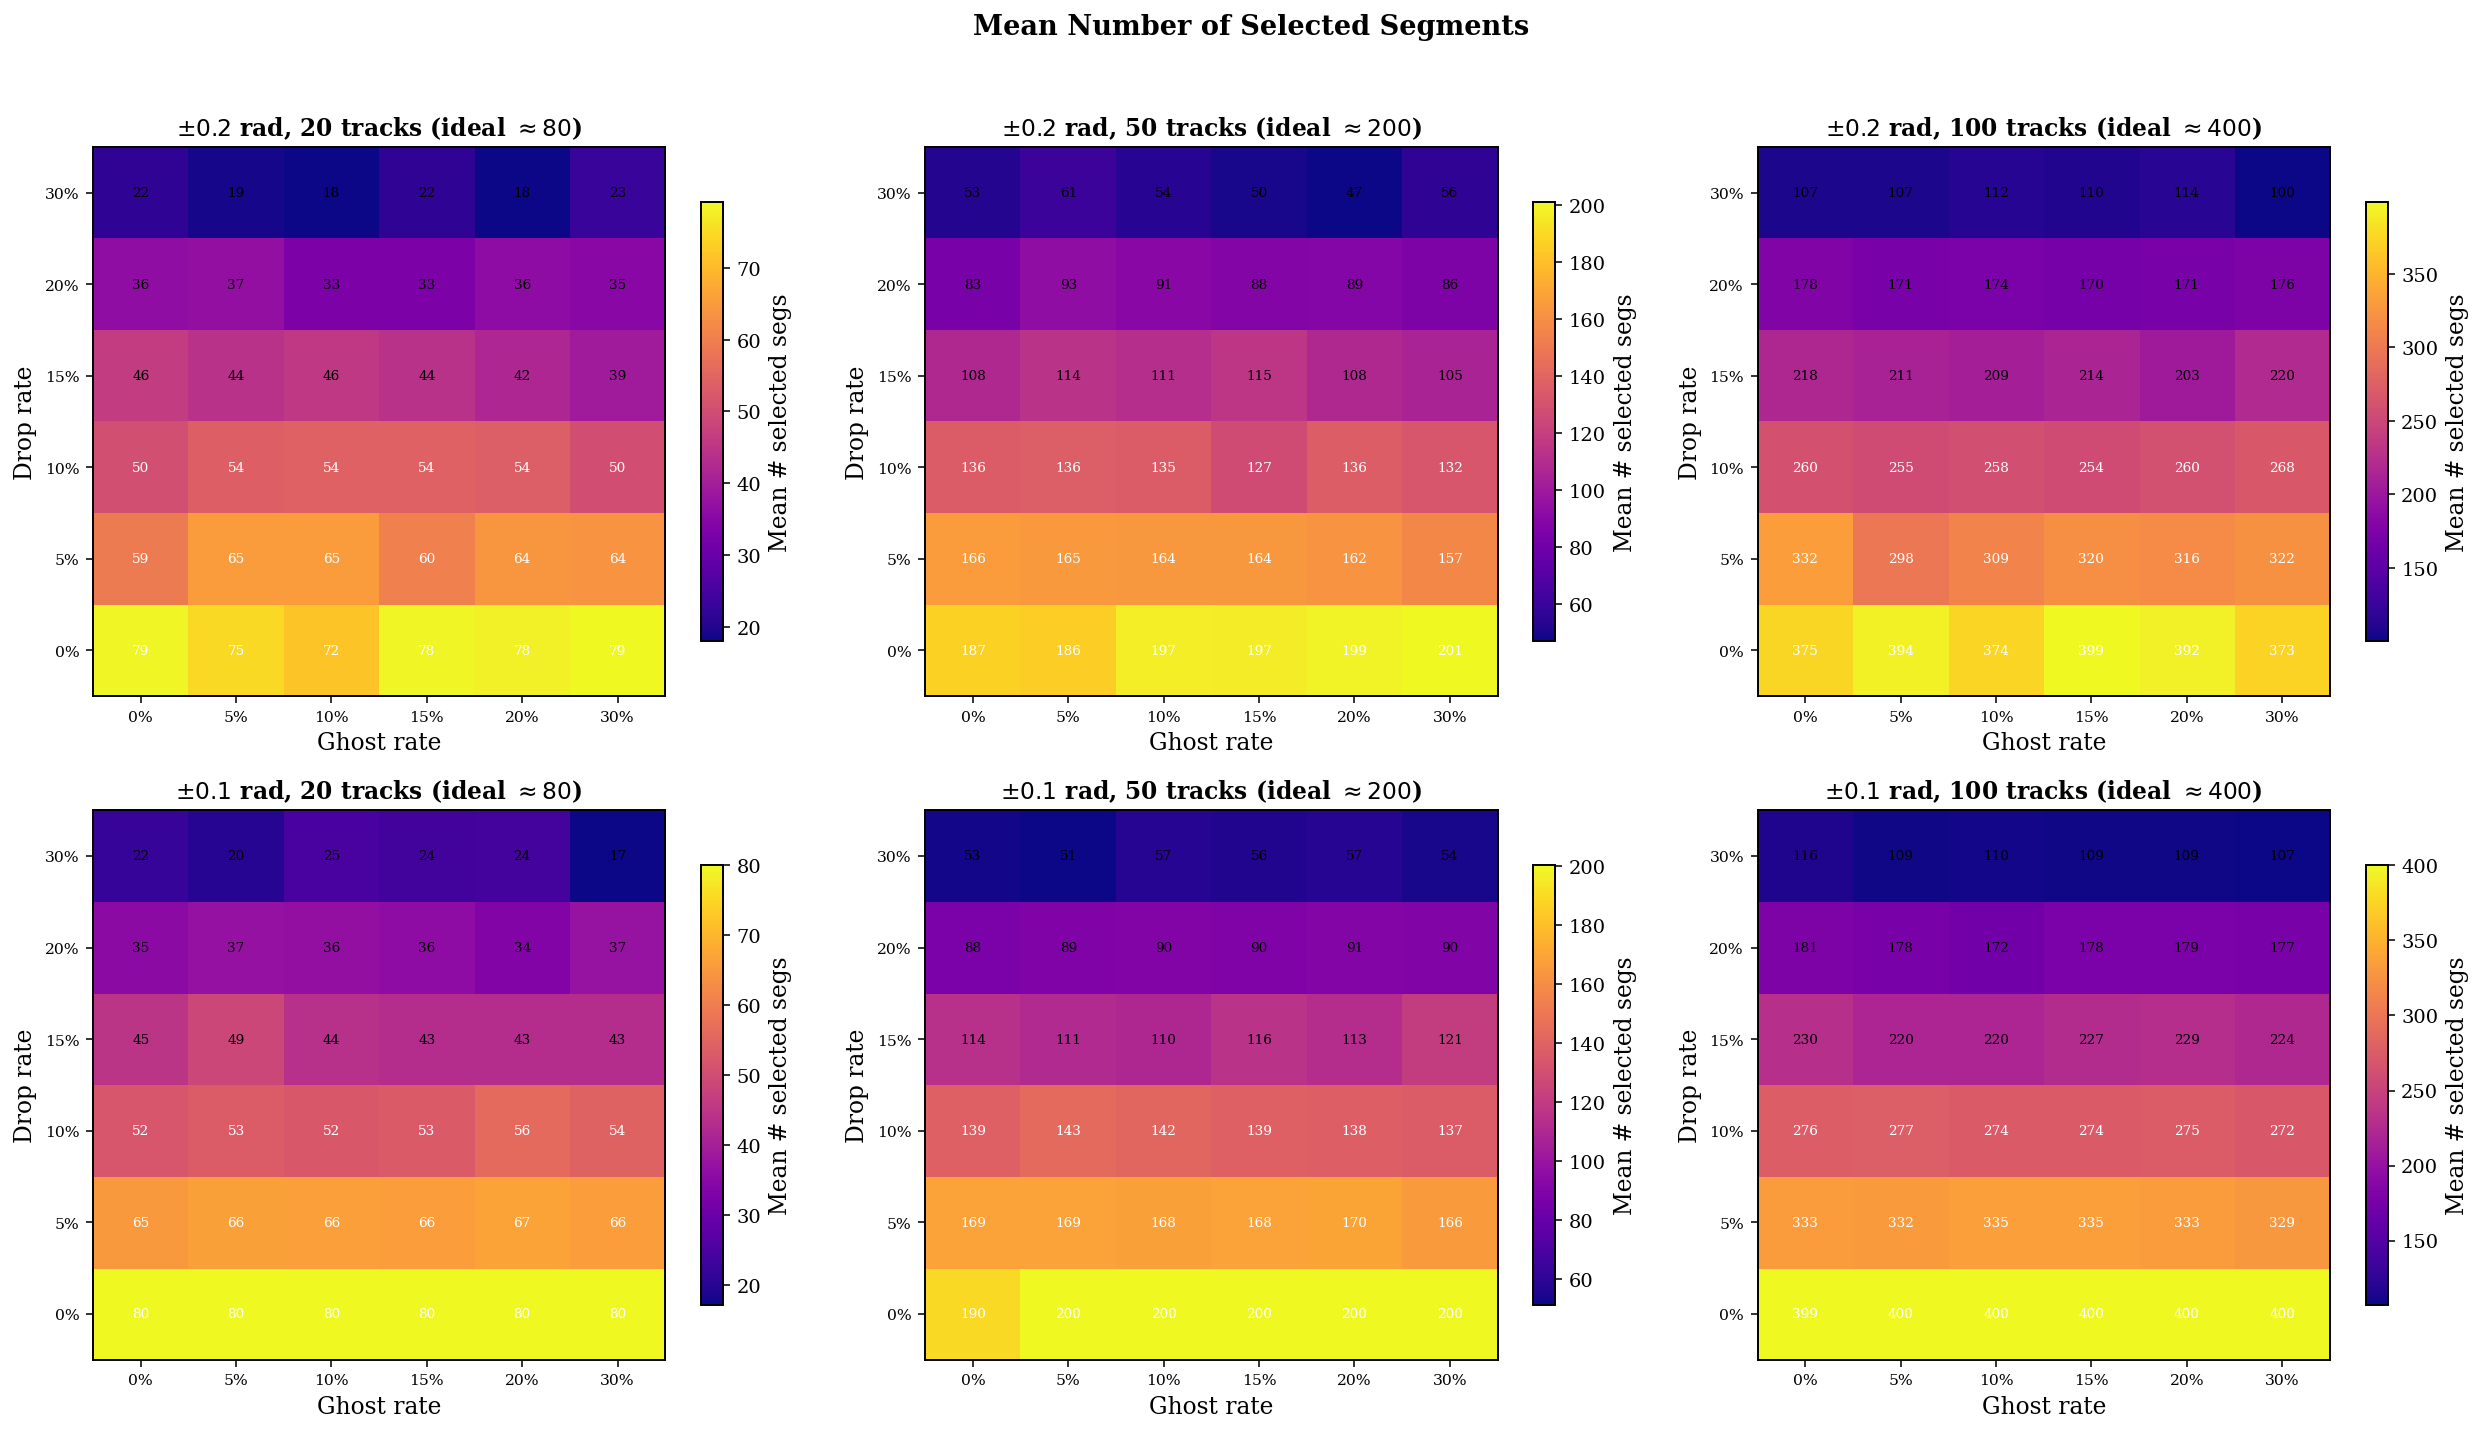

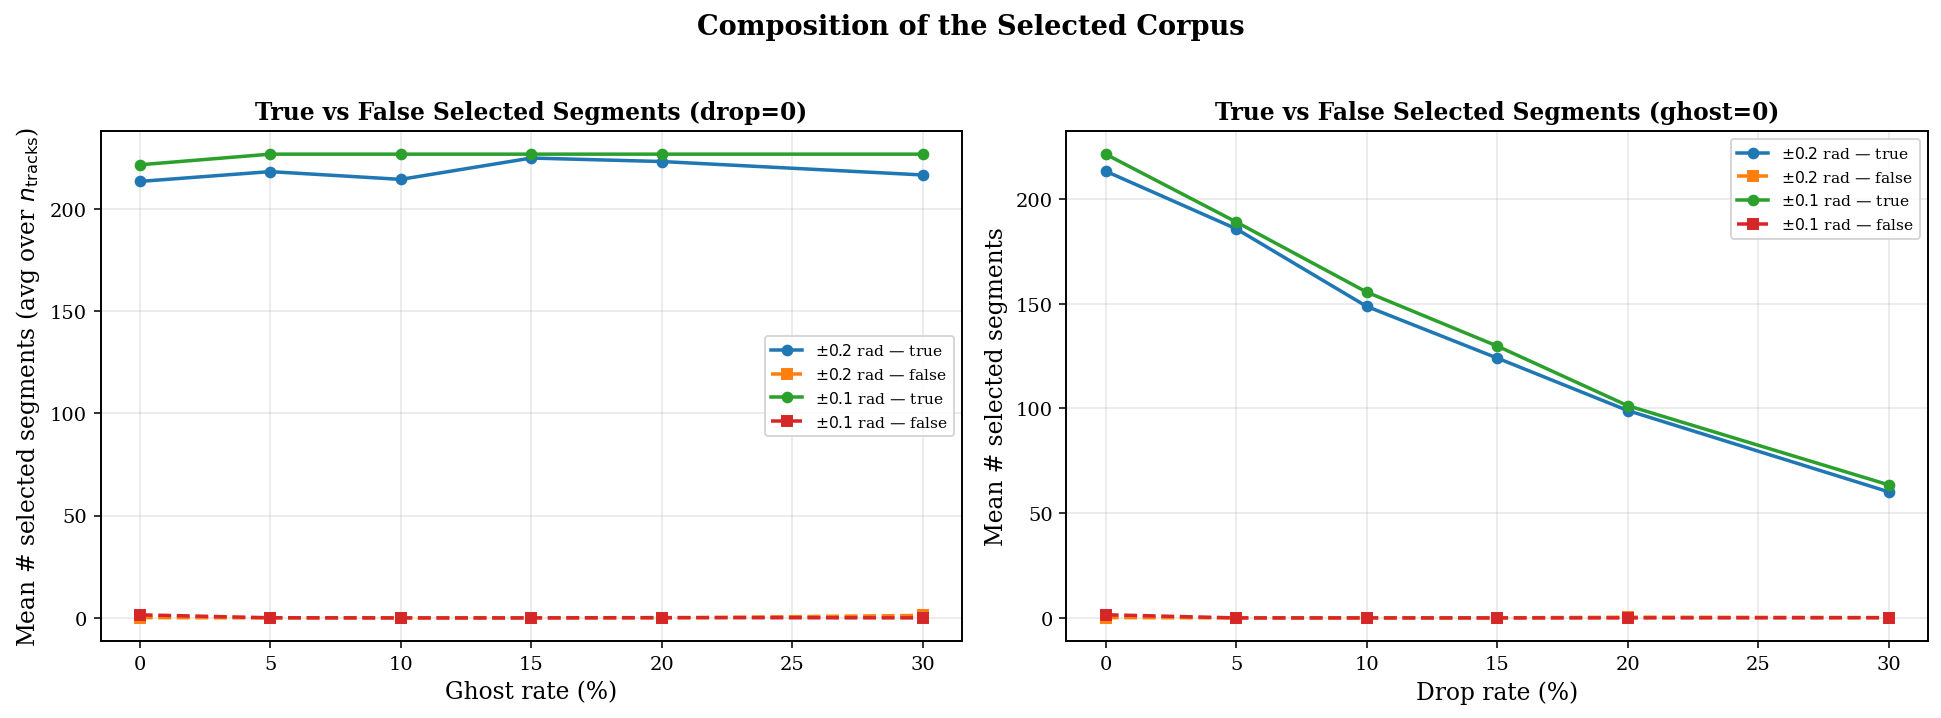

In [18]:
# ── Mean selected-segment count heatmaps ───────────────────────
fig, axes = plt.subplots(len(angles), len(track_counts),
                         figsize=(6 * len(track_counts),
                                  5 * len(angles)),
                         squeeze=False)

for row, angle in enumerate(angles):
    for col, n_trk in enumerate(track_counts):
        ax = axes[row][col]
        sub = df[(df["angle"] == angle) & (df["n_tracks"] == n_trk)]

        piv = sub.pivot_table(
            index="drop_rate", columns="ghost_rate",
            values="mean_n_segments_sel", aggfunc="first")
        piv = piv.reindex(index=drop_rates, columns=ghost_rates)

        im = ax.imshow(piv.values, aspect="auto",
                       cmap="plasma", origin="lower")

        ax.set_xticks(range(len(ghost_rates)))
        ax.set_xticklabels([f"{g:.0%}" for g in ghost_rates], fontsize=8)
        ax.set_yticks(range(len(drop_rates)))
        ax.set_yticklabels([f"{d:.0%}" for d in drop_rates], fontsize=8)
        ax.set_xlabel("Ghost rate")
        ax.set_ylabel("Drop rate")
        ax.set_title(f"$\\pm{angle}$ rad, {n_trk} tracks "
                     f"(ideal $\\approx {4*n_trk}$)",
                     fontweight="bold")

        mean_val = piv.values[~np.isnan(piv.values)].mean()
        for i in range(len(drop_rates)):
            for j in range(len(ghost_rates)):
                val = piv.values[i, j]
                if not np.isnan(val):
                    color = "white" if val > mean_val else "black"
                    ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                            fontsize=7, color=color)

        plt.colorbar(im, ax=ax, label="Mean # selected segs", shrink=0.8)

plt.suptitle("Mean Number of Selected Segments",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "heatmap_n_segments_sel")
plt.show()


# ── Breakdown: true vs false among selected ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for angle in angles:
    sub = df[(df["angle"] == angle) & (df["drop_rate"] == 0.0)]
    sub = sub.groupby("ghost_rate", as_index=False)[
        ["mean_n_true_sel", "mean_n_false_sel"]].mean()
    axes[0].plot(sub["ghost_rate"] * 100, sub["mean_n_true_sel"],
                 "o-", label=f"$\\pm{angle}$ rad — true",
                 markersize=5)
    axes[0].plot(sub["ghost_rate"] * 100, sub["mean_n_false_sel"],
                 "s--", label=f"$\\pm{angle}$ rad — false",
                 markersize=5)
axes[0].set_xlabel("Ghost rate (%)")
axes[0].set_ylabel("Mean # selected segments (avg over $n_\\text{tracks}$)")
axes[0].set_title("True vs False Selected Segments (drop=0)",
                  fontweight="bold")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

for angle in angles:
    sub = df[(df["angle"] == angle) & (df["ghost_rate"] == 0.0)]
    sub = sub.groupby("drop_rate", as_index=False)[
        ["mean_n_true_sel", "mean_n_false_sel"]].mean()
    axes[1].plot(sub["drop_rate"] * 100, sub["mean_n_true_sel"],
                 "o-", label=f"$\\pm{angle}$ rad — true",
                 markersize=5)
    axes[1].plot(sub["drop_rate"] * 100, sub["mean_n_false_sel"],
                 "s--", label=f"$\\pm{angle}$ rad — false",
                 markersize=5)
axes[1].set_xlabel("Drop rate (%)")
axes[1].set_ylabel("Mean # selected segments")
axes[1].set_title("True vs False Selected Segments (ghost=0)",
                  fontweight="bold")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Composition of the Selected Corpus",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "selected_true_false_breakdown")
plt.show()


### 7.5 — Activation Spectrum within the Selected Corpus

By construction every selected segment has $x_i > $ THRESHOLD, so the *mean* activation here is bounded below; what matters is whether the false-positive selections (false segments above threshold) shift this distribution.


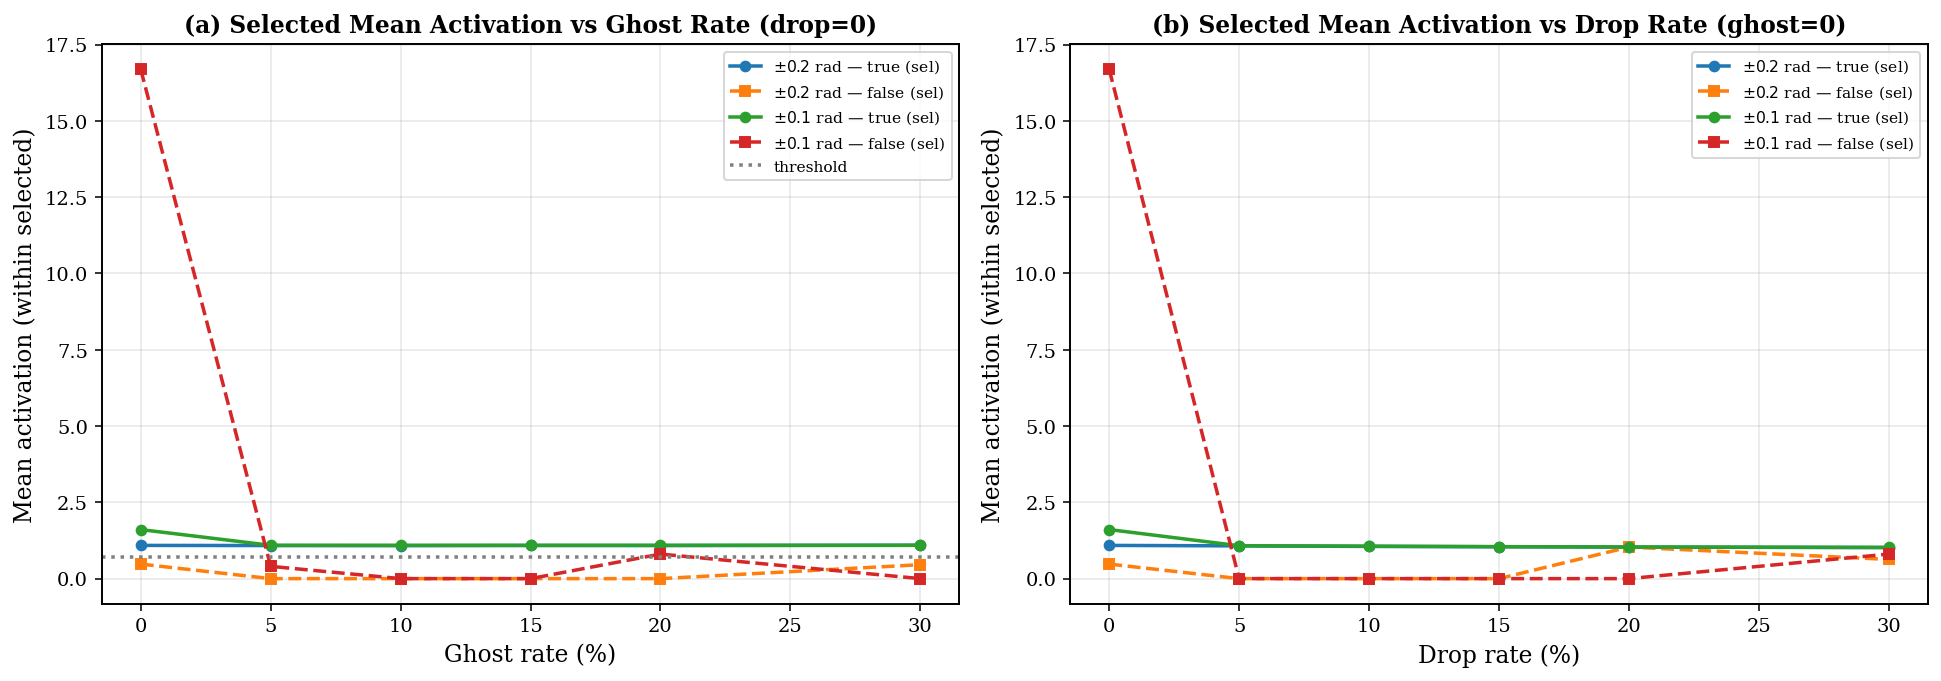

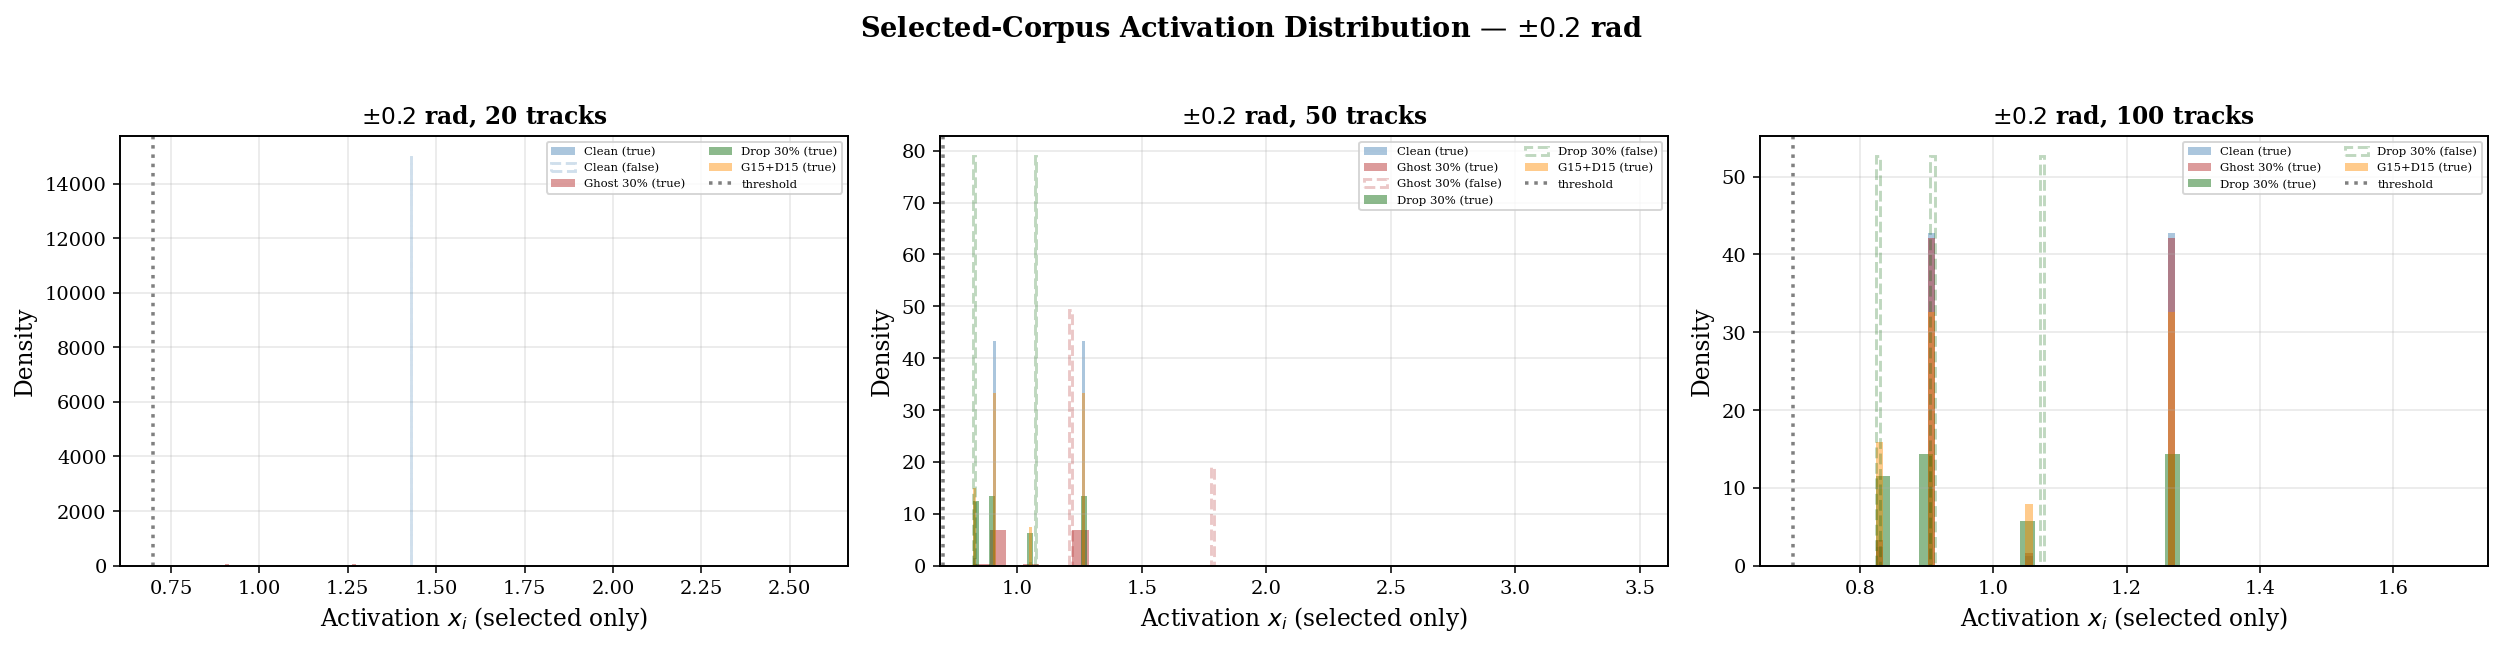

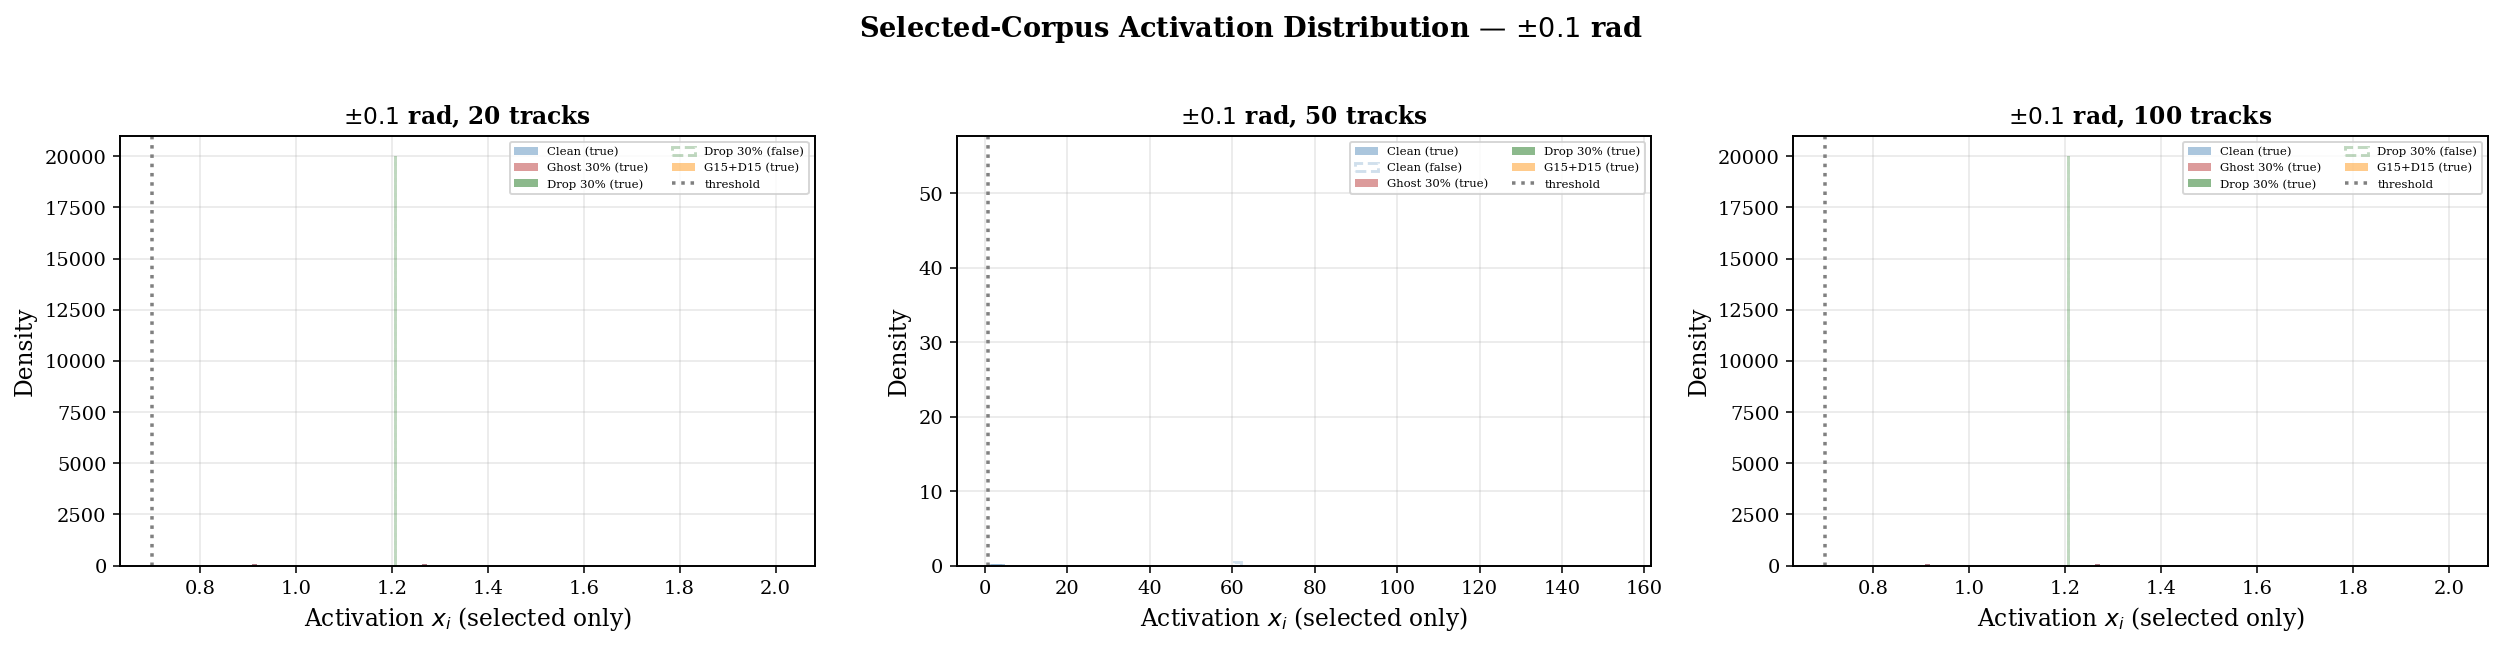

In [19]:
# ── Mean activation in the selected corpus ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for angle in angles:
    sub = df[(df["angle"] == angle) & (df["drop_rate"] == 0.0)]
    sub = sub.sort_values("ghost_rate").groupby("ghost_rate",
        as_index=False)[["mean_true_activation_sel",
                         "mean_false_activation_sel"]].mean()
    axes[0].plot(sub["ghost_rate"] * 100, sub["mean_true_activation_sel"],
                 "o-", label=f"$\\pm{angle}$ rad — true (sel)",
                 markersize=5)
    axes[0].plot(sub["ghost_rate"] * 100, sub["mean_false_activation_sel"],
                 "s--", label=f"$\\pm{angle}$ rad — false (sel)",
                 markersize=5)
axes[0].axhline(THRESHOLD if 'THRESHOLD' in globals() else 0.7,
                color="gray", ls=":", label="threshold")
axes[0].set_xlabel("Ghost rate (%)")
axes[0].set_ylabel("Mean activation (within selected)")
axes[0].set_title("(a) Selected Mean Activation vs Ghost Rate (drop=0)",
                  fontweight="bold")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

for angle in angles:
    sub = df[(df["angle"] == angle) & (df["ghost_rate"] == 0.0)]
    sub = sub.sort_values("drop_rate").groupby("drop_rate",
        as_index=False)[["mean_true_activation_sel",
                         "mean_false_activation_sel"]].mean()
    axes[1].plot(sub["drop_rate"] * 100, sub["mean_true_activation_sel"],
                 "o-", label=f"$\\pm{angle}$ rad — true (sel)",
                 markersize=5)
    axes[1].plot(sub["drop_rate"] * 100, sub["mean_false_activation_sel"],
                 "s--", label=f"$\\pm{angle}$ rad — false (sel)",
                 markersize=5)
axes[1].set_xlabel("Drop rate (%)")
axes[1].set_ylabel("Mean activation (within selected)")
axes[1].set_title("(b) Selected Mean Activation vs Drop Rate (ghost=0)",
                  fontweight="bold")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, "selected_activation_spectrum")
plt.show()


# ── Raw activation histograms (selected corpus) for clean vs noisy
def load_xsel(angle, n_tracks, ghost_rate, drop_rate):
    params_dir = RESULTS_DIR / "params"
    for pf in sorted(params_dir.glob("job_*.json")):
        with open(pf) as f:
            p = json.load(f)
        if (p["angle"] == angle and p["n_tracks"] == n_tracks
                and p["ghost_rate"] == ghost_rate
                and p["drop_rate"] == drop_rate):
            npz = RESULTS_DIR / pf.stem / "arrays.npz"
            if npz.exists():
                d = np.load(npz)
                return (d["true_x_sel"] if "true_x_sel" in d.files else None,
                        d["false_x_sel"] if "false_x_sel" in d.files else None)
    return None, None


for angle in angles:
    fig, axes_row = plt.subplots(1, len(track_counts),
                                 figsize=(6 * len(track_counts), 4.5),
                                 squeeze=False)
    for col, n_trk in enumerate(track_counts):
        ax = axes_row[0][col]
        for gr, dr, label, color in [
            (0.0, 0.0, "Clean", "steelblue"),
            (0.30, 0.0, "Ghost 30%", "firebrick"),
            (0.0, 0.30, "Drop 30%", "darkgreen"),
            (0.15, 0.15, "G15+D15", "darkorange"),
        ]:
            tx_sel, fx_sel = load_xsel(angle, n_trk, gr, dr)
            if tx_sel is None or len(tx_sel) == 0:
                continue
            def _safe_bins(arr, n=40):
                lo, hi = float(np.min(arr)), float(np.max(arr))
                if hi - lo < 1e-9:
                    return np.linspace(lo - 1e-3, hi + 1e-3, n + 1)
                return n
            ax.hist(tx_sel, bins=_safe_bins(tx_sel), alpha=0.45, color=color,
                    label=f"{label} (true)", density=True)
            if fx_sel is not None and len(fx_sel) > 0:
                ax.hist(fx_sel, bins=_safe_bins(fx_sel), alpha=0.25, color=color,
                        ls="--", histtype="step", lw=1.5,
                        label=f"{label} (false)", density=True)
        ax.axvline(THRESHOLD if 'THRESHOLD' in globals() else 0.7,
                   color="gray", ls=":", label="threshold")
        ax.set_xlabel("Activation $x_i$ (selected only)")
        ax.set_ylabel("Density")
        ax.set_title(f"$\\pm{angle}$ rad, {n_trk} tracks", fontweight="bold")
        ax.legend(fontsize=6, ncol=2)
        ax.grid(True, alpha=0.3)
    plt.suptitle(f"Selected-Corpus Activation Distribution — $\\pm{angle}$ rad",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    save_fig(fig, f"selected_activation_hist_angle{angle}")
    plt.show()


### 7.6 — Filtering Power: Full vs Selected Corpus

How much grass is removed by the activation cut? Side-by-side comparison of anomalous fraction in the full vs selected corpus.


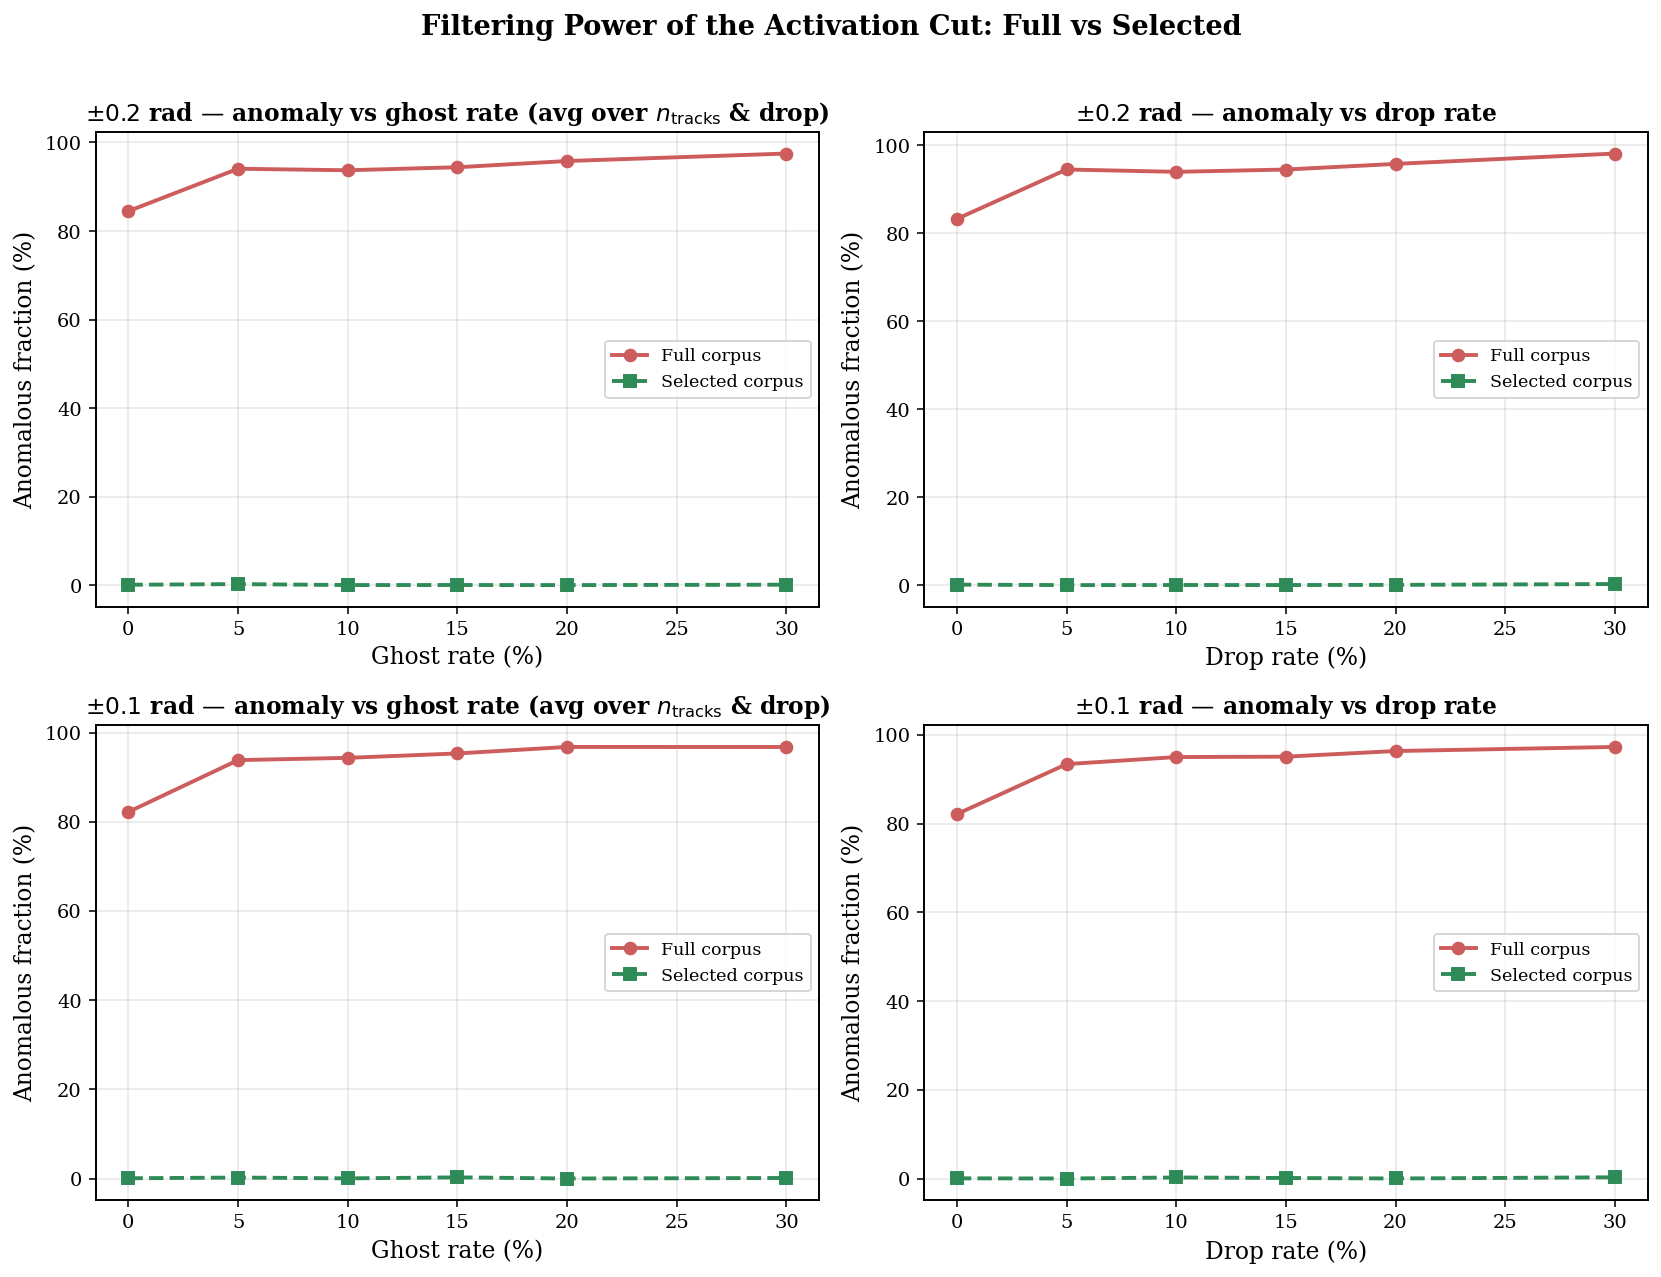

In [20]:
# ── Side-by-side comparison: full vs selected anomaly fraction ──
fig, axes = plt.subplots(len(angles), 2,
                         figsize=(12, 4.5 * len(angles)),
                         squeeze=False)

for row, angle in enumerate(angles):
    ax_g = axes[row][0]
    ax_d = axes[row][1]
    sub_clean = df[df["angle"] == angle].groupby("ghost_rate", as_index=False)[
        ["frac_anomalous_occ", "frac_anomalous_occ_sel"]].mean()
    ax_g.plot(sub_clean["ghost_rate"] * 100,
              sub_clean["frac_anomalous_occ"] * 100,
              "o-", label="Full corpus", lw=2, color="indianred")
    ax_g.plot(sub_clean["ghost_rate"] * 100,
              sub_clean["frac_anomalous_occ_sel"] * 100,
              "s--", label="Selected corpus", lw=2, color="seagreen")
    ax_g.set_xlabel("Ghost rate (%)")
    ax_g.set_ylabel("Anomalous fraction (%)")
    ax_g.set_title(f"$\\pm{angle}$ rad — anomaly vs ghost rate "
                   f"(avg over $n_\\text{{tracks}}$ & drop)",
                   fontweight="bold")
    ax_g.legend(fontsize=9)
    ax_g.grid(True, alpha=0.3)

    sub_drop = df[df["angle"] == angle].groupby("drop_rate", as_index=False)[
        ["frac_anomalous_occ", "frac_anomalous_occ_sel"]].mean()
    ax_d.plot(sub_drop["drop_rate"] * 100,
              sub_drop["frac_anomalous_occ"] * 100,
              "o-", label="Full corpus", lw=2, color="indianred")
    ax_d.plot(sub_drop["drop_rate"] * 100,
              sub_drop["frac_anomalous_occ_sel"] * 100,
              "s--", label="Selected corpus", lw=2, color="seagreen")
    ax_d.set_xlabel("Drop rate (%)")
    ax_d.set_ylabel("Anomalous fraction (%)")
    ax_d.set_title(f"$\\pm{angle}$ rad — anomaly vs drop rate",
                   fontweight="bold")
    ax_d.legend(fontsize=9)
    ax_d.grid(True, alpha=0.3)

plt.suptitle("Filtering Power of the Activation Cut: Full vs Selected",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig(fig, "full_vs_selected_anomaly")
plt.show()


## Summary

This notebook analyses the systematic sweep over ghost rate and drop rate to characterise the **segment grass** effect:

1. **Anomalous occupancy fraction** — The ±0.2 rad angle consistently shows elevated anomalous occupancy (geometric clipping), while ±0.1 rad remains unaffected. Ghost hits amplify the effect; dropped hits can partially mask it.

2. **Occupancy standard deviation** — Increases with ghost rate (more spurious peaks) and is modulated by drop rate.

3. **Hits-per-module variability** — The coefficient of variation across modules captures the asymmetric hit loss from clipping; ghost hits increase it by padding inner modules more than outer ones.

4. **Reconstruction metrics** — Efficiency degrades with both ghost and drop rates, but ghost hits are more damaging because they create false segments that compete for activation.

5. **Segment count** — Grows quadratically with ghost hits (each ghost hit creates segments with all hits in adjacent modules), while dropped hits have a milder, linear reduction effect.

6. **Activation spectrum** — Ghost hits push false-segment activations upward (closer to the threshold), degrading the clean separation between true and false segments.

### Next steps
- Run the Condor sweep: `cd Segment_Grass && bash submit.sh`
- After jobs finish: `python scripts/aggregate.py`
- Re-run this notebook to populate all figures